# OPERATION ANALYSIS - CAPGEMINI
RICARDO PADILLA HERRERA


## SET UP

In [1]:
# IMPORTS + SETTINGS

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
!pip install umap-learn

RANDOM_STATE = 42



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# GLOBAL VISUAL THEME (Dark consulting style)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Base colors ---
DARK_BG   = "#071426"
GRID_COL  = "#23324A"
TEXT_COL  = "#E5E7EB"
TICK_COL  = "#92DCE5"
ATTRITION_YES = "#E63946"
ATTRITION_NO  = "#2A9DF4"

# Gender colors (soft pastel)
FEMALE_COL = "#D17B88"
MALE_COL   = "#016FB9"
EDGE_COL   = "lightblue"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "savefig.facecolor": DARK_BG,

    "axes.edgecolor": TICK_COL,
    "axes.labelcolor": TEXT_COL,
    "axes.titlecolor": TEXT_COL,
    "text.color": TEXT_COL,

    "xtick.color": TICK_COL,
    "ytick.color": TICK_COL,

    "grid.color": GRID_COL,
    "grid.alpha": 0,
    "grid.linewidth": 0.0,

    "axes.grid": True,
    "axes.axisbelow": True,
})

# global sizing
FIG_W, FIG_H = 21, 7
BIG_W, BIG_H = 21, 7


## DATA LOADING

In [3]:
# DOWNLOAD DATASET FROM GOOGLE DRIVE (ANCHOR TO NOTEBOOK)

!pip -q install gdown
import os, re
import gdown

drive_link = "https://drive.google.com/file/d/1CtUdXF1L8clYMNlJJUyJBPw7TDnM5hF2/view?usp=sharing"

m = re.search(r"/d/([a-zA-Z0-9_-]+)", drive_link)
file_id = m.group(1)

DATA_PATH = "employee.csv"  # <-- IMPORTANTE: guardarlo como CSV

if not os.path.exists(DATA_PATH):
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, DATA_PATH, quiet=False)
else:
    print(f"Already exists -> {DATA_PATH}")

print("Downloaded:", os.path.exists(DATA_PATH), "| Size (bytes):", os.path.getsize(DATA_PATH))

df = pd.read_csv(DATA_PATH)

print("Dataset loaded correctly")
print("Shape:", df.shape)
display(df.head())


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Already exists -> employee.csv
Downloaded: True | Size (bytes): 233730
Dataset loaded correctly
Shape: (1518, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,3,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,5,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## DATA EXPLORATION

### MISSING VALUES

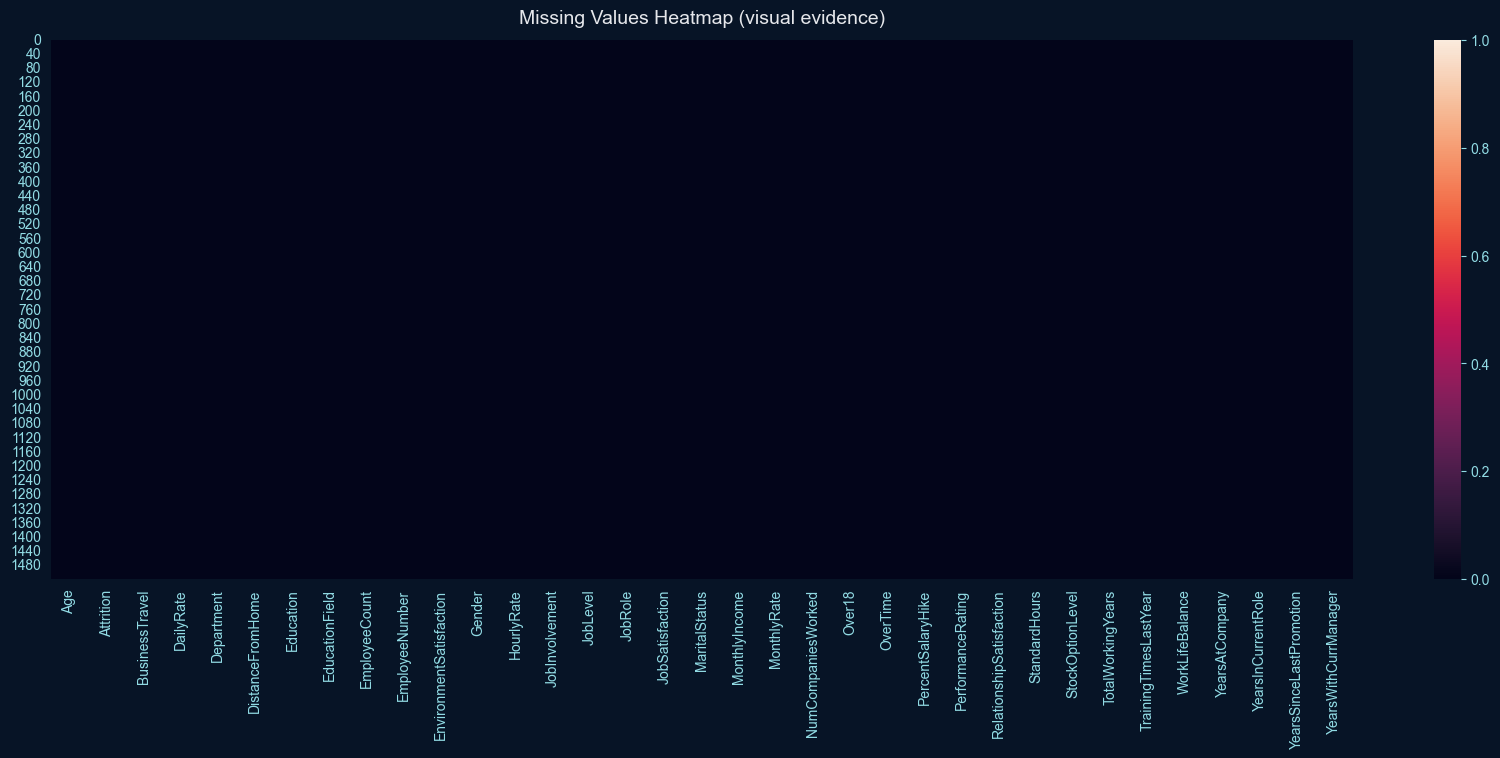

,missing_n,missing_%
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


In [4]:
# MISSING CHECK
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)).sort_values(ascending=False)

plt.figure(figsize=(21, 7))
sns.heatmap(df.isnull(), cbar=True, vmin=0, vmax=1)
plt.title("Missing Values Heatmap (visual evidence)", fontsize=14, pad=12)
plt.xticks(rotation=90)
plt.show()

miss_table = pd.DataFrame({"missing_n": missing, "missing_%": (missing_pct*100).round(2)})
display(miss_table.head(20))


### EXPLORATION

#### CODE FOR THE GRAPHS

In [5]:
# COMMON AXIS STYLE

def _style_ax(ax, title=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=13, pad=10)
    if ylabel:
        ax.set_ylabel(ylabel)

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.7)
    ax.spines["bottom"].set_alpha(0.7)

    ax.tick_params(axis="x", labelrotation=0)

def _format_percent_axis(ax):
    ax.set_ylim(0, 1)
    yticks = np.linspace(0, 1, 6)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y*100:.0f}%" for y in yticks])

def _finalize_figure(fig):
    fig.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.22)


In [6]:
# COMMON AXIS STYLE

def _style_ax(ax, title=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=13, pad=10)
    if ylabel:
        ax.set_ylabel(ylabel)

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.7)
    ax.spines["bottom"].set_alpha(0.7)

    ax.tick_params(axis="x", labelrotation=0)

def _format_percent_axis(ax):
    ax.set_ylim(0, 1)
    yticks = np.linspace(0, 1, 6)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y*100:.0f}%" for y in yticks])

def _finalize_figure(fig):
    fig.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.22)


In [7]:
# PERCENT BAR (overall distribution)

def percent_bar(df, column, title, top_n=8, figsize=(FIG_W, FIG_H)):

    s = df[column].astype(str).value_counts(normalize=True)

    if len(s) > top_n:
        other = s.iloc[top_n:].sum()
        s = s.iloc[:top_n]
        s["Other"] = other

    fig, ax = plt.subplots(figsize=figsize)
    s.plot(kind="bar", ax=ax)

    for p in ax.patches:
        p.set_edgecolor("none")
        p.set_linewidth(0)

    # labels %
    for i, v in enumerate(s.values):
        ax.text(i, v + 0.02, f"{v*100:.1f}%", ha="center")

    _style_ax(ax, title, "Percentage")
    _format_percent_axis(ax)
    _finalize_figure(fig)
    plt.show()
    plt.close(fig)

In [8]:
# PERCENT BAR BY GENDER

def percent_bar_gender(df, column, gender_col="Gender", title=None, top_n=8, figsize=(BIG_W, BIG_H)):

    tmp = df.copy()
    ctab = pd.crosstab(tmp[column], tmp[gender_col], normalize="columns")

    # keep most frequent categories
    overall = tmp[column].value_counts(normalize=True)
    keep = overall.head(top_n).index
    ctab = ctab.loc[ctab.index.intersection(keep)]

    fig, ax = plt.subplots(figsize=figsize)
    ctab.plot(kind="bar", width=0.8, ax=ax)

    # apply colors
    colors = [FEMALE_COL, MALE_COL]
    for i, container in enumerate(ax.containers):
        for bar in container:
            bar.set_color(colors[i % 2])
            bar.set_edgecolor(EDGE_COL)
            bar.set_linewidth(0.3)

            h = bar.get_height()
            if h > 0.03:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h*100:.1f}%", ha="center", fontsize=10)

    _style_ax(ax, title or f"{column} by Gender", "Percentage within Gender")
    _format_percent_axis(ax)

    # legend readable
    leg = ax.legend(title="Gender")
    for t in leg.get_texts():
        t.set_color(TEXT_COL)
    leg.get_title().set_color(TEXT_COL)

    _finalize_figure(fig)
    plt.show()
    plt.close(fig)


In [9]:
# ATTRITION RATE BY GROUP

def percent_bar_by_group(df, group_col, outcome_col, positive_value, title, figsize=(FIG_W, FIG_H)):

    tmp = df.copy()
    rate = tmp.groupby(group_col)[outcome_col].apply(lambda x: (x == positive_value).mean())

    fig, ax = plt.subplots(figsize=figsize)
    rate.plot(kind="bar", ax=ax)

    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.02, f"{v*100:.1f}%", ha="center")

    _style_ax(ax, title, "Percentage")
    _format_percent_axis(ax)
    _finalize_figure(fig)
    plt.show()
    plt.close(fig)

#### VISUALS

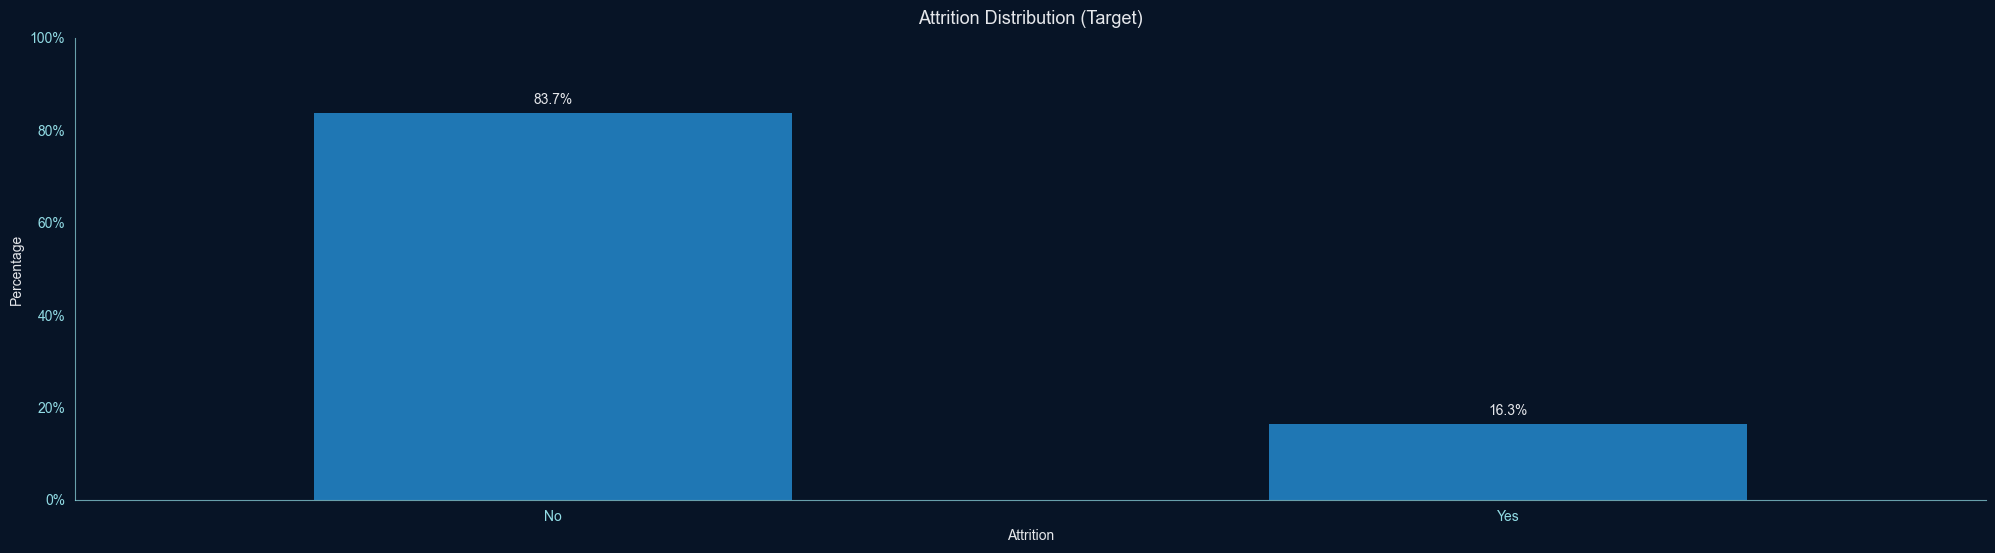

Attrition rate (Yes): 16.34%


In [10]:
# TARGET DISTRIBUTION
percent_bar(df, "Attrition", "Attrition Distribution (Target)")

# Optional: numeric evidence
attr_rate = (df["Attrition"].astype(str) == "Yes").mean()
print(f"Attrition rate (Yes): {attr_rate * 100:.2f}%")

The attrition rate is 16.3%, meaning roughly one out of every six employees leaves the company.
This indicates a relevant HR problem and justifies the need for a predictive model.

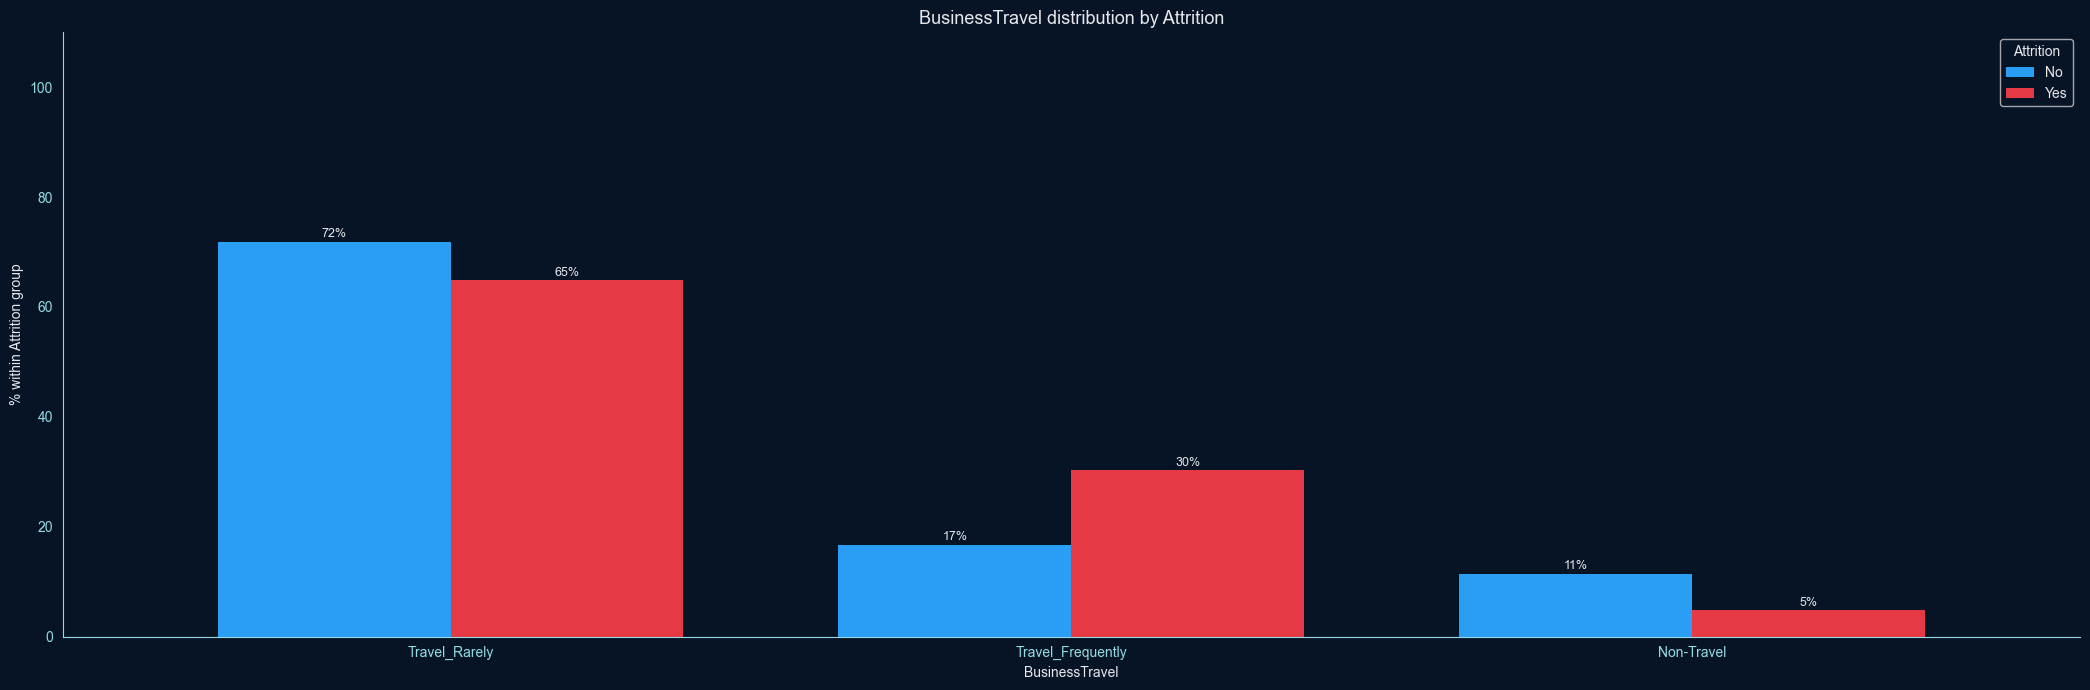

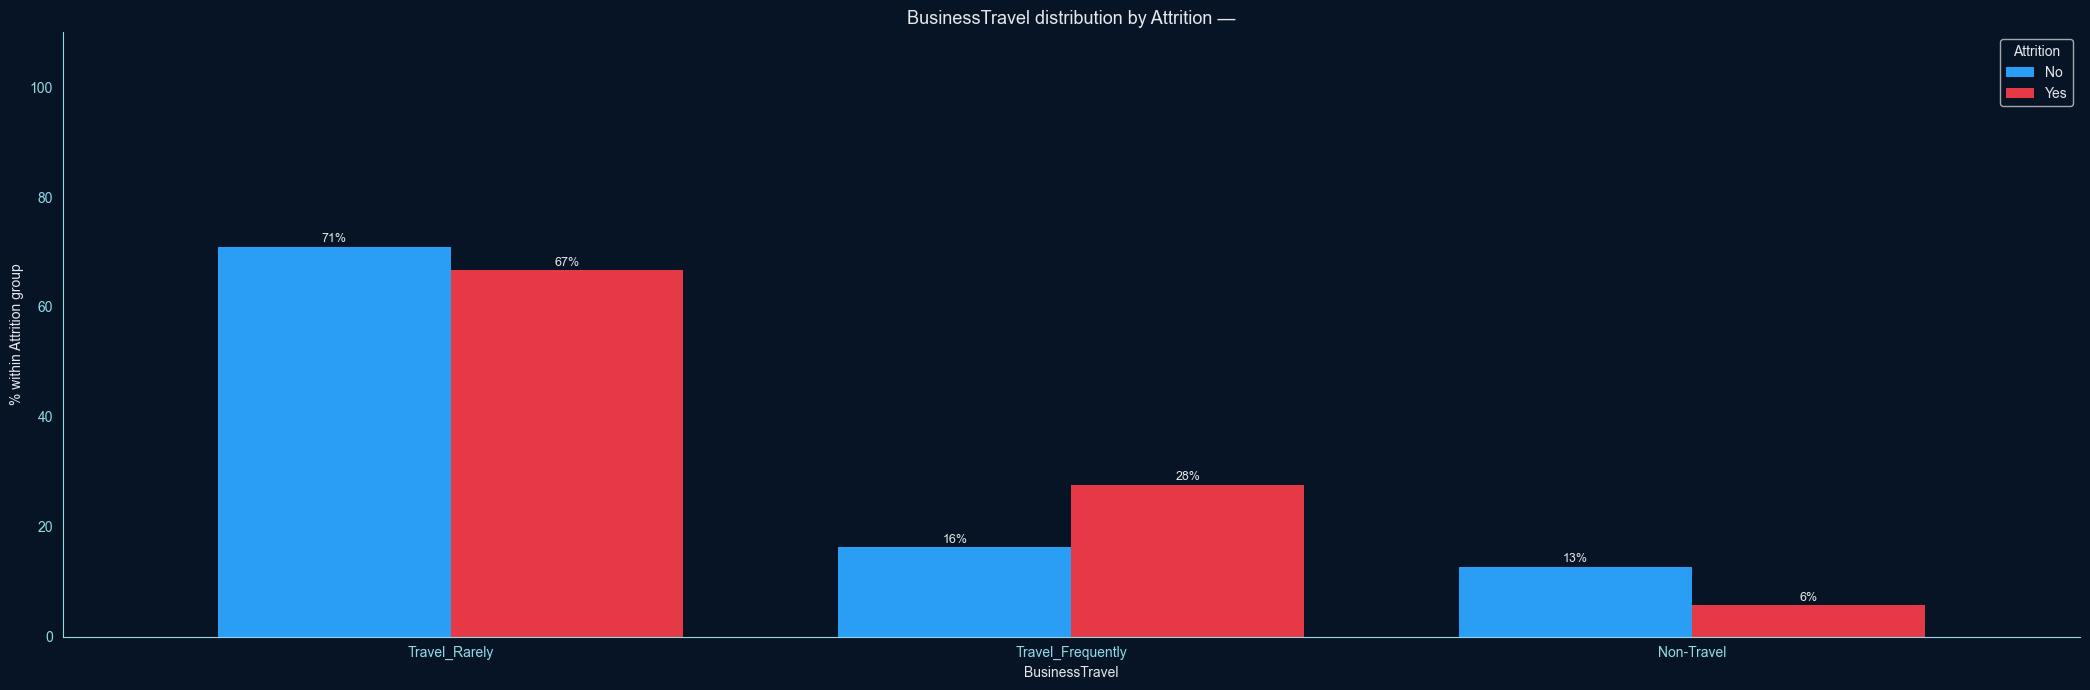

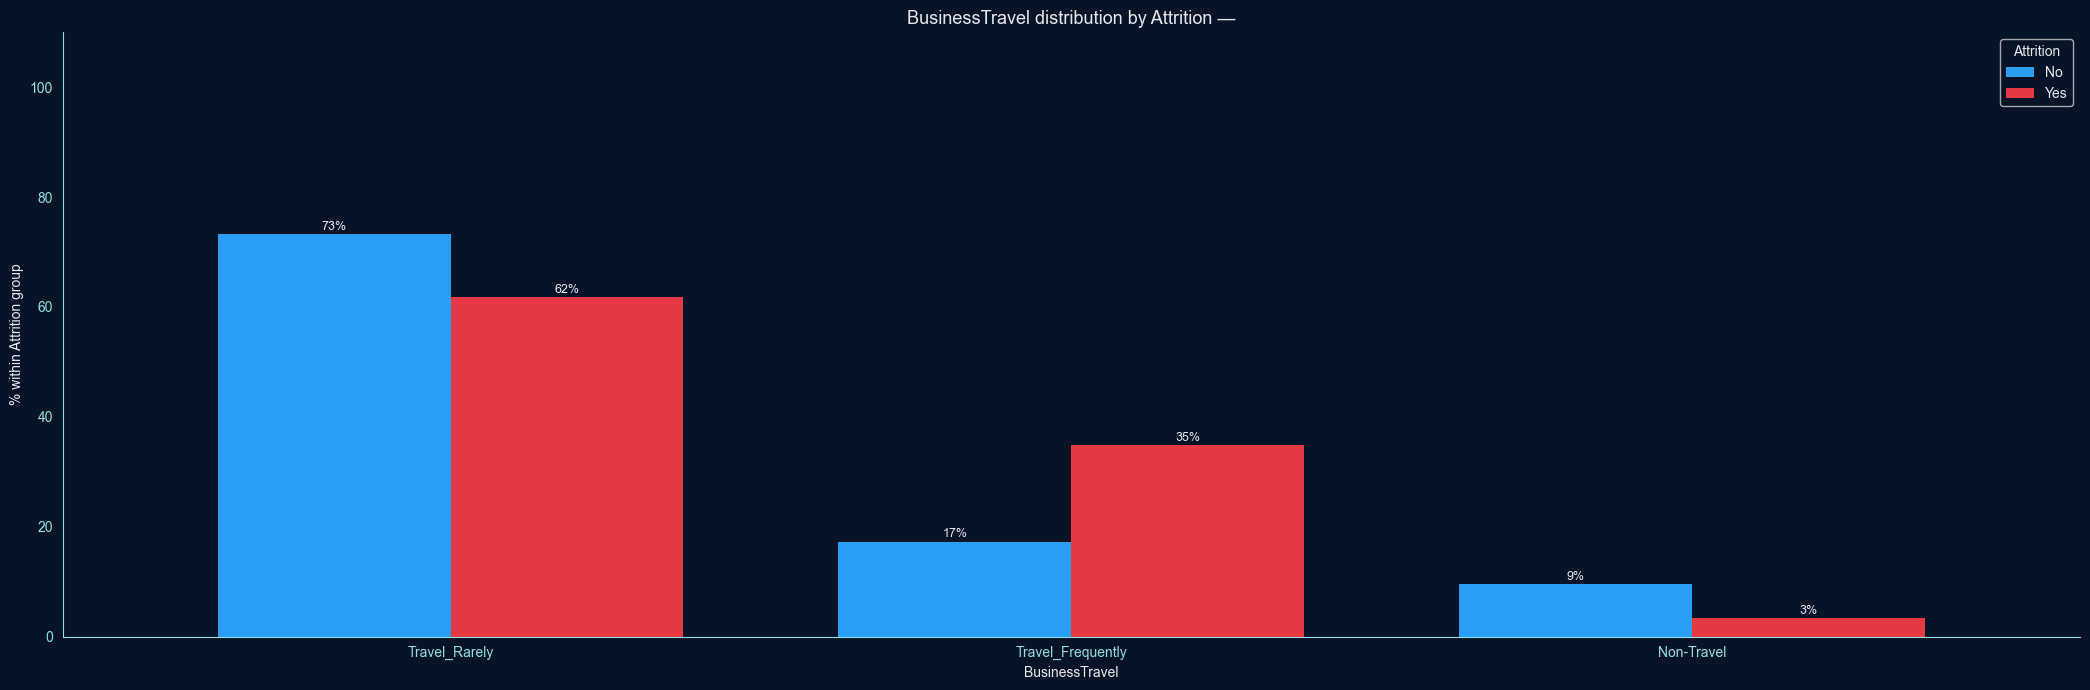

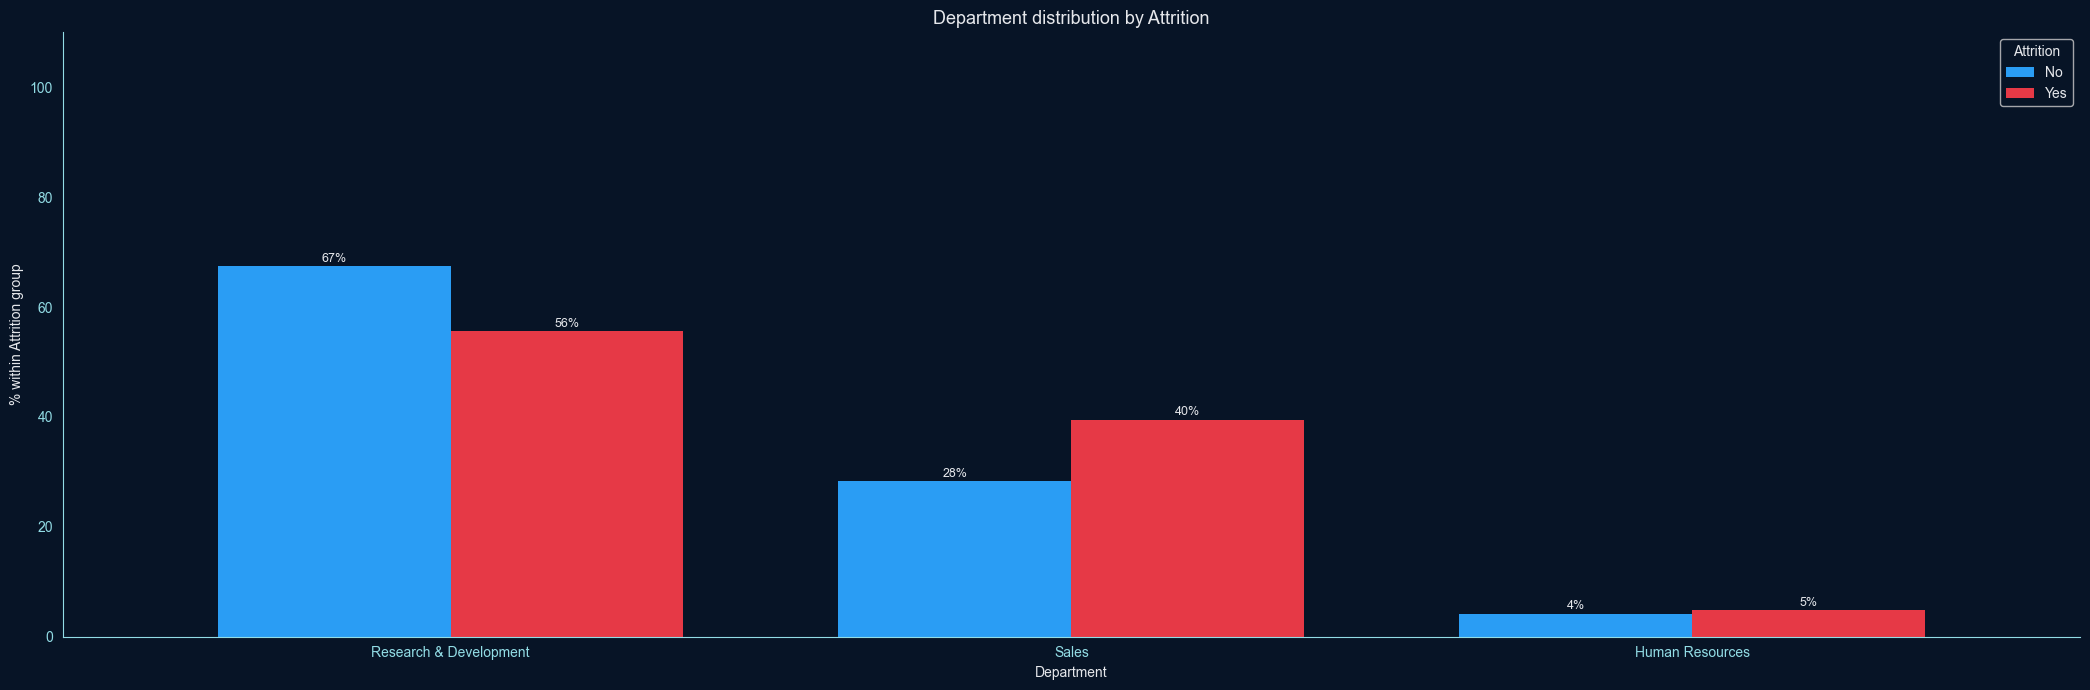

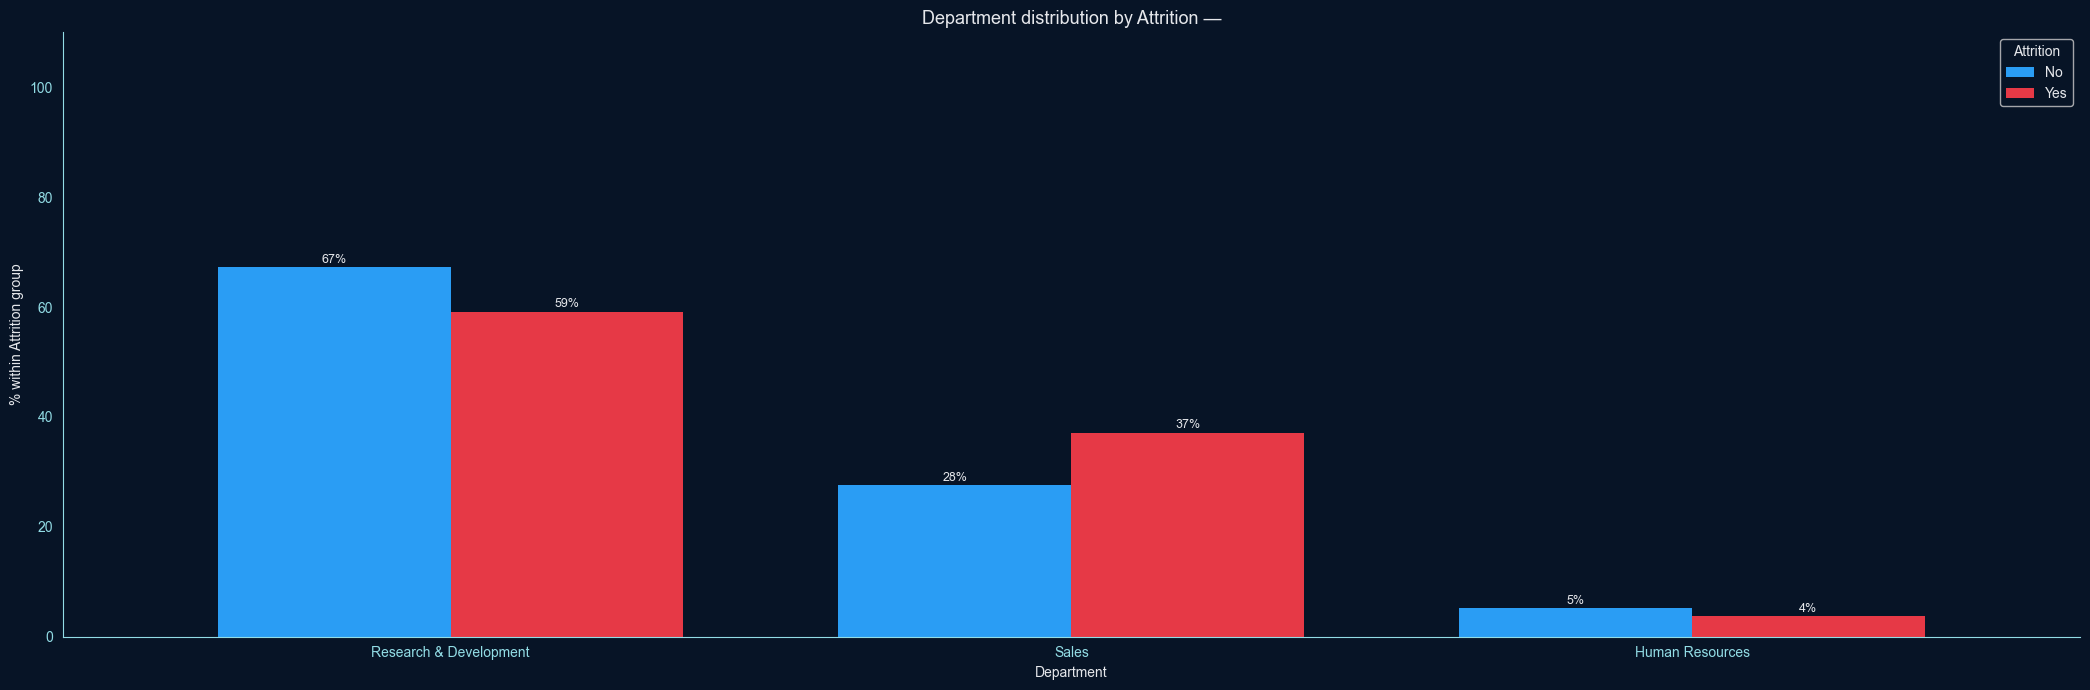

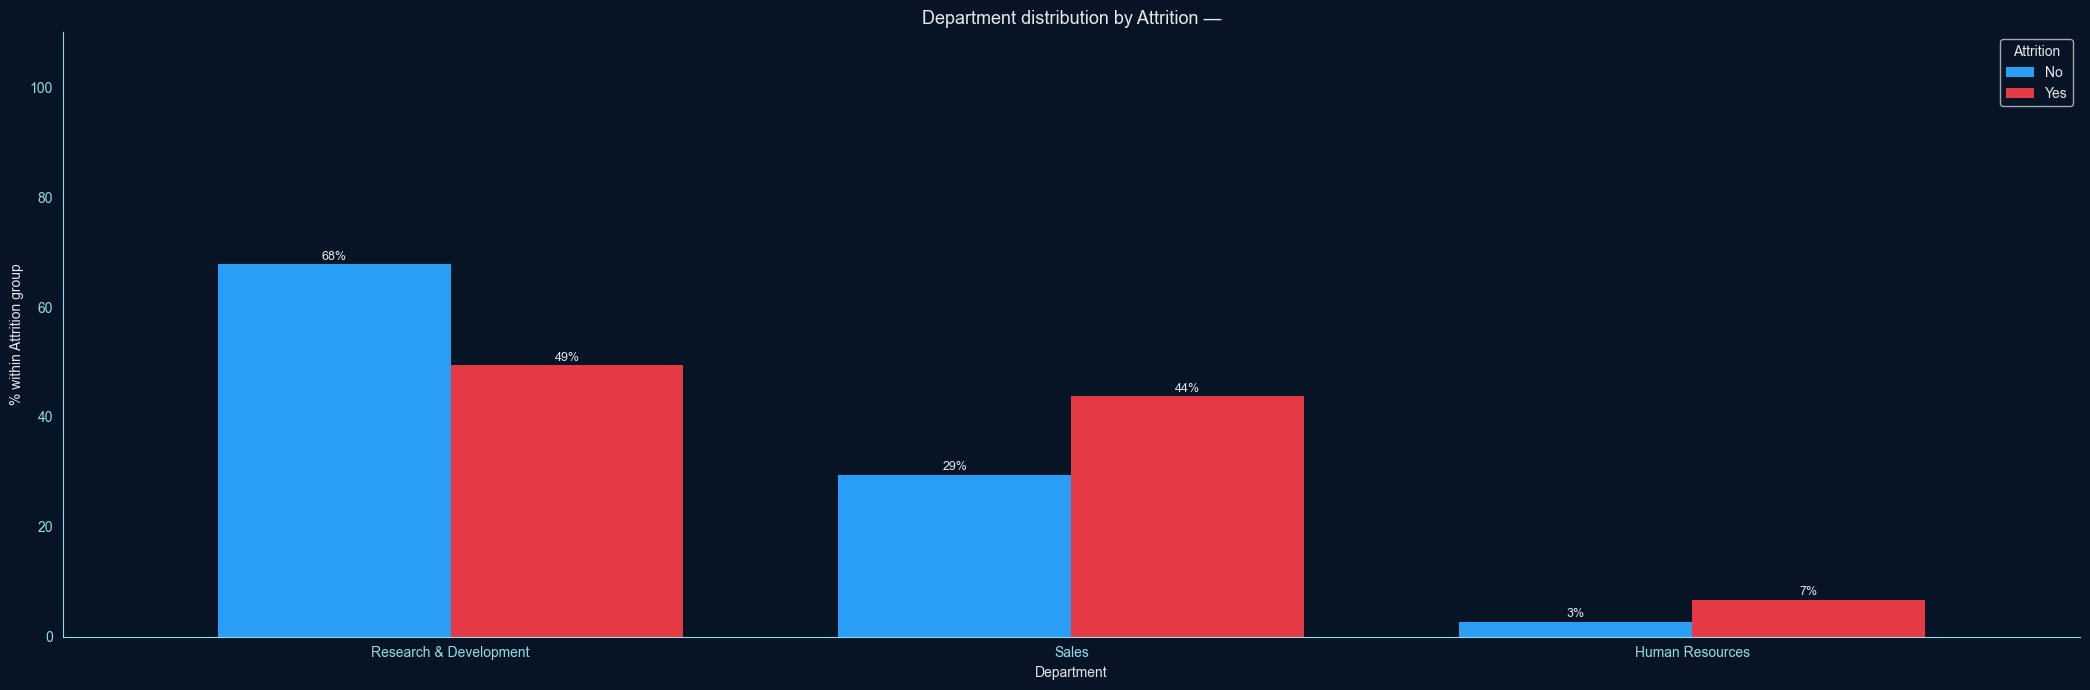

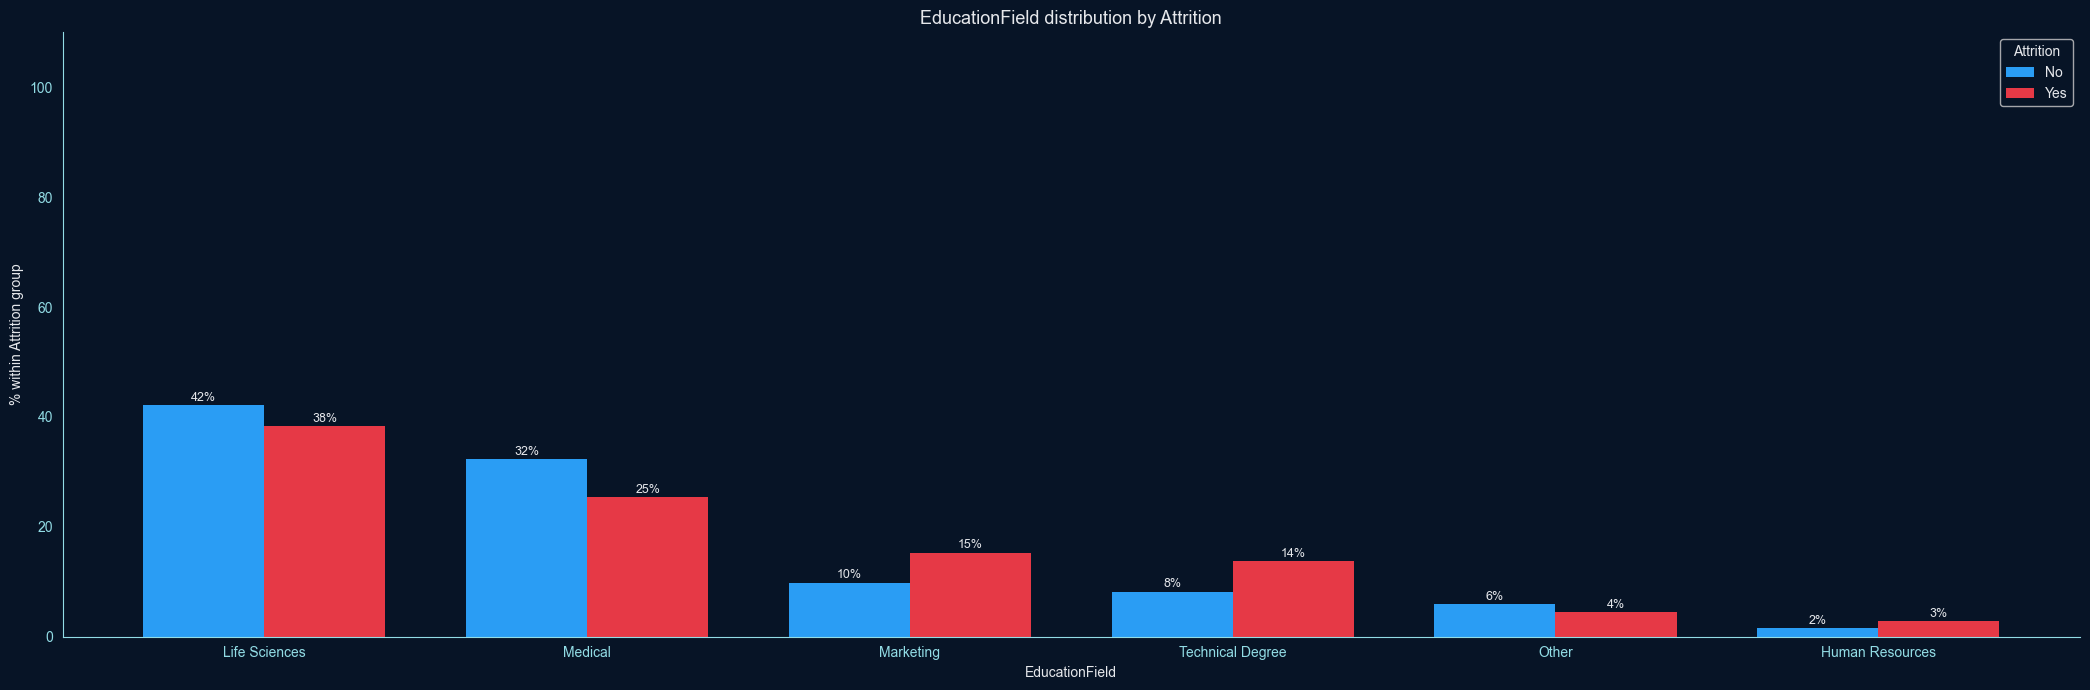

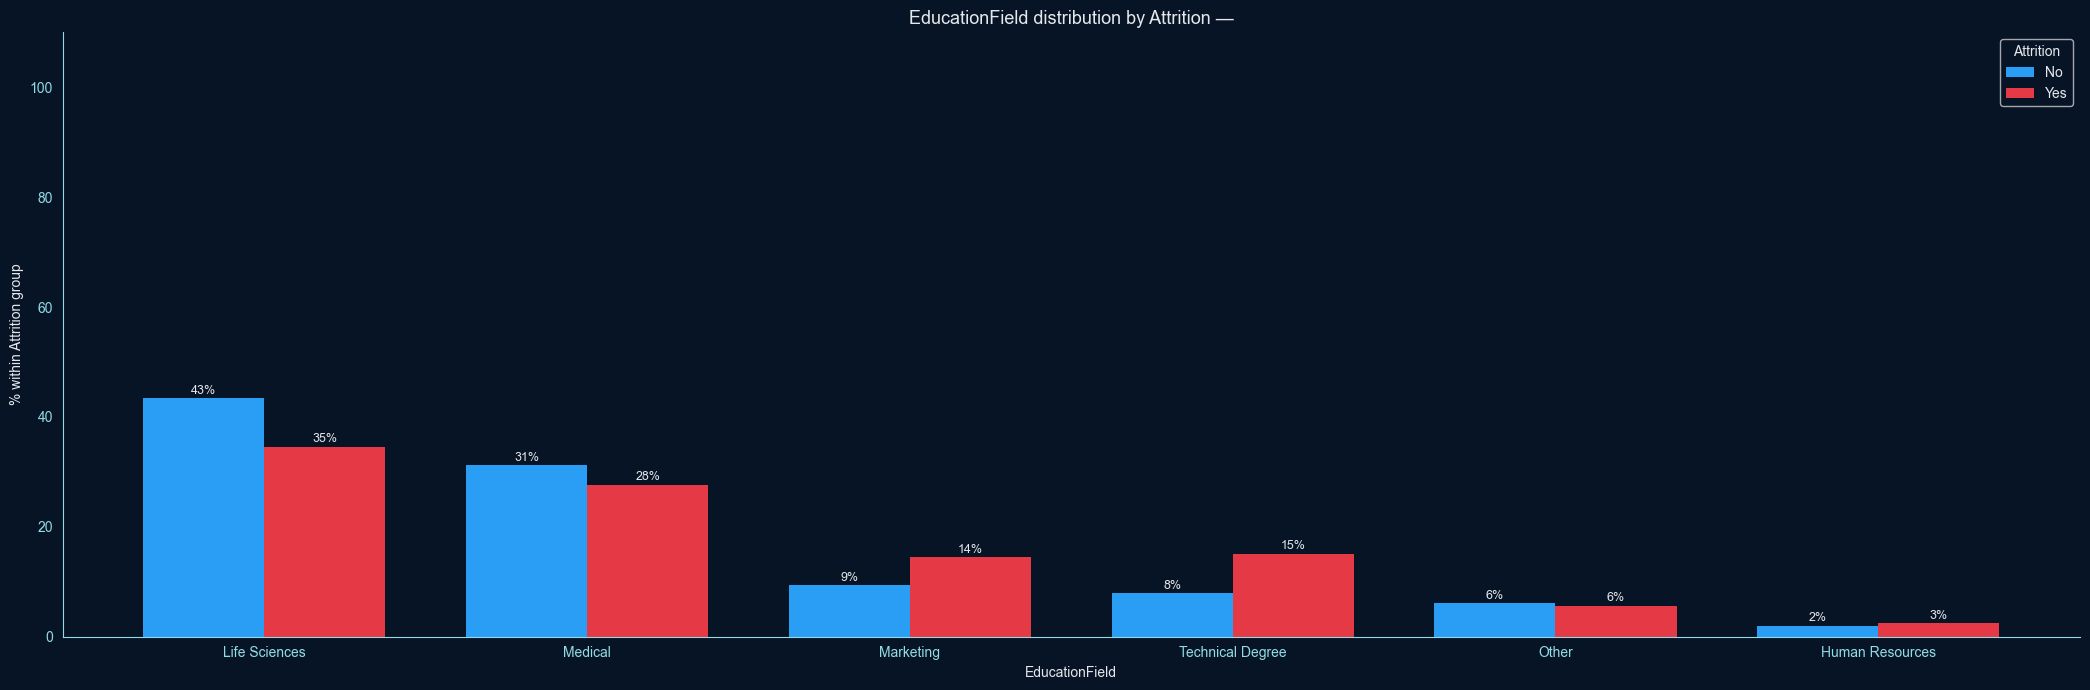

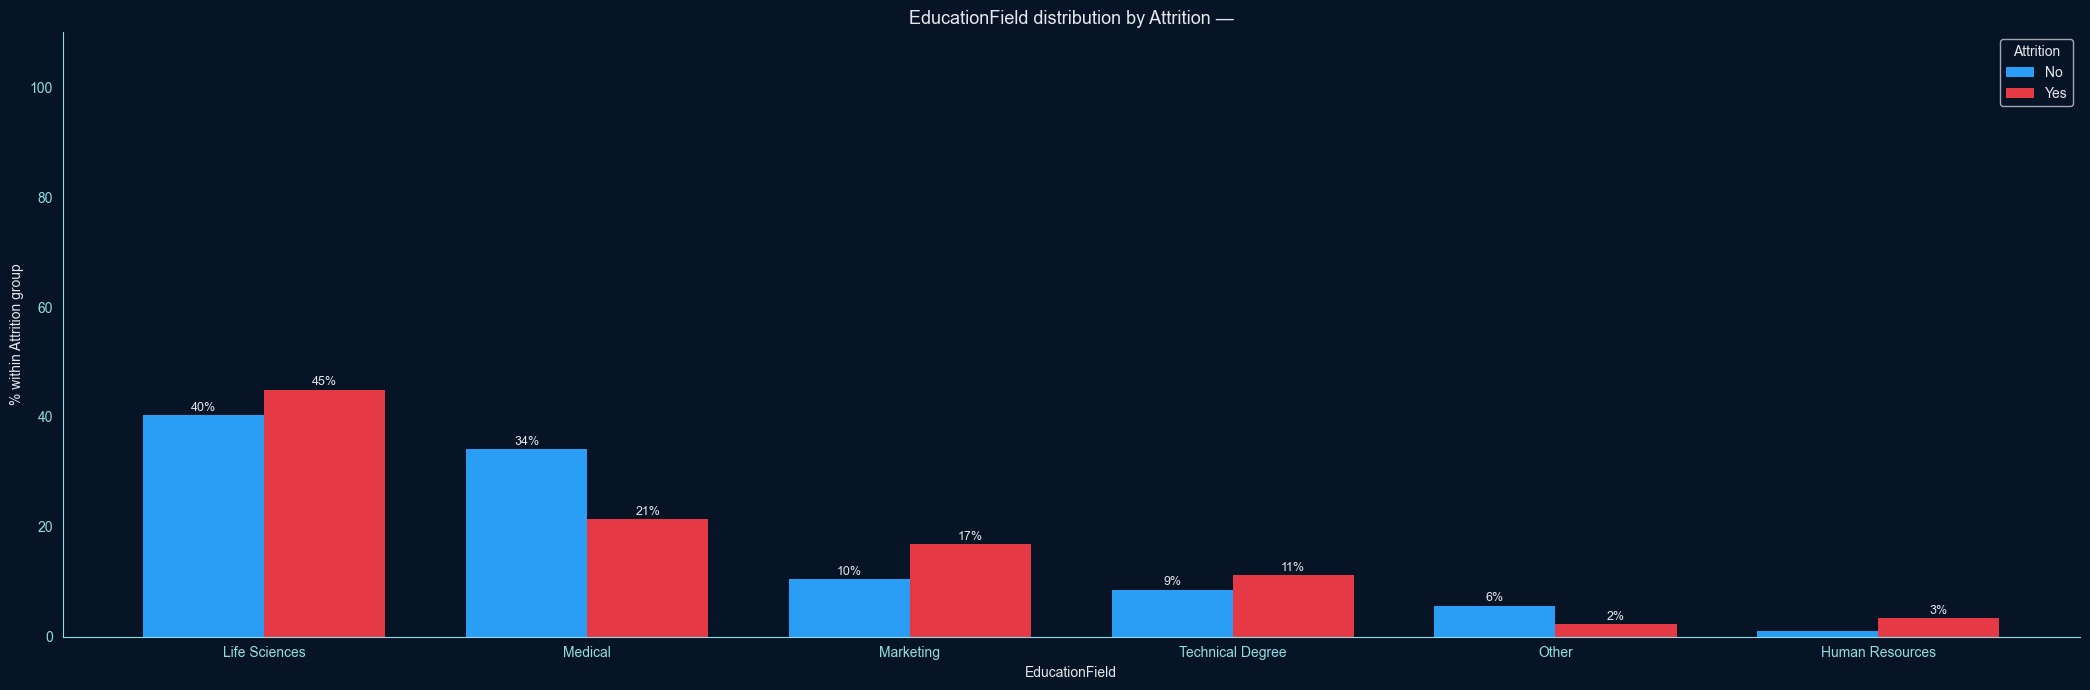

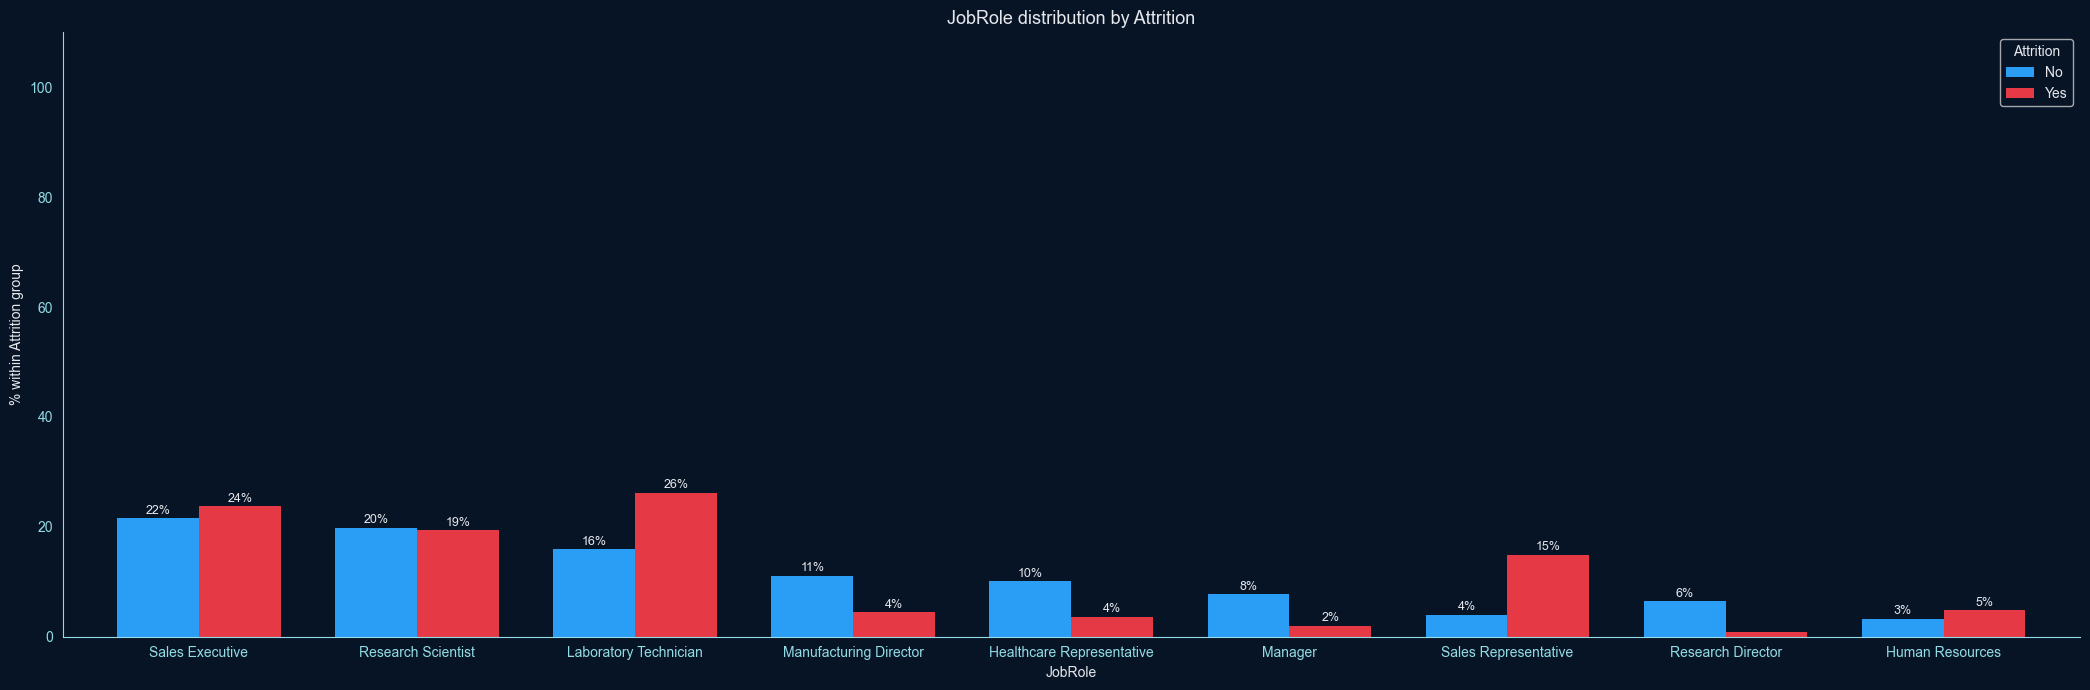

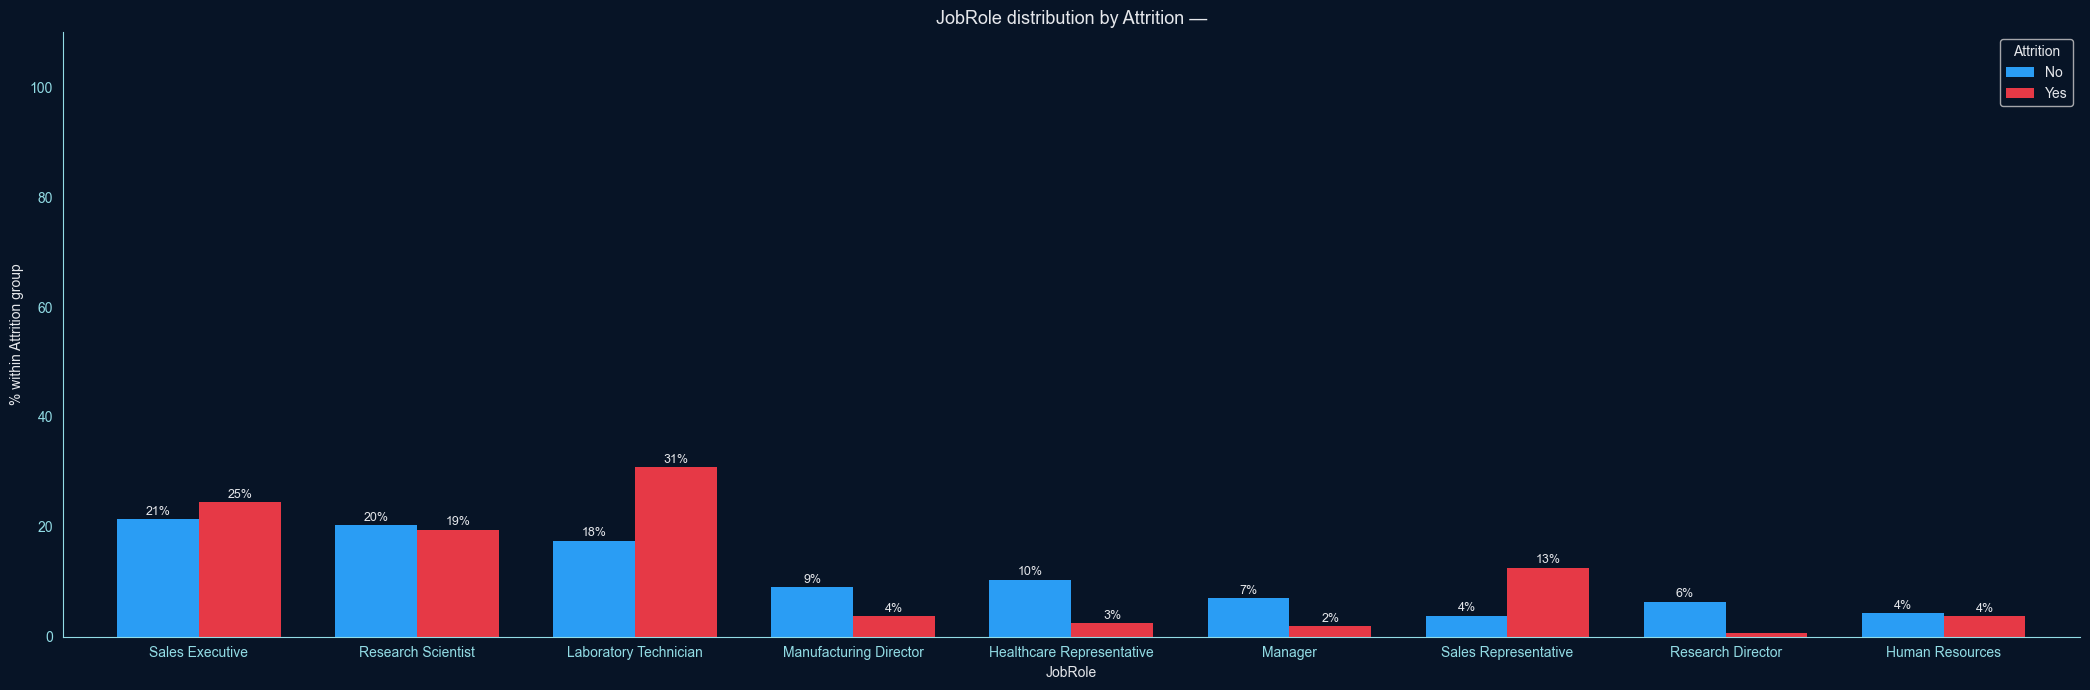

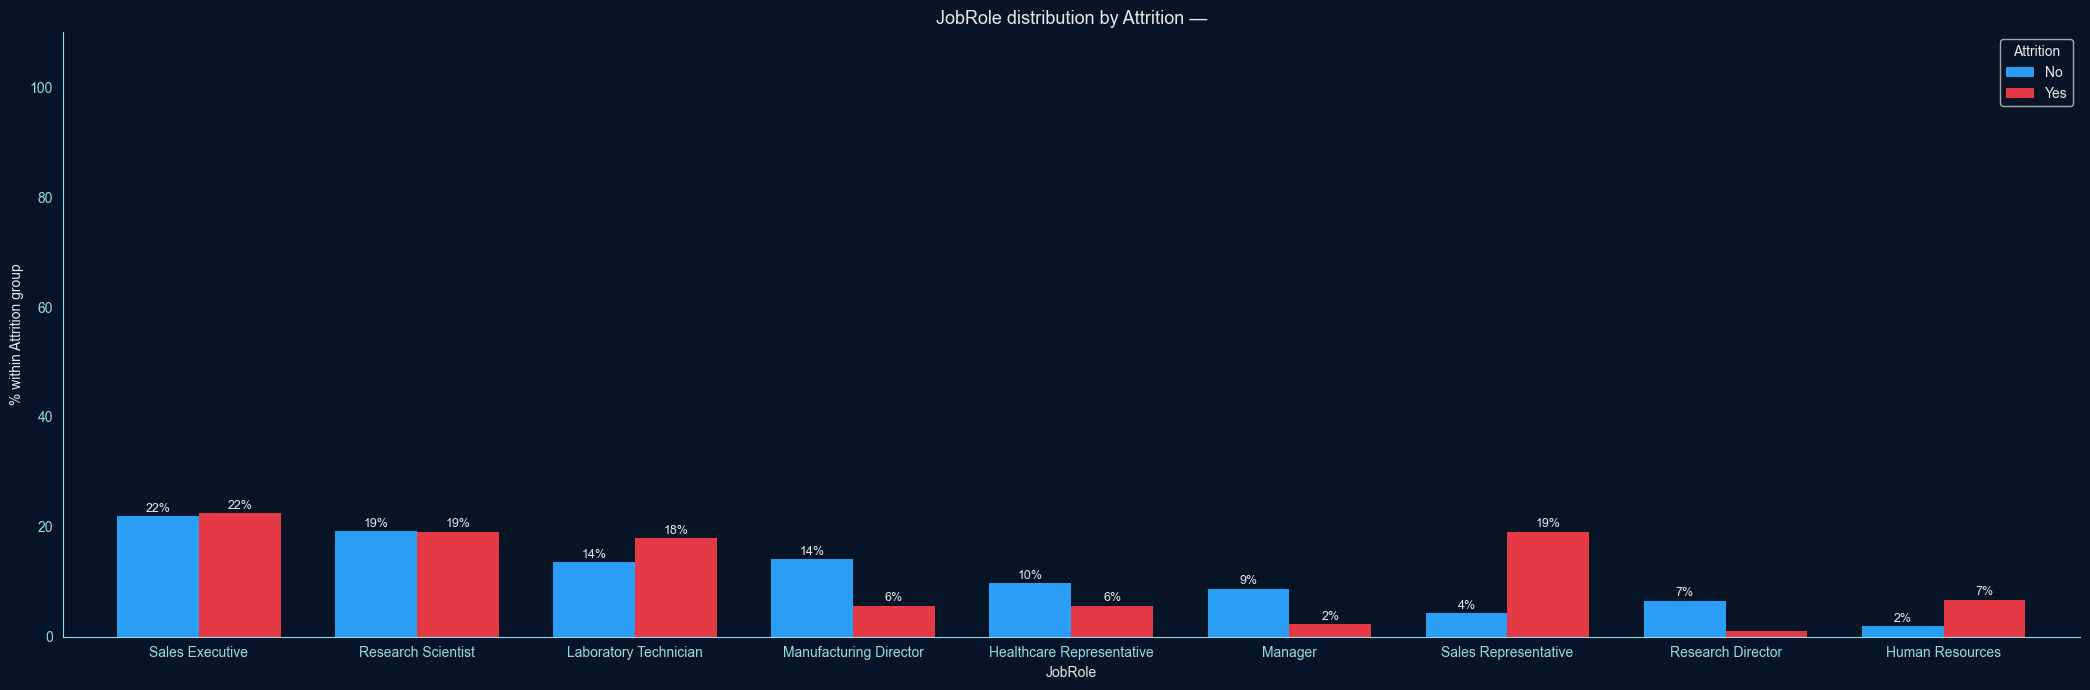

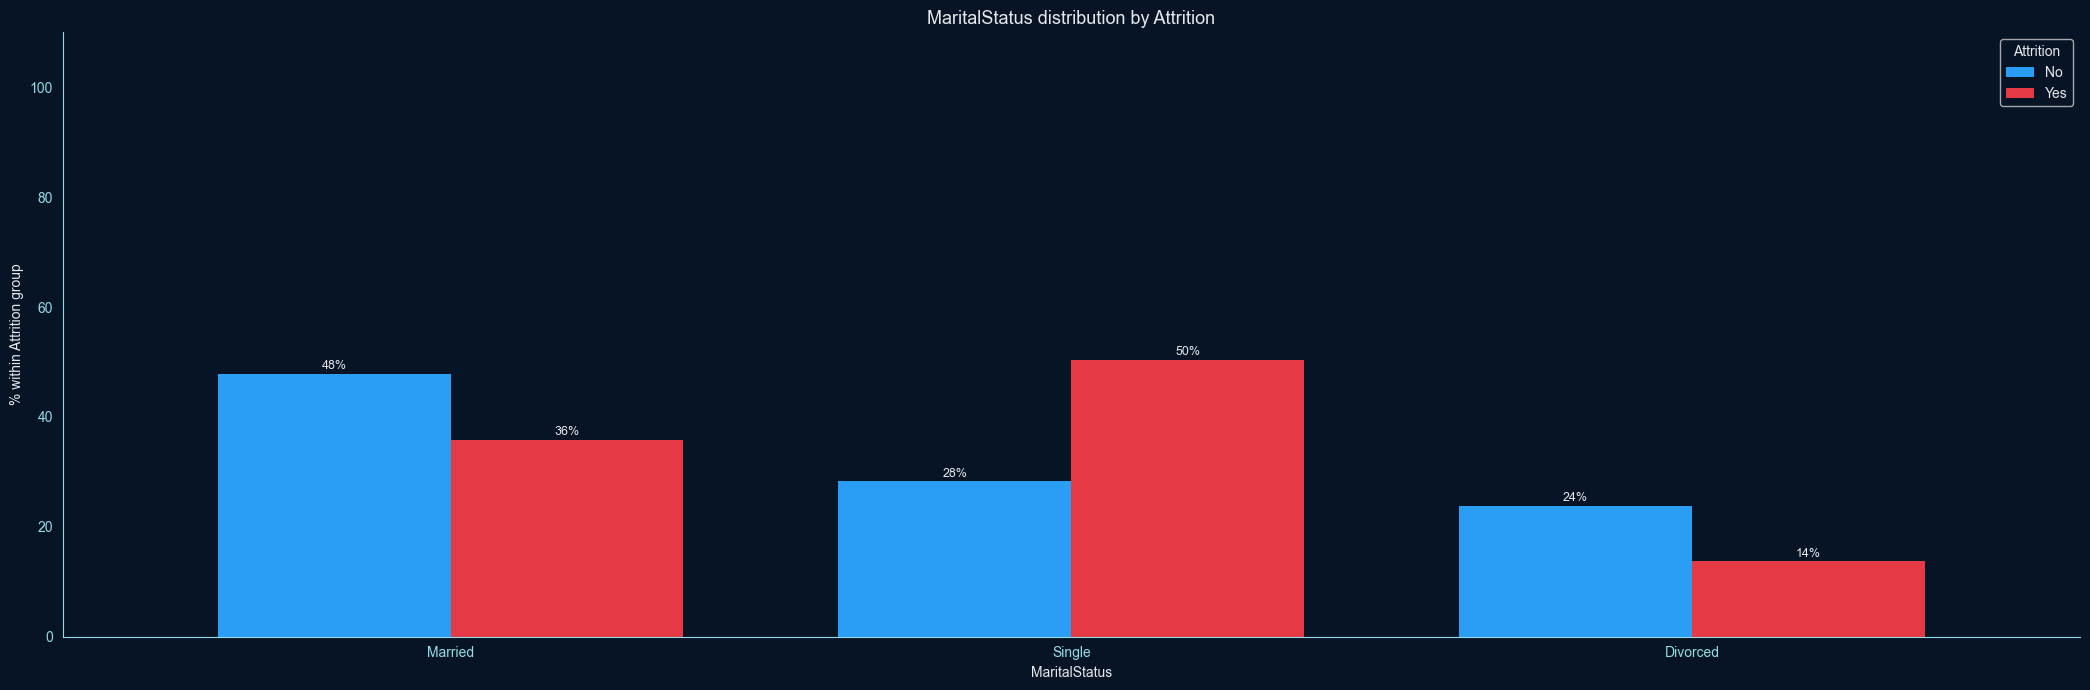

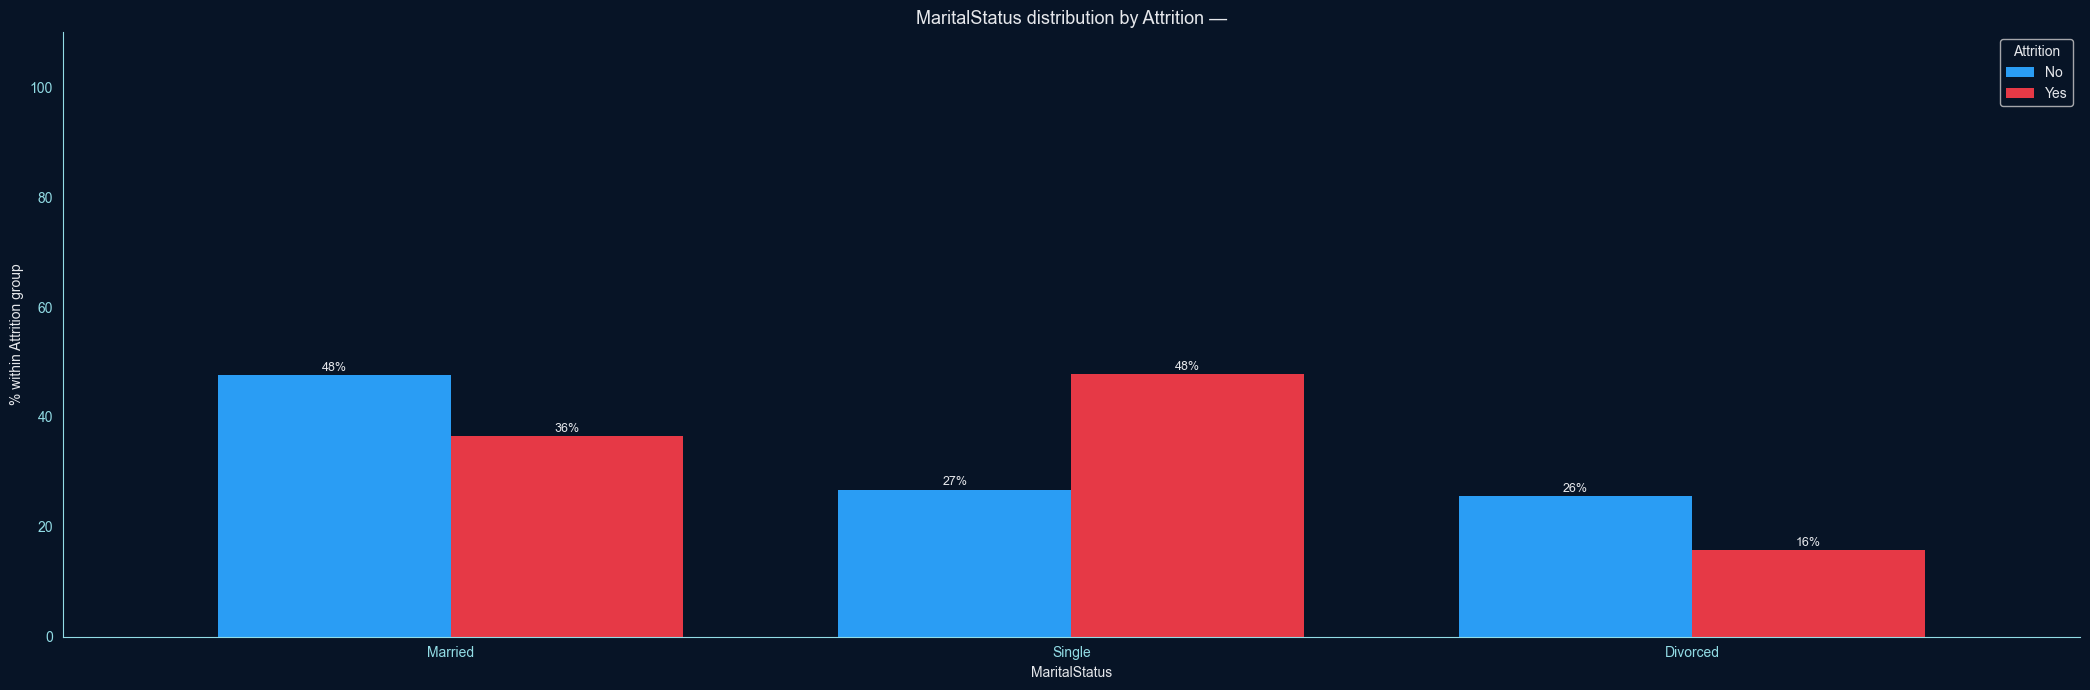

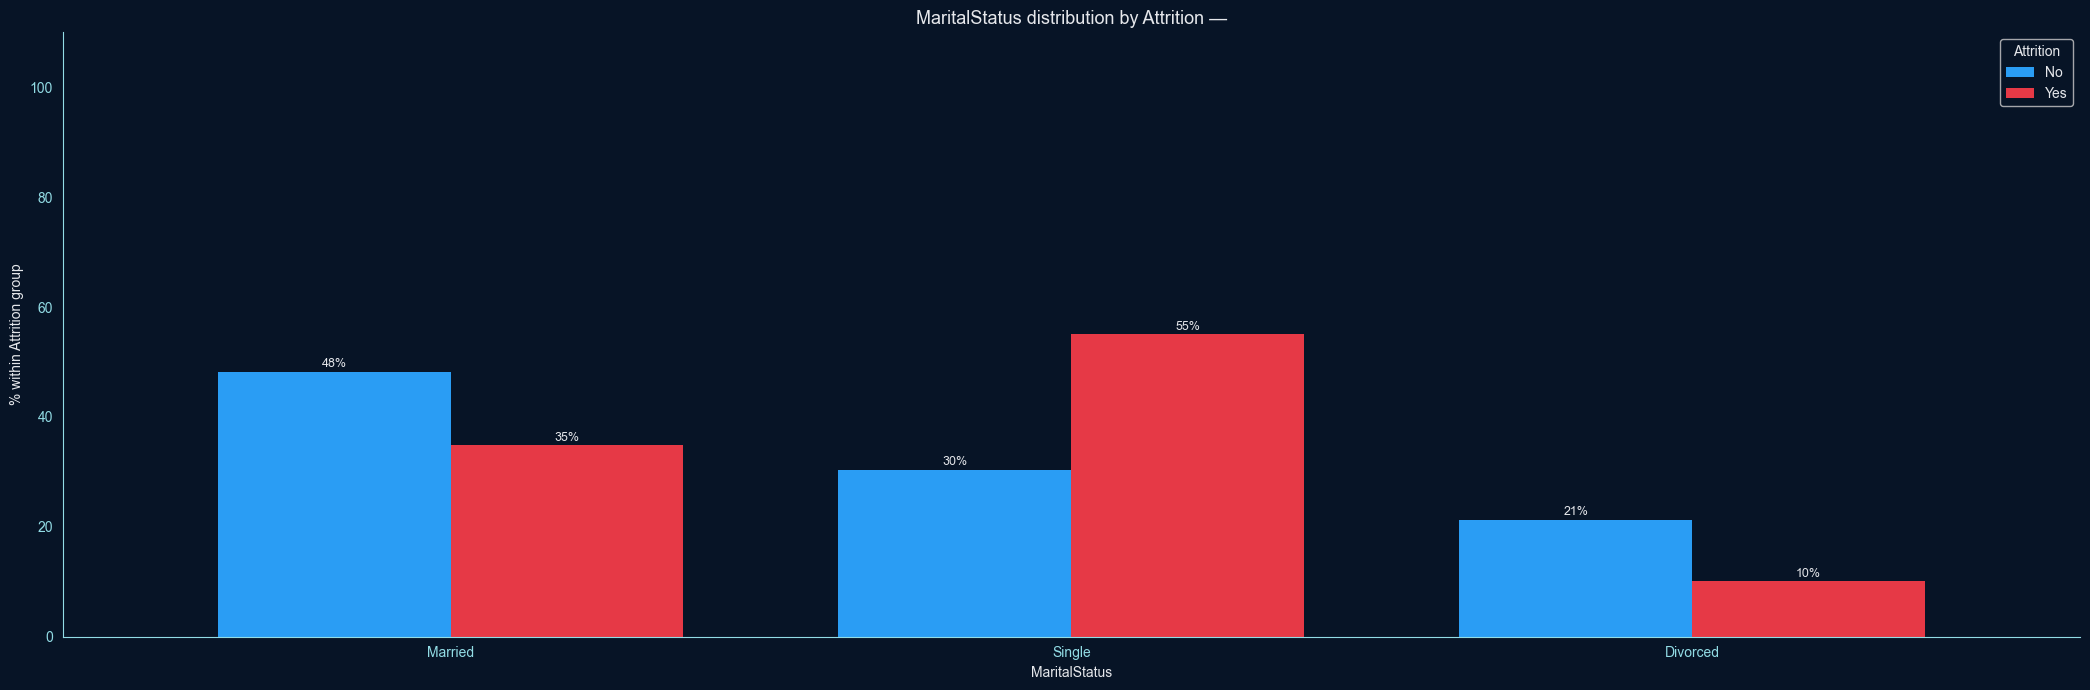

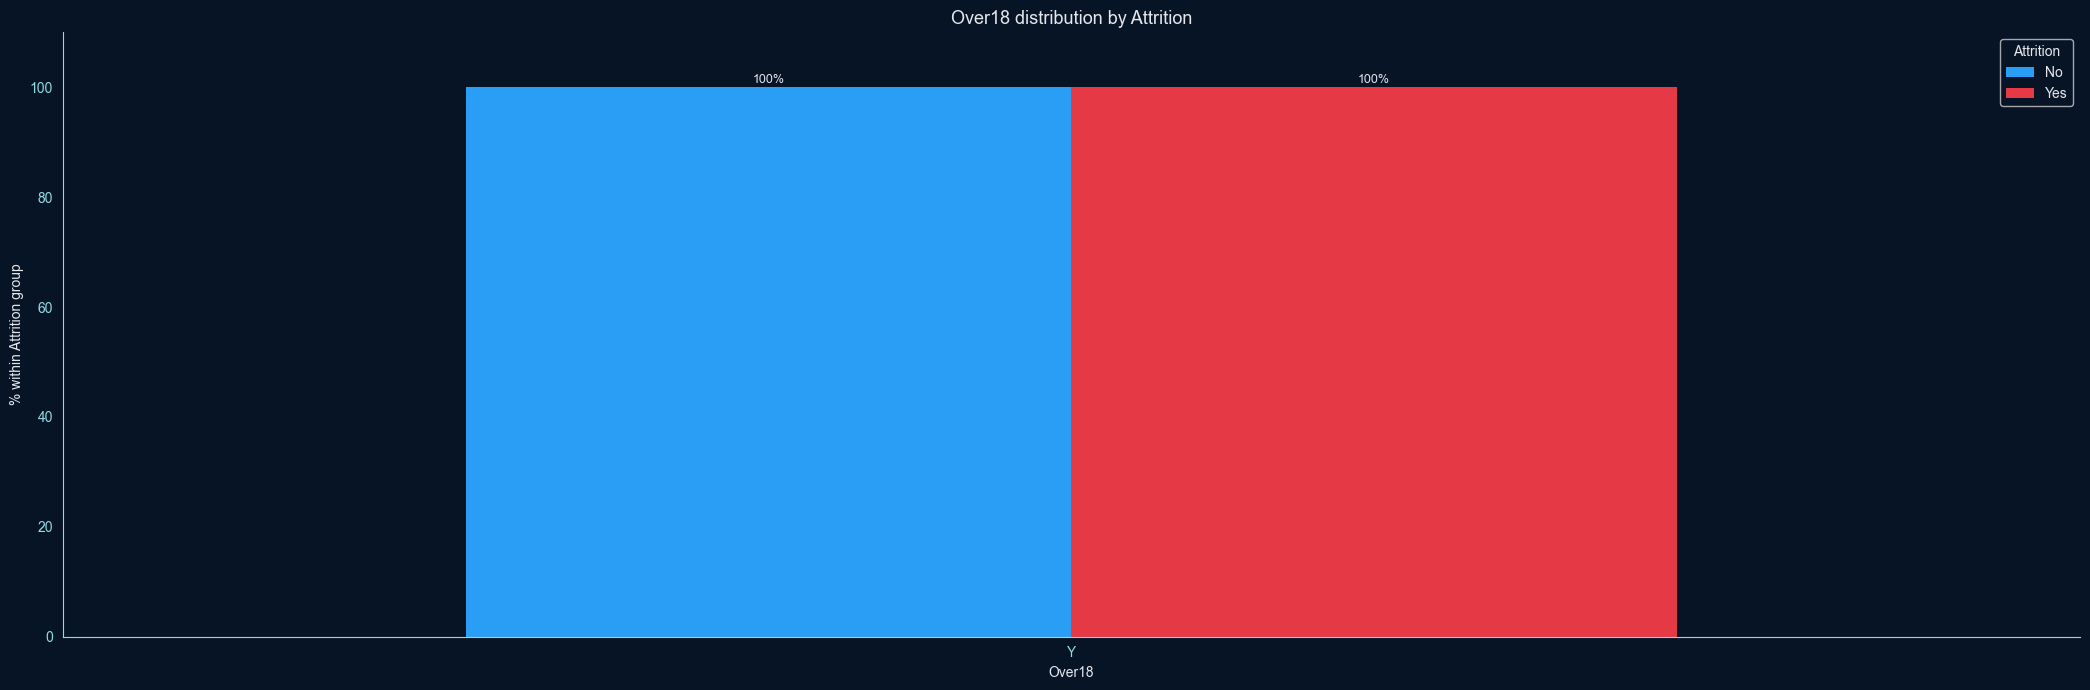

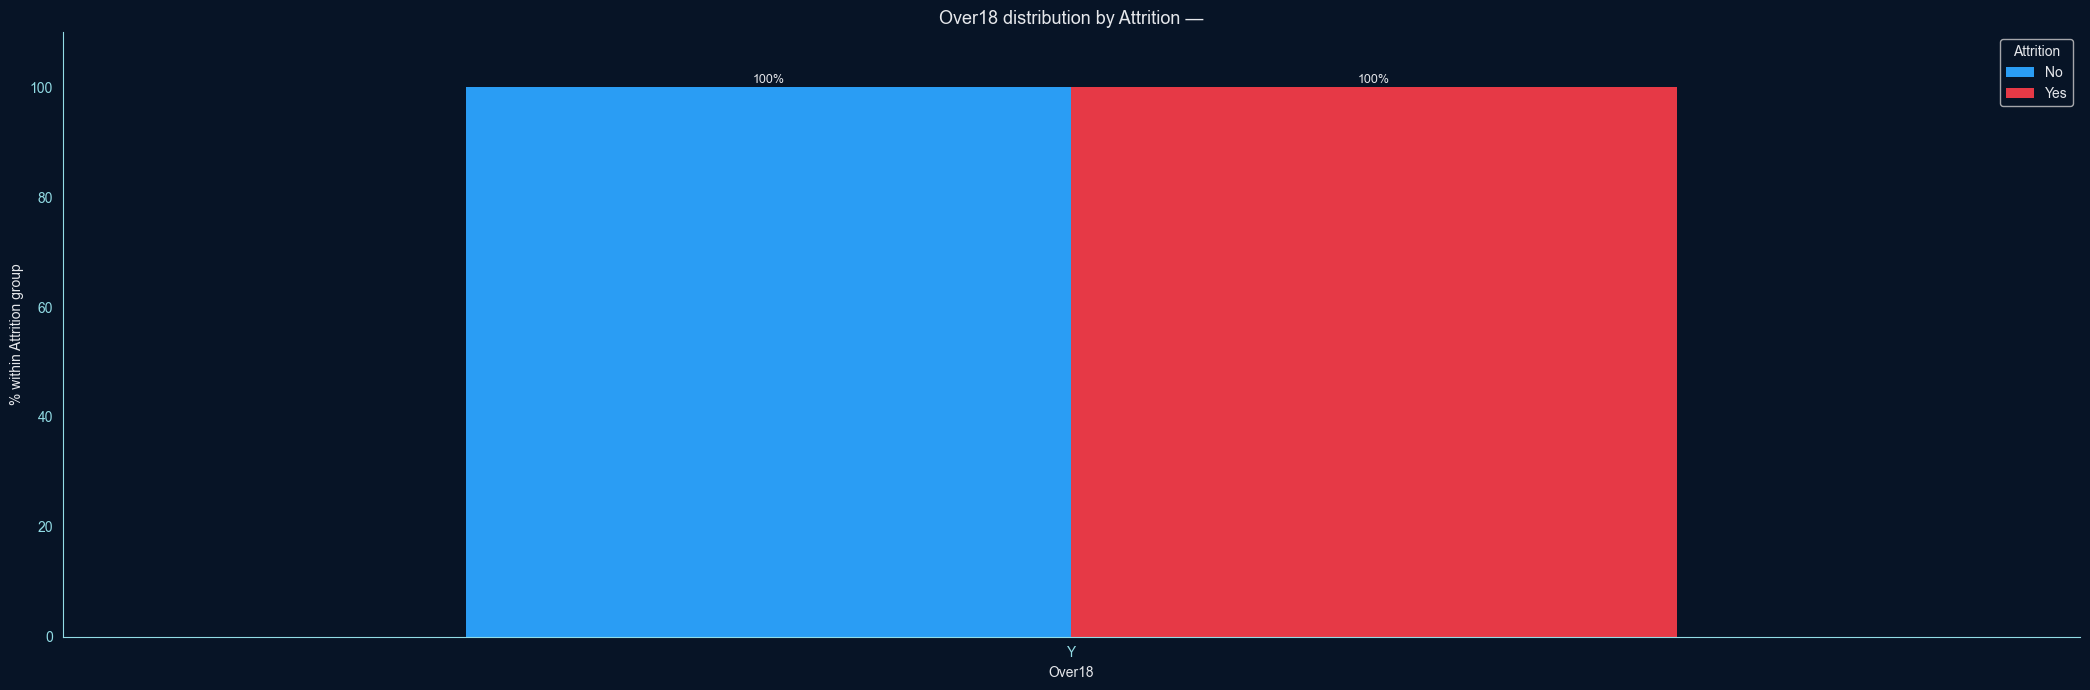

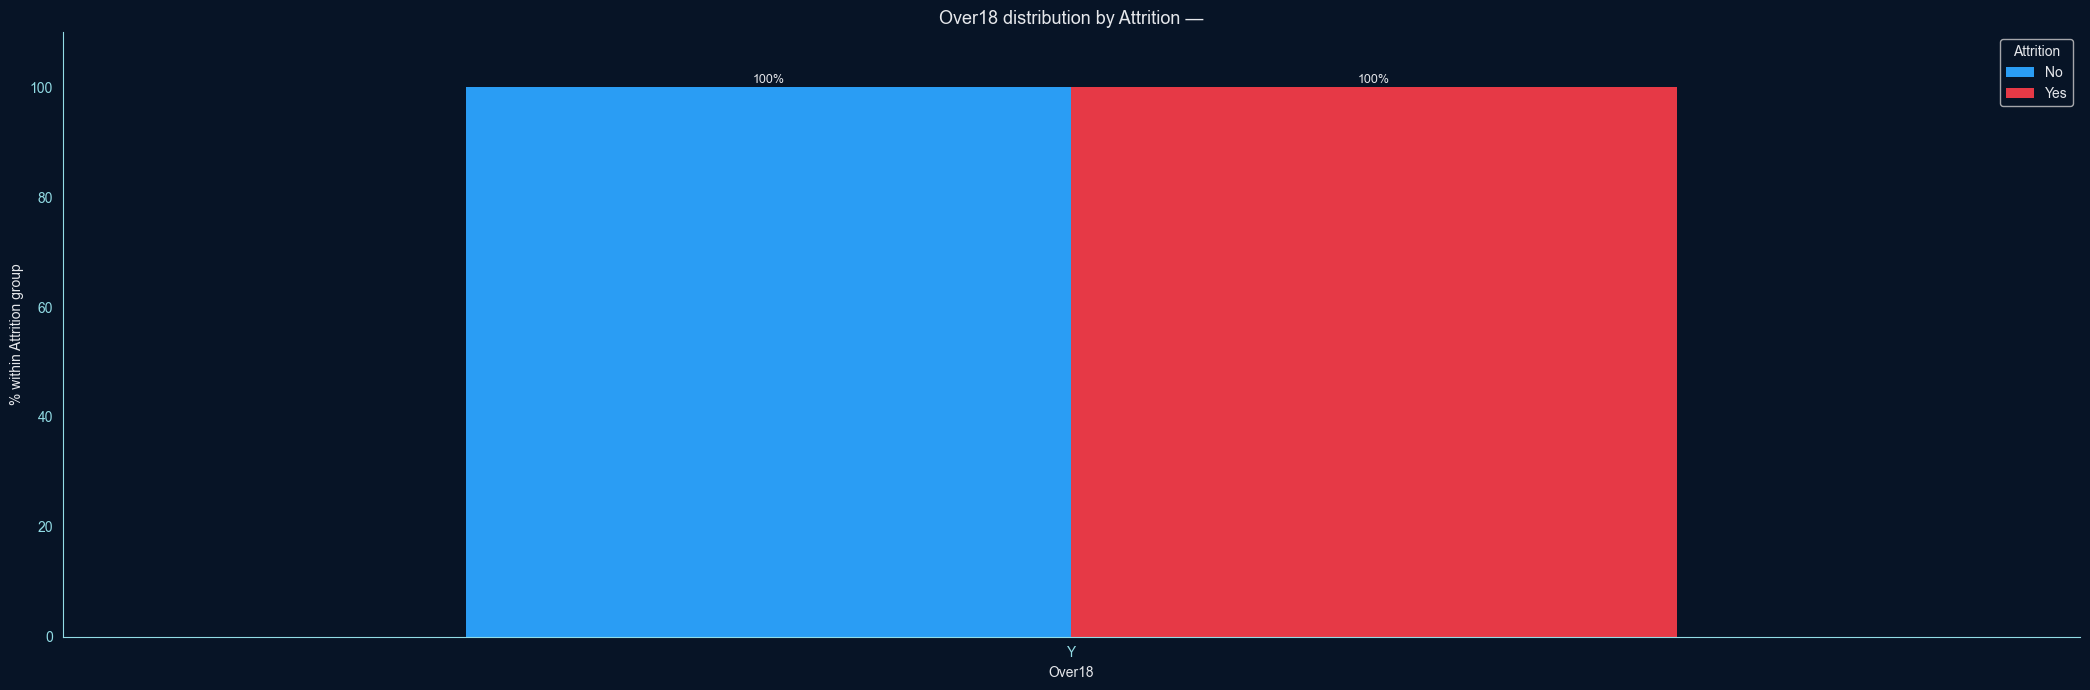

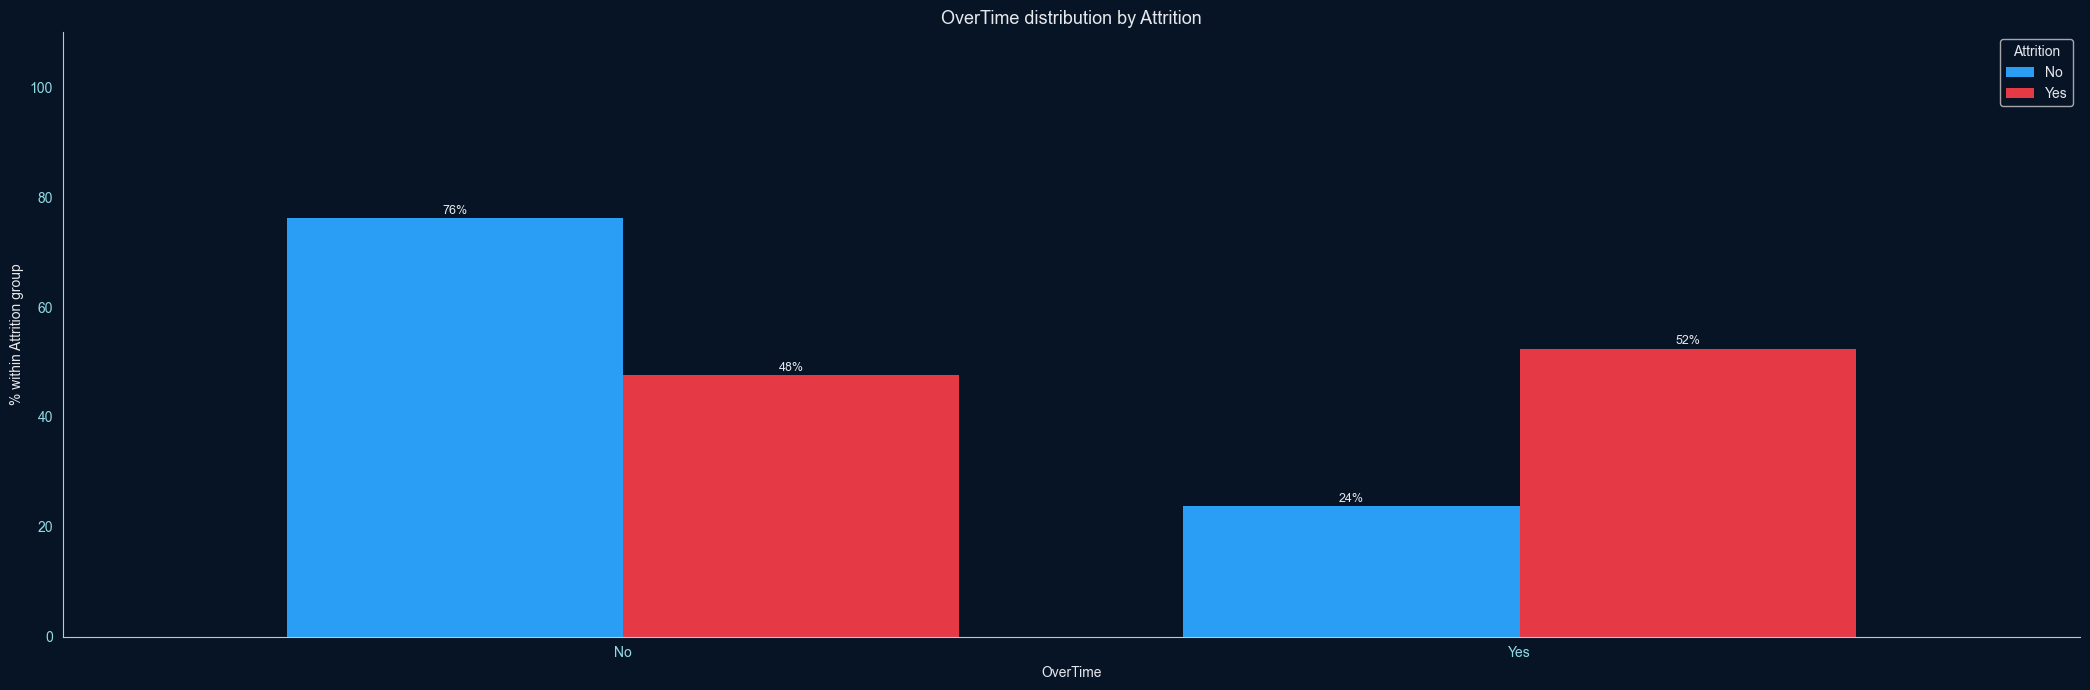

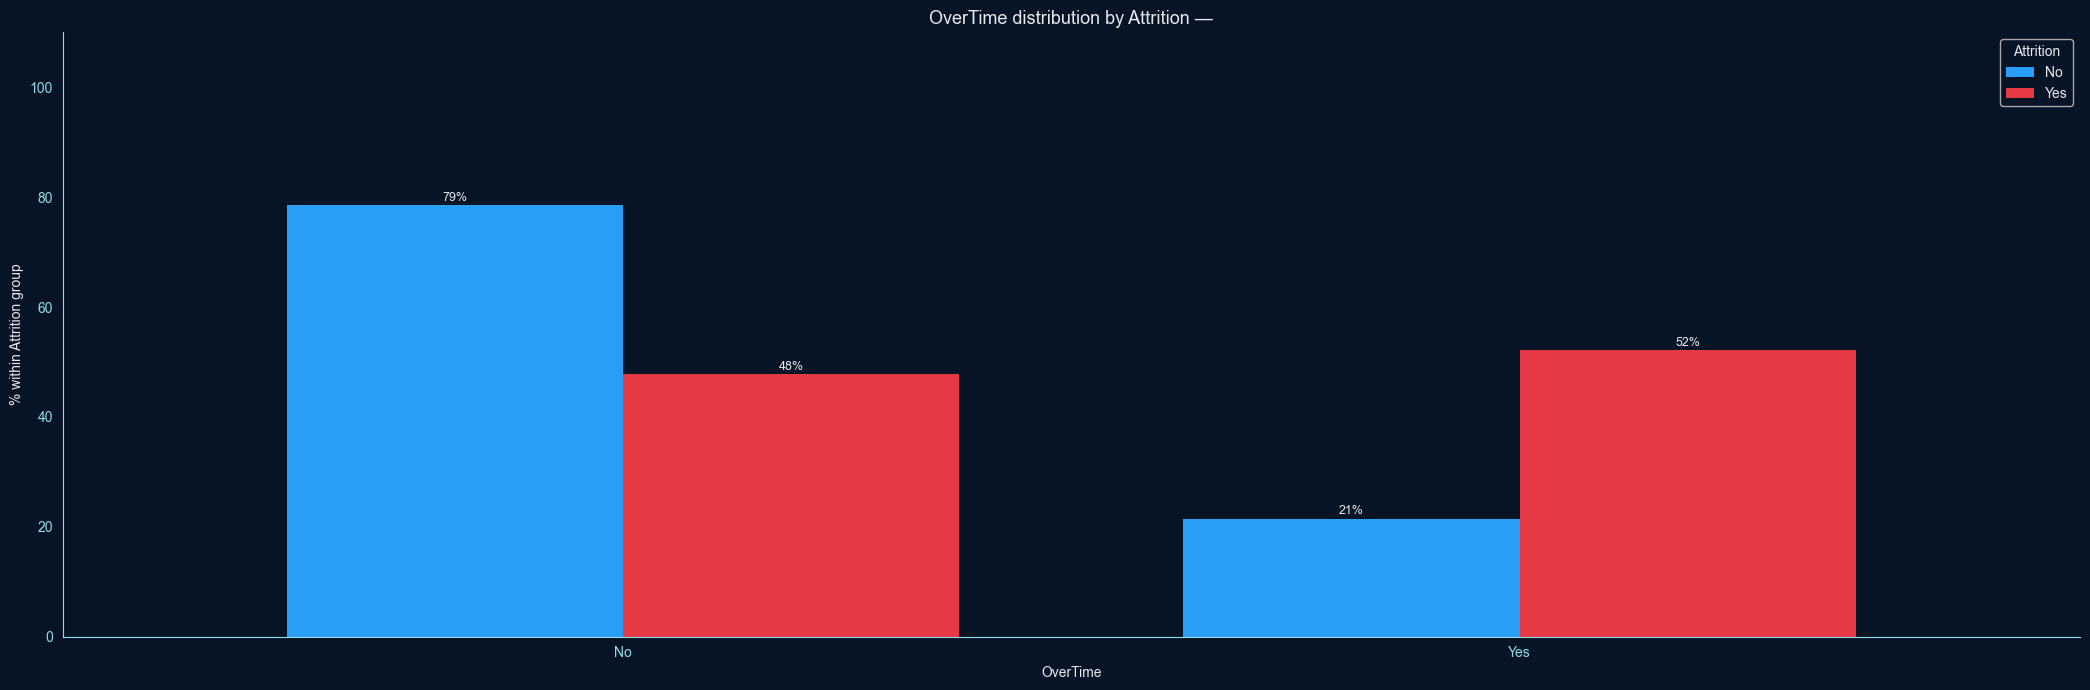

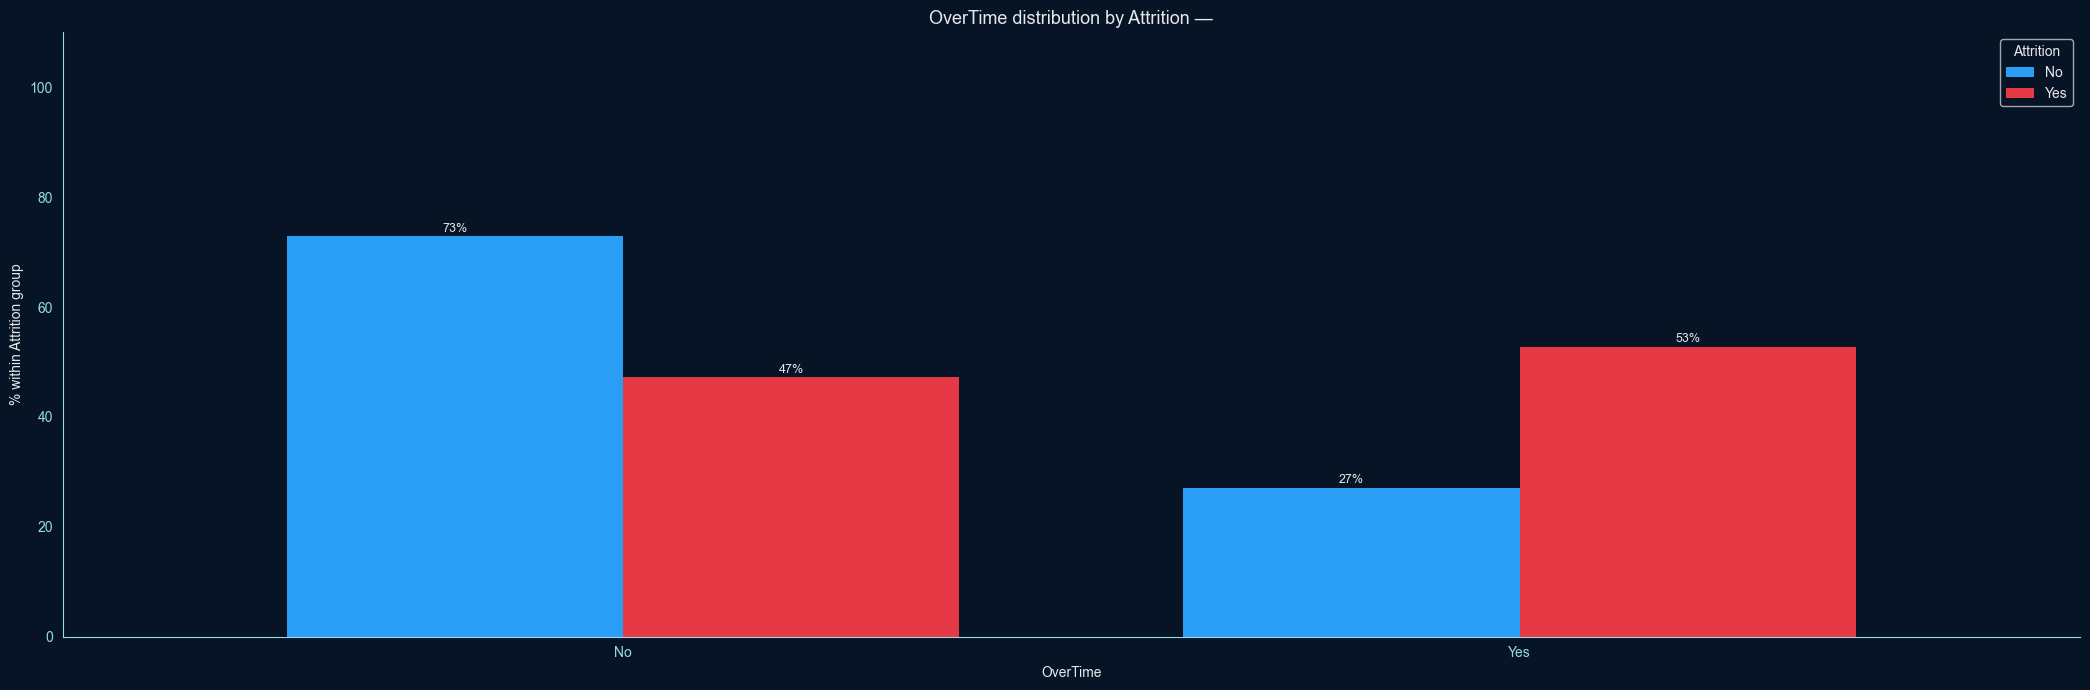

In [11]:
def _add_pct_labels(ax, min_show=1.5, dy=0.8, fmt="{:.0f}%"):
    """Add % labels above bars."""
    for p in ax.patches:
        h = p.get_height()
        if not np.isnan(h) and h >= min_show:
            ax.text(
                p.get_x() + p.get_width()/2,
                h + dy,
                fmt.format(h),
                ha="center",
                fontsize=9,
                color=TEXT_COL
            )

def _plot_crosstab_like_slide(ct_pct, title, xlab=None):
    """
    ct_pct: index=categories, columns should include "No" and "Yes" (Attrition)
    Values already in %.
    """
    # asegurar orden No/Yes
    cols = [c for c in ["No", "Yes"] if c in ct_pct.columns]
    ct_pct = ct_pct[cols]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ct_pct.plot(
        kind="bar",
        ax=ax,
        color=[ATTRITION_NO, ATTRITION_YES][:len(cols)],
        edgecolor="none",     # <- sin borde blanco
        linewidth=0,
        width=0.75
    )

    _add_pct_labels(ax, min_show=1.5, dy=0.8, fmt="{:.0f}%")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("% within Attrition group")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", labelrotation=0)
    ax.spines[["top", "right"]].set_visible(False)

    leg = ax.legend(title="Attrition")
    [t.set_color(TEXT_COL) for t in leg.get_texts()]
    leg.get_title().set_color(TEXT_COL)

    if xlab:
        ax.set_xlabel(xlab)

    plt.tight_layout()
    plt.show()
    plt.close()


def plot_all_cat_features_attrition_and_gender(
    df,
    target="Attrition",
    gender_col="Gender",
    top_n=10,
    min_count=10
):

    cat_cols = [
        c for c in df.select_dtypes(exclude="number").columns
        if c not in [target, gender_col]
    ]

    gender_order = [g for g in ["Male", "Female"] if g in df[gender_col].astype(str).unique()]
    if not gender_order:
        gender_order = sorted(df[gender_col].astype(str).dropna().unique().tolist())

    for col in cat_cols:

        vc = df[col].value_counts(dropna=False)
        valid_cats = vc[vc >= min_count].index
        if len(valid_cats) == 0:
            continue

        top_cats = vc.loc[valid_cats].head(top_n).index

        d0 = df[df[col].isin(top_cats)].copy()
        ct = pd.crosstab(d0[col], d0[target], normalize="columns") * 100
        ct = ct.reindex(top_cats)  # mantiene el orden top_n
        _plot_crosstab_like_slide(
            ct,
            title=f"{col} distribution by Attrition",
            xlab=col
        )

        for g in gender_order:
            dg = df[(df[gender_col].astype(str) == g) & (df[col].isin(top_cats))].copy()
            if dg.empty:
                continue

            ctg = pd.crosstab(dg[col], dg[target], normalize="columns") * 100
            ctg = ctg.reindex(top_cats)
            _plot_crosstab_like_slide(
                ctg,
                title=f"{col} distribution by Attrition —",
                xlab=col
            )


# ---------------------------
# RUN
# ---------------------------
plot_all_cat_features_attrition_and_gender(df, target="Attrition", gender_col="Gender", top_n=10, min_count=10)


In [12]:
def percent_bar_attrition(df, col):
    """
    Plots percentage distribution of a categorical variable
    conditioned on Attrition (Yes vs No).
    Saves the figure automatically.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # ---- Compute conditional percentages ----
    ct = pd.crosstab(df[col], df["Attrition"], normalize="columns") * 100

    # Order categories by highest attrition (Yes)
    if "Yes" in ct.columns:
        ct = ct.sort_values(by="Yes", ascending=False)

    # ---- Plot ----
    ax = ct.plot(
        kind="bar",
        figsize=(21,7),
        color=[ATTRITION_NO, ATTRITION_YES],  # No = blue, Yes = red
        edgecolor="white",
        linewidth=0.1
    )

    # ---- Titles & labels ----
    plt.title(f"{col} distribution by Attrition", fontsize=13)
    plt.ylabel("Percentage within Attrition group")
    plt.xlabel(col)
    plt.xticks(rotation=0)

    # ---- Legend style ----
    leg = plt.legend(title="Attrition")
    plt.setp(leg.get_texts(), color=TEXT_COL)
    plt.setp(leg.get_title(), color=TEXT_COL)

    # ---- Add % labels on bars ----
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.text(
                p.get_x() + p.get_width()/2,
                height + 1,
                f"{height:.0f}%",
                ha="center",
                fontsize=9,
                color=TEXT_COL
            )

    plt.tight_layout()

    # ---- Save for slides ----
    plt.savefig(f"{col}_attrition.png", dpi=300, bbox_inches="tight")

    plt.show()


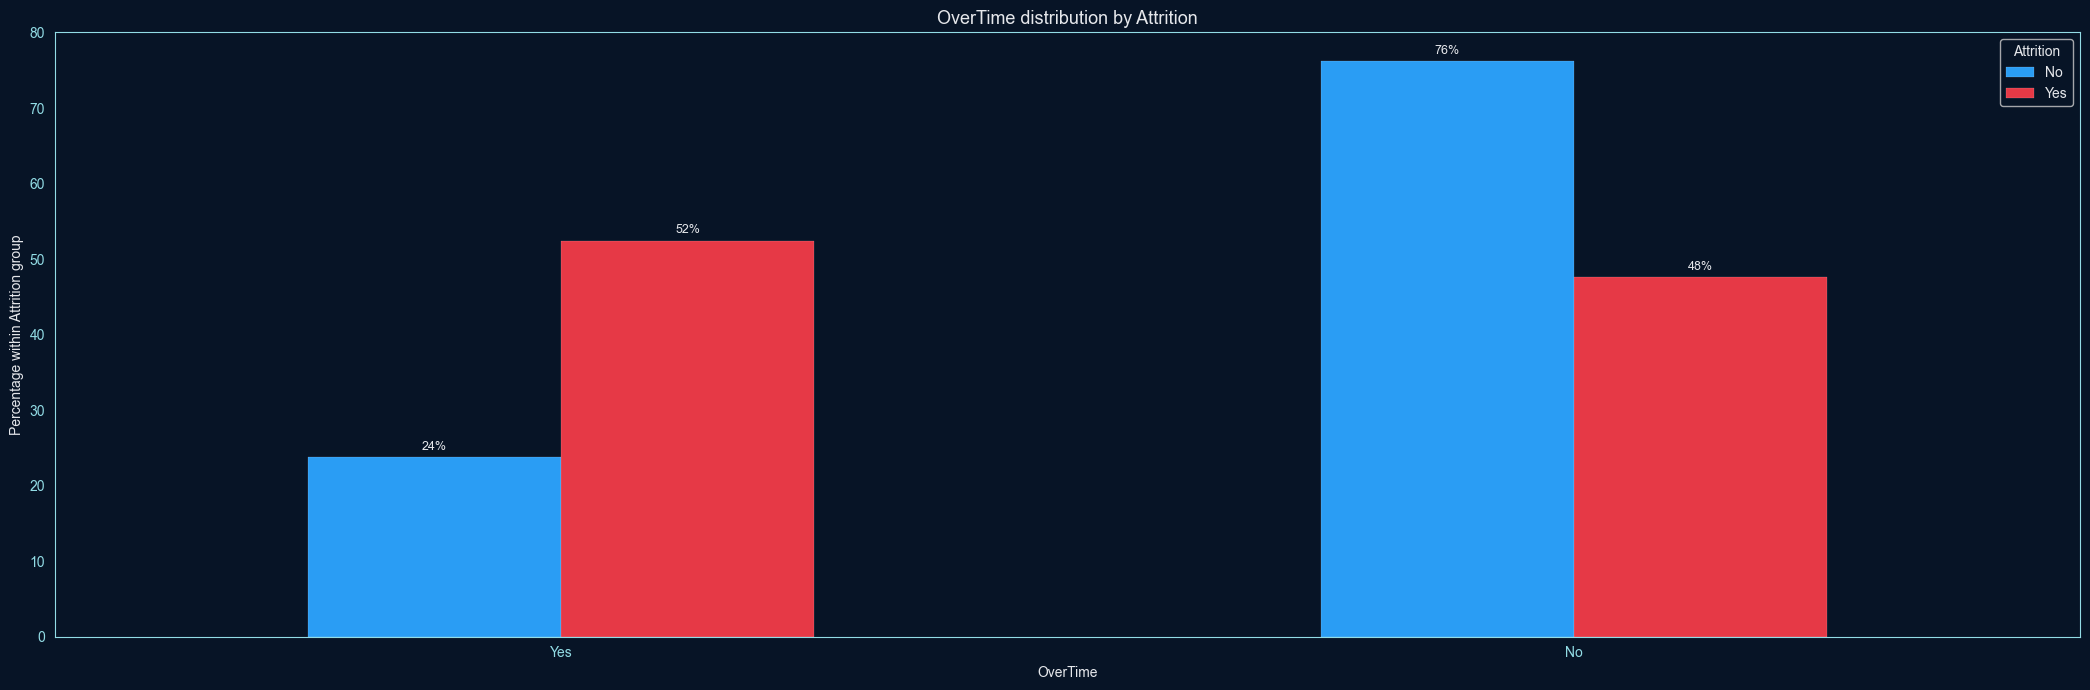

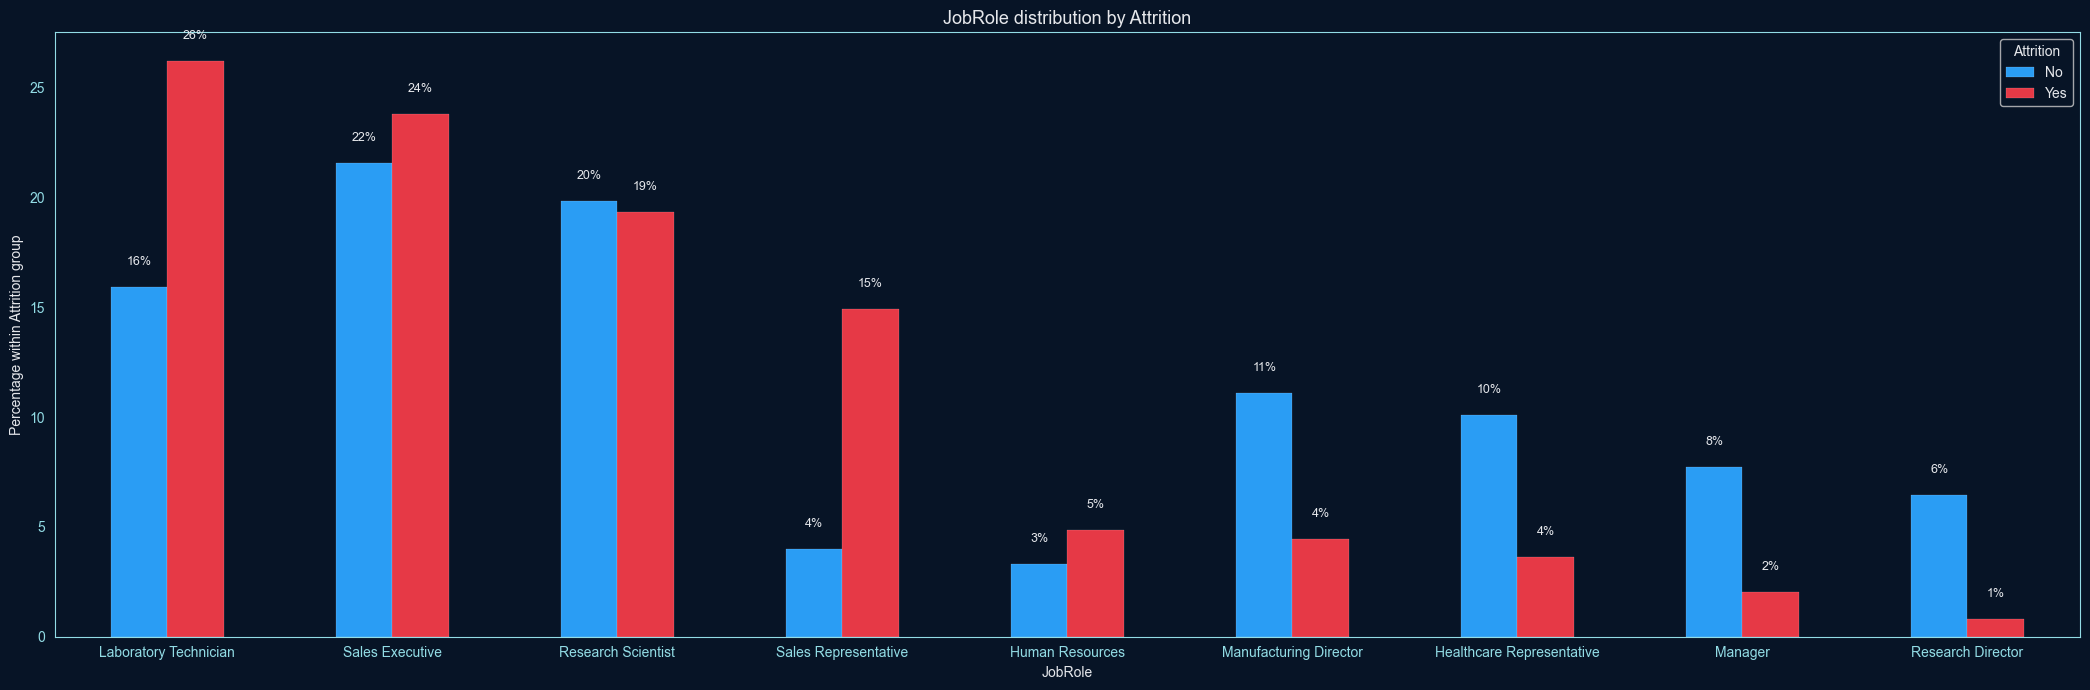

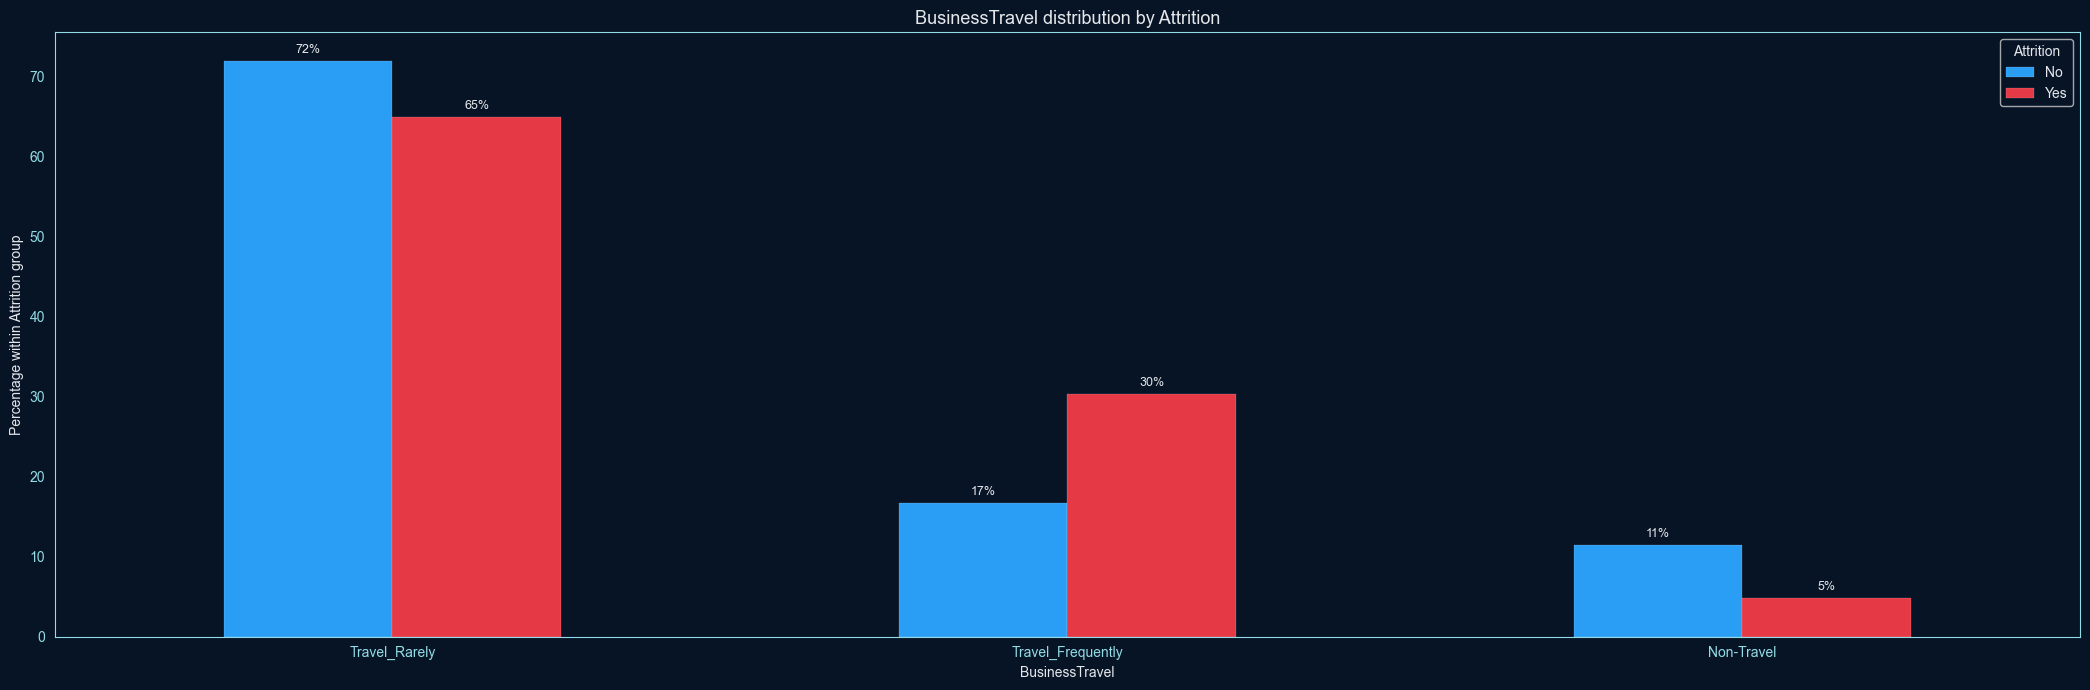

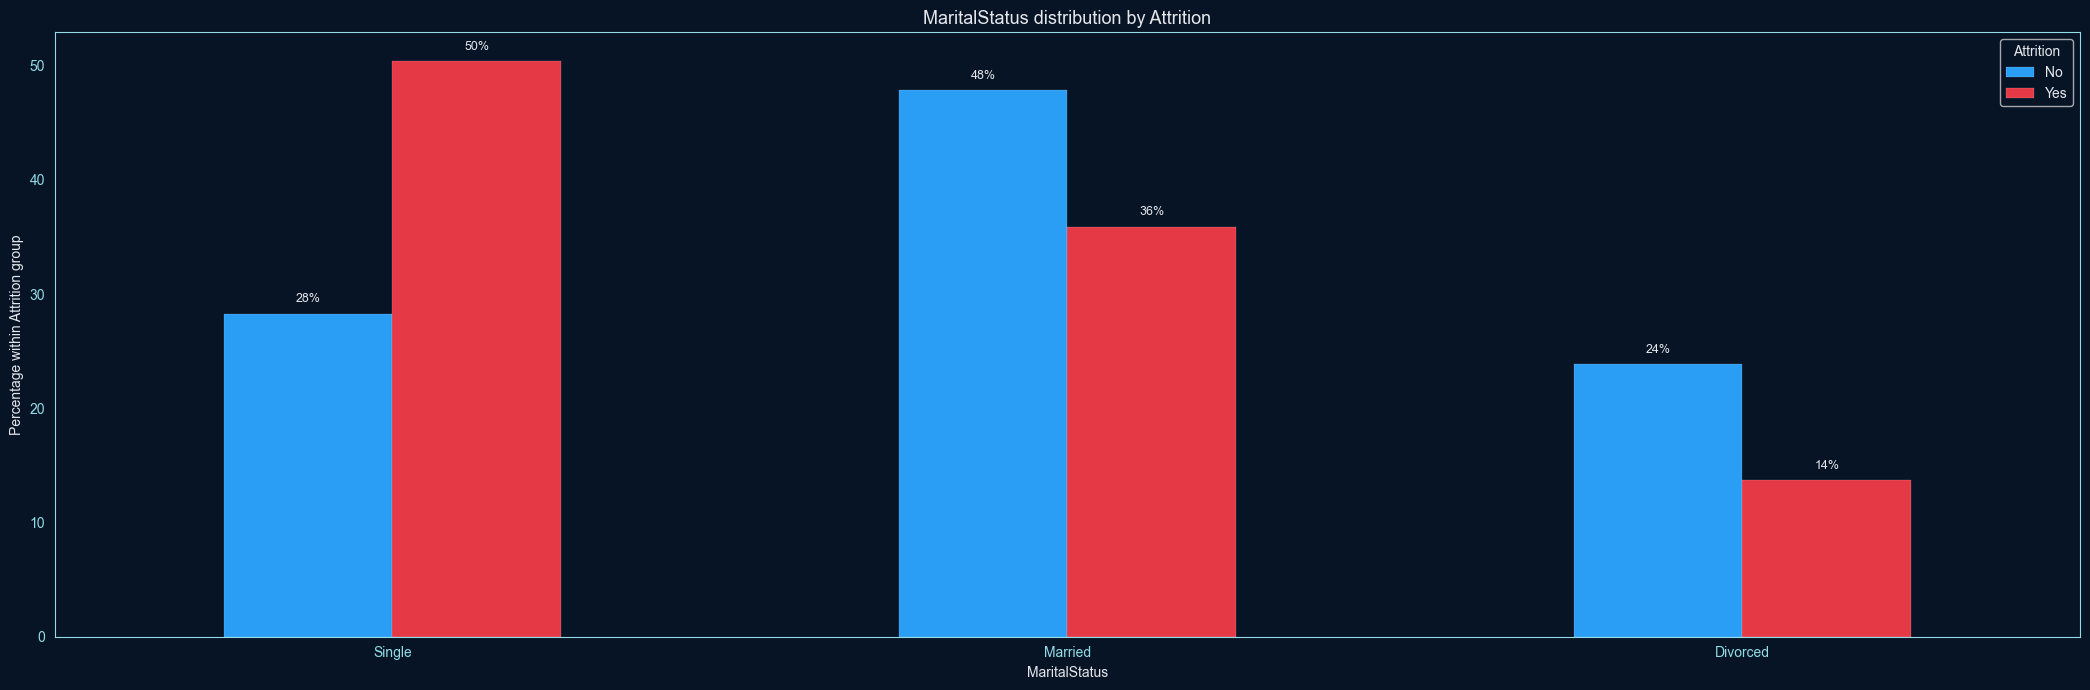

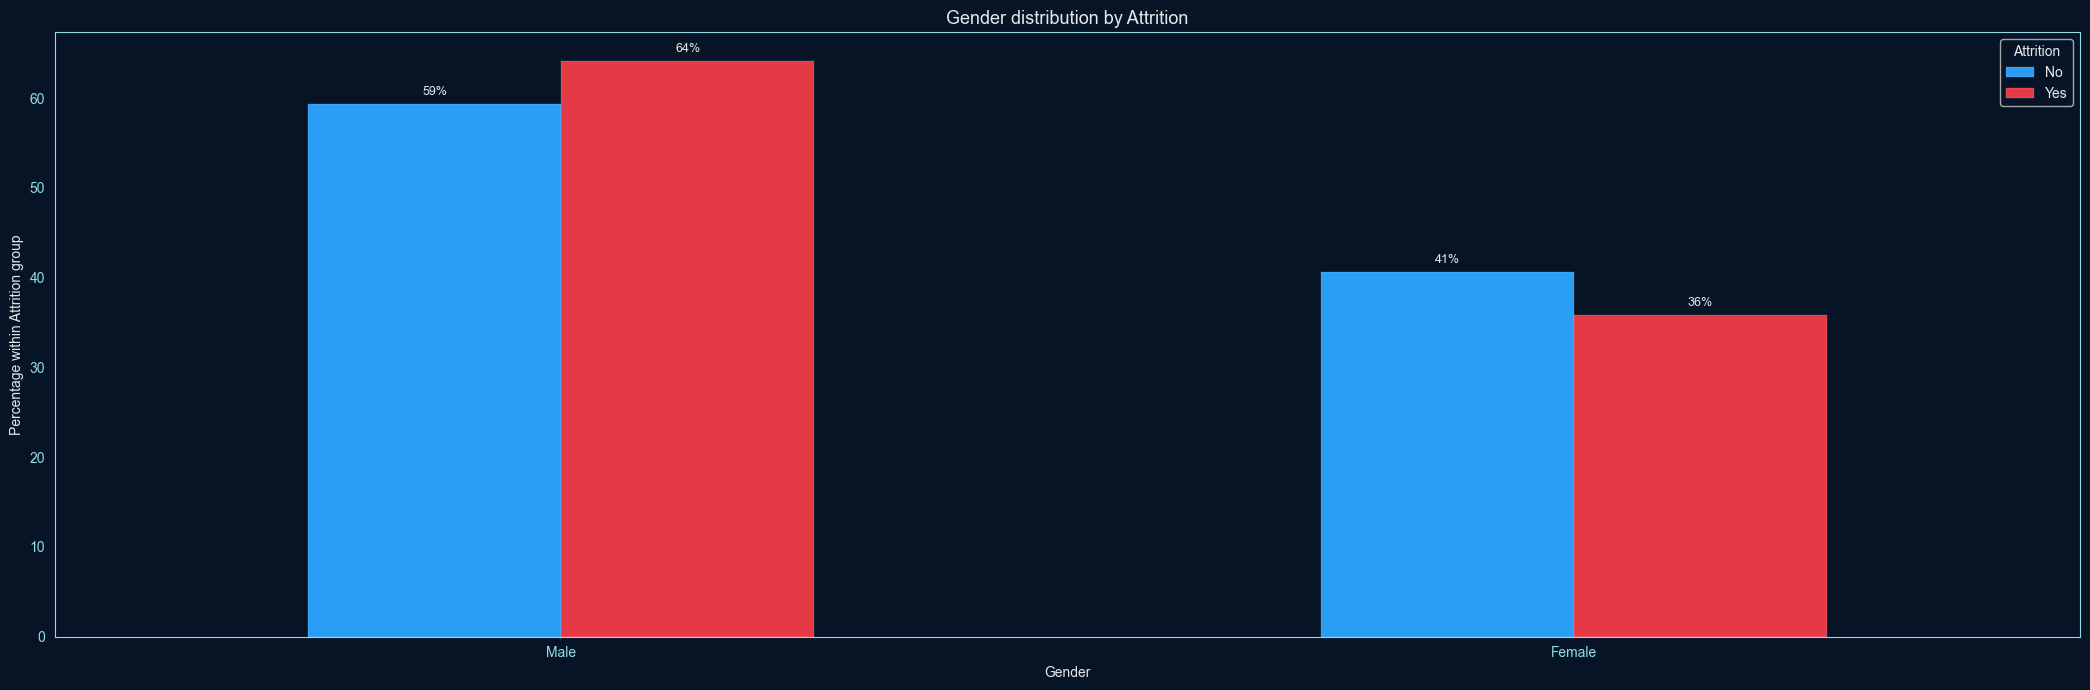

In [13]:
percent_bar_attrition(df, "OverTime")
percent_bar_attrition(df, "JobRole")
percent_bar_attrition(df, "BusinessTravel")
percent_bar_attrition(df, "MaritalStatus")
percent_bar_attrition(df, "Gender")


Gender differences in attrition are minimal and do not explain employee turnover. Instead, attrition is strongly associated with working conditions, particularly overtime. The results support the systemic hypothesis: workload and organizational factors are the main drivers of employee resignation.

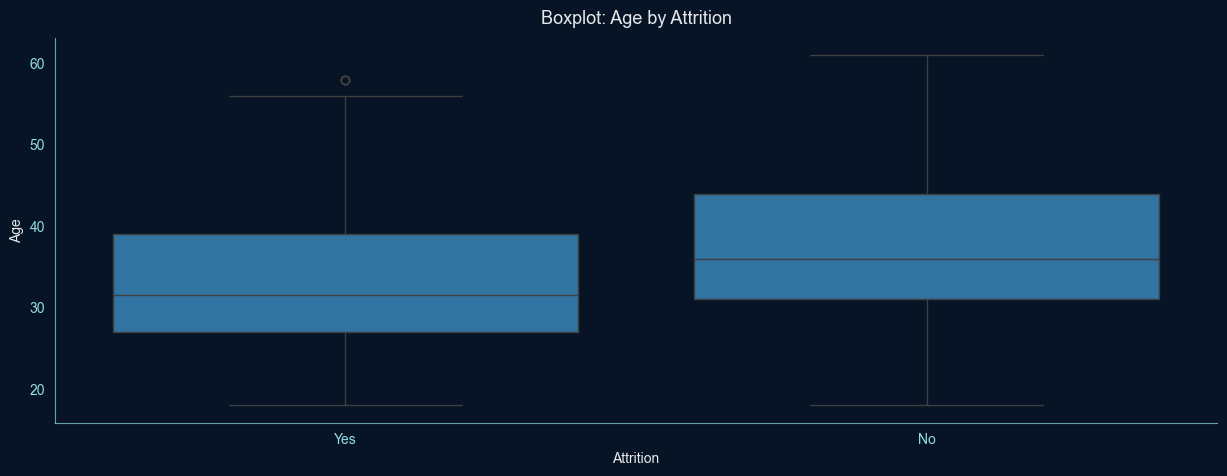

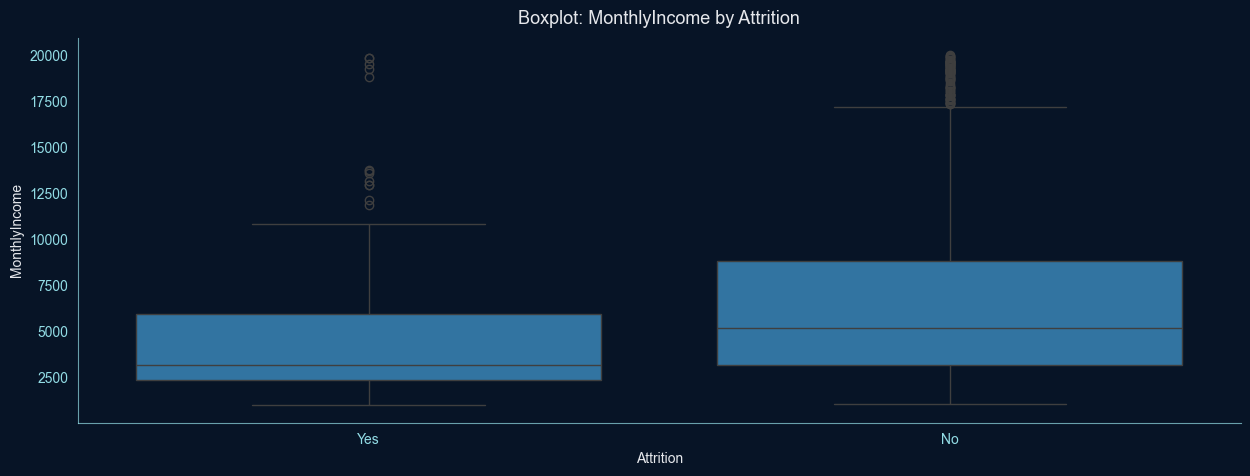

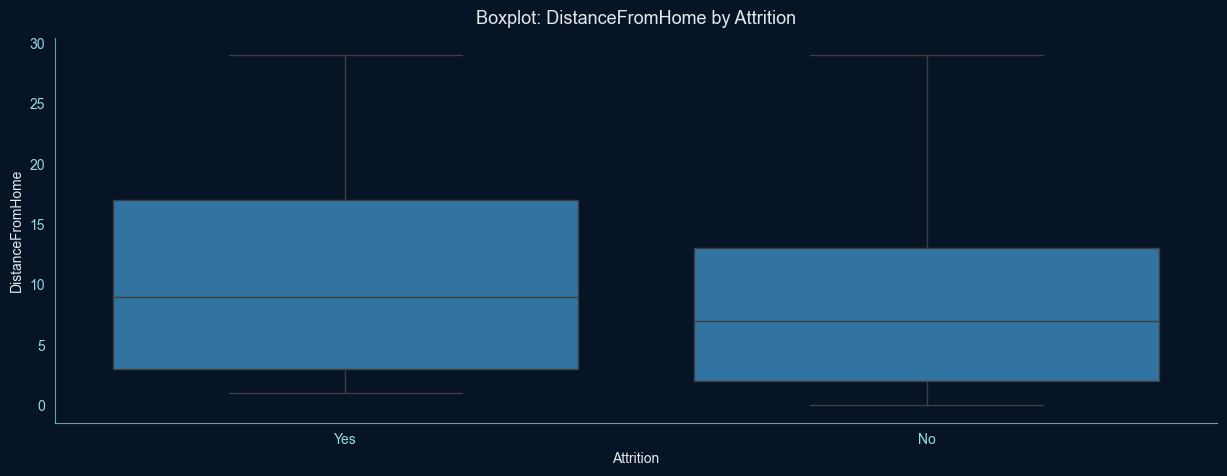

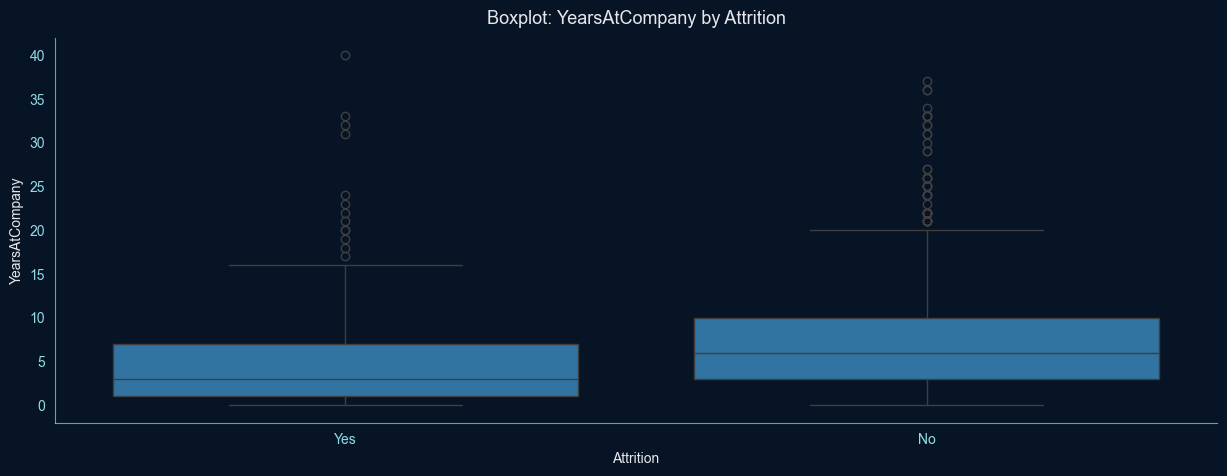

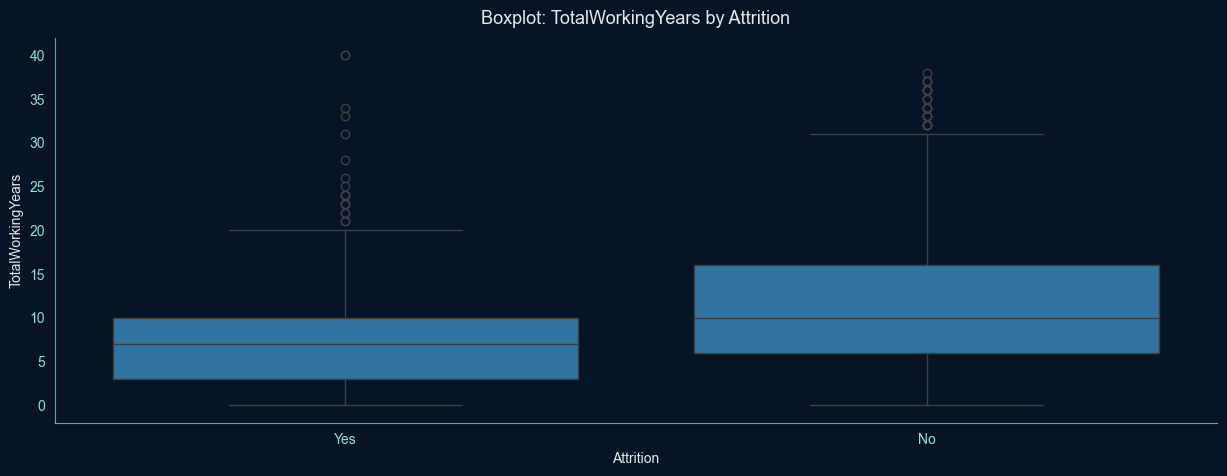

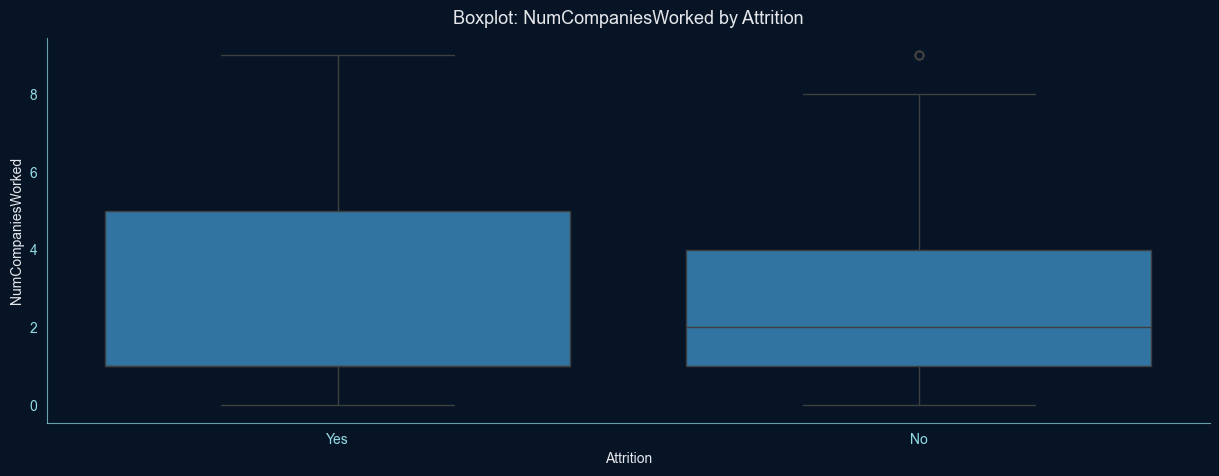

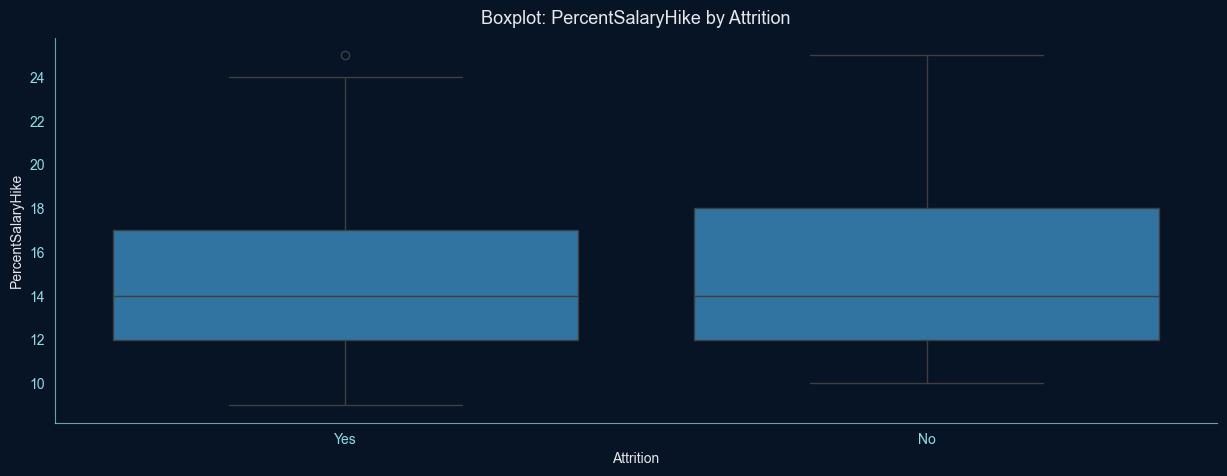

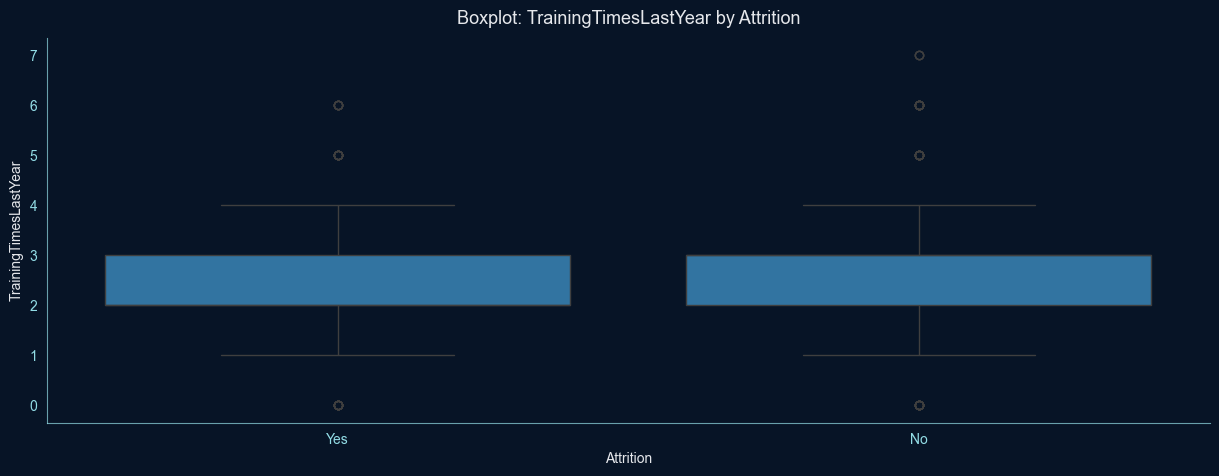

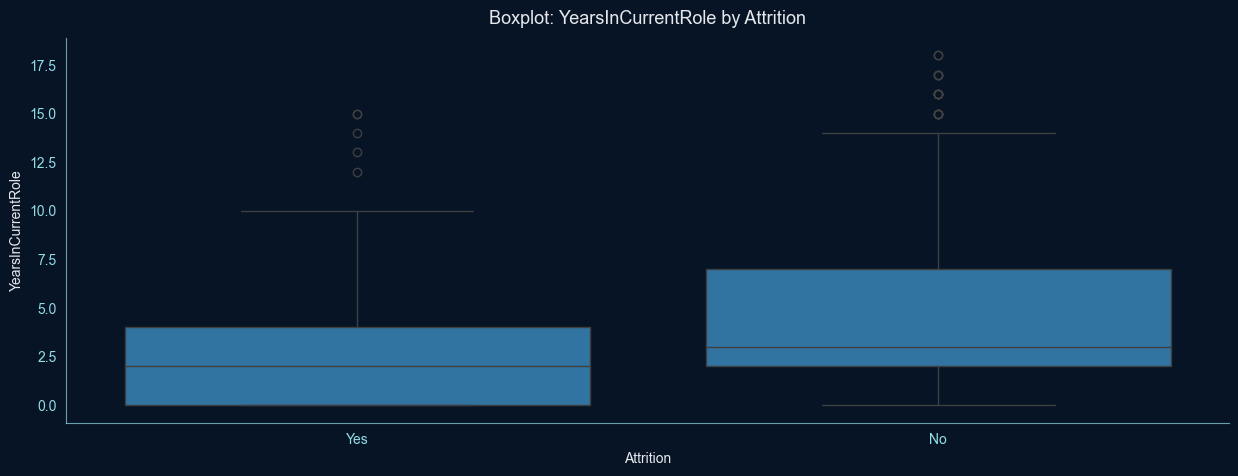

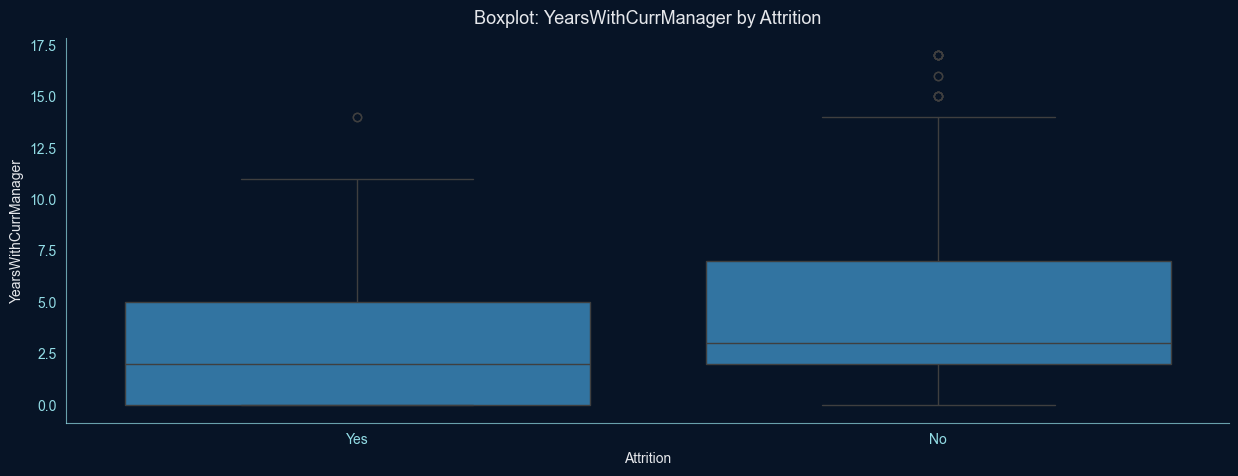

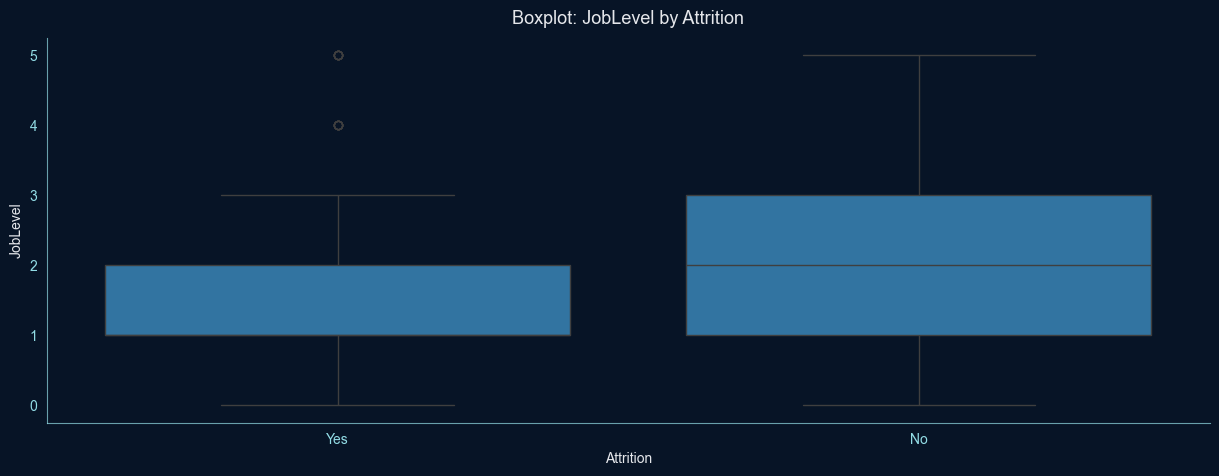

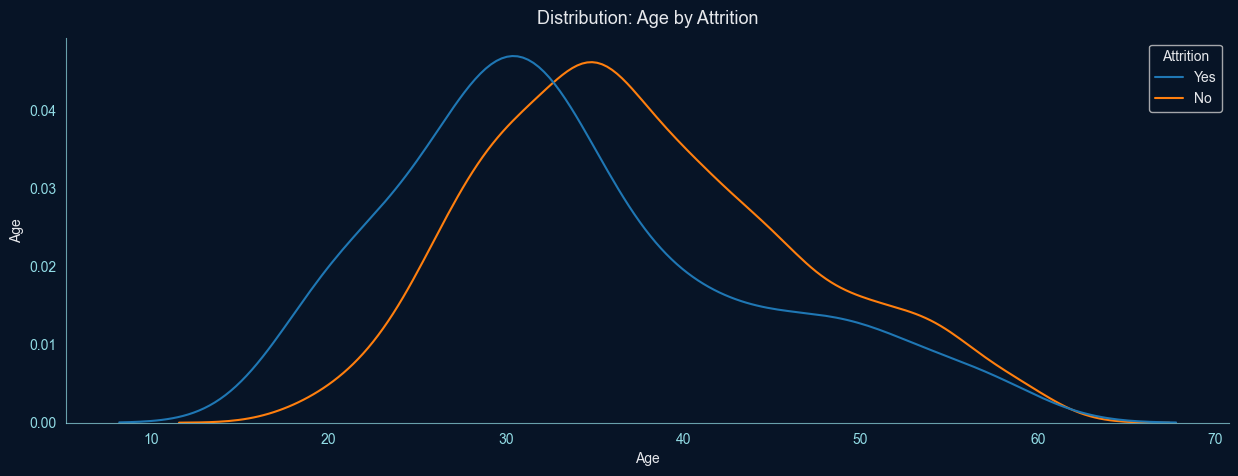

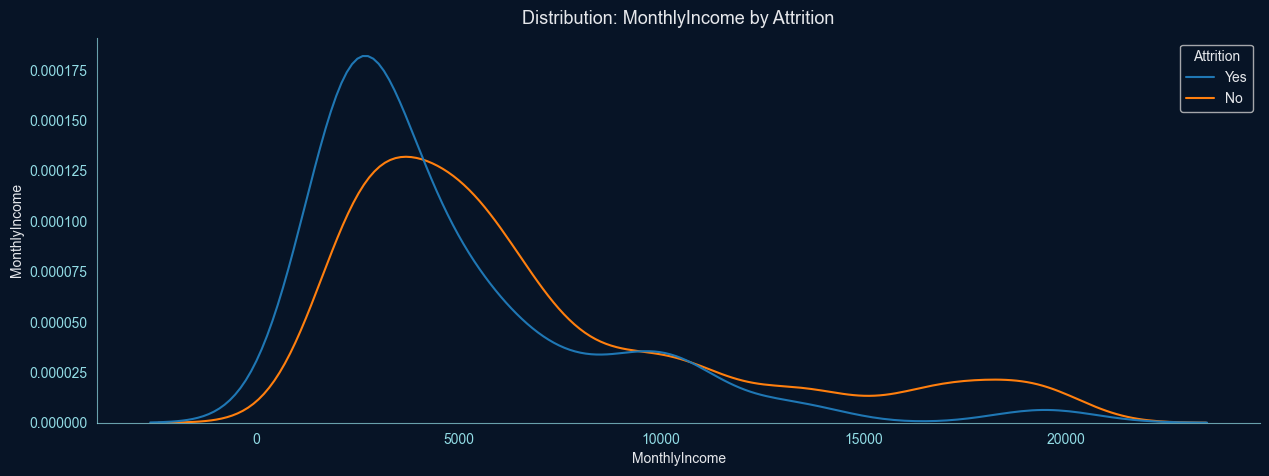

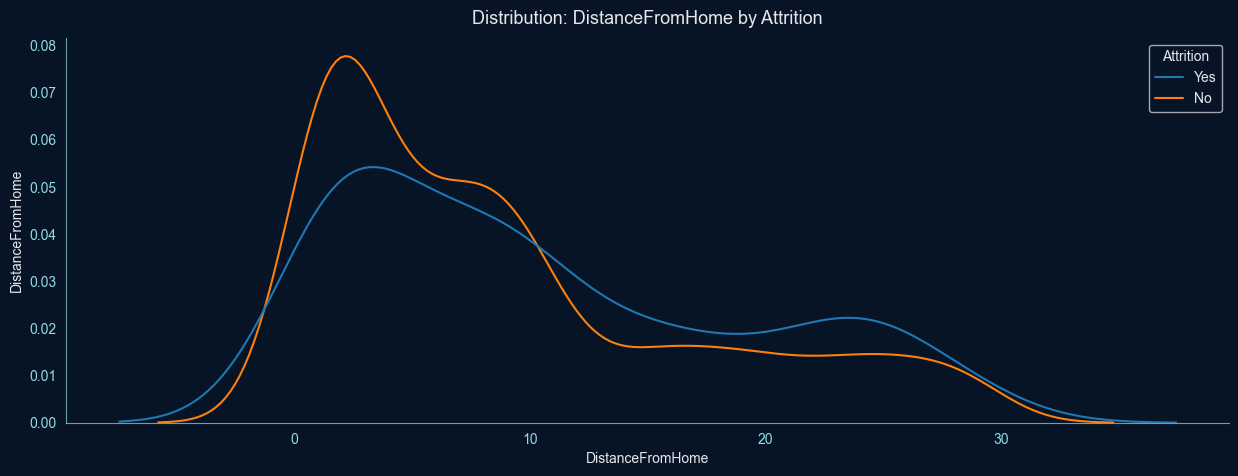

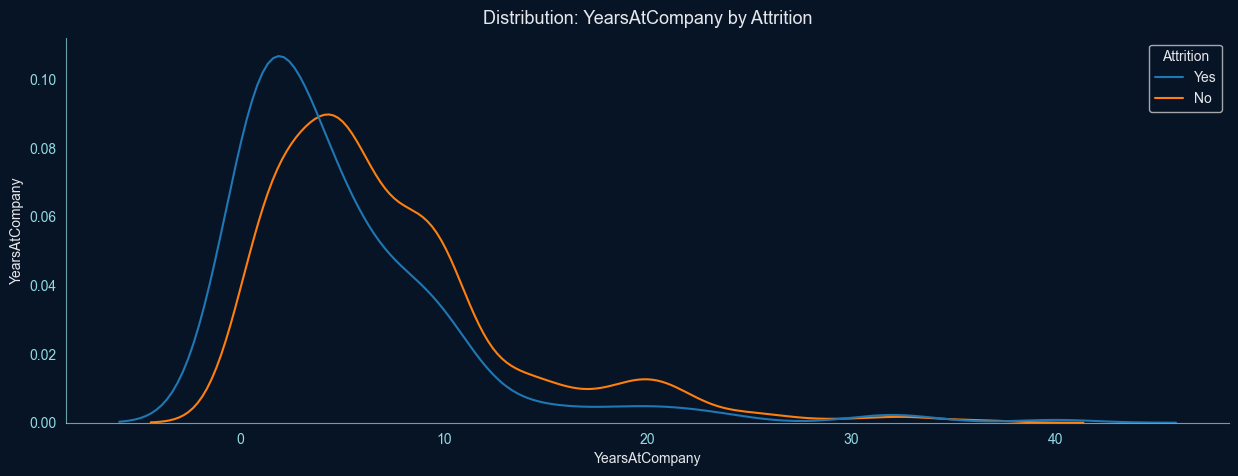

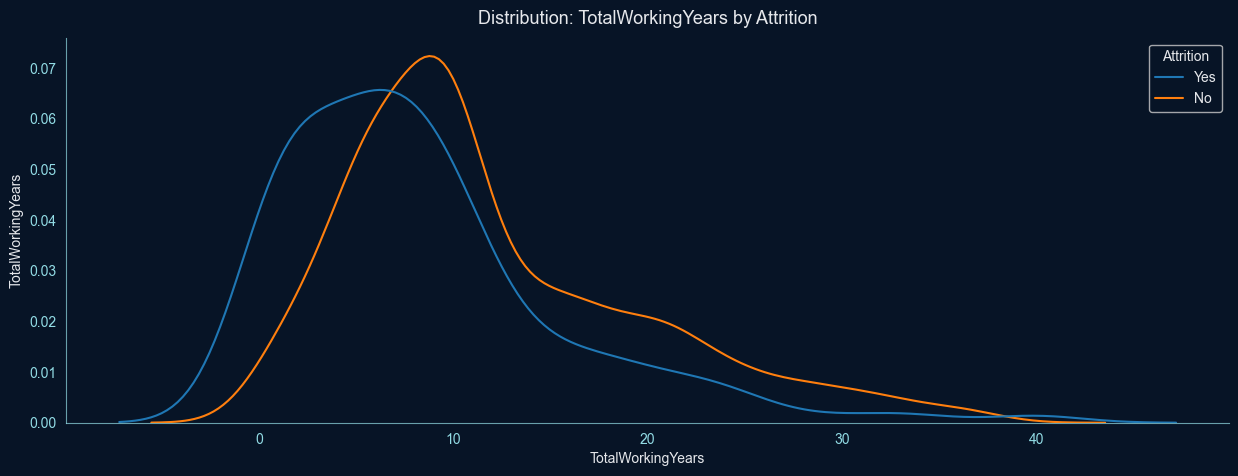

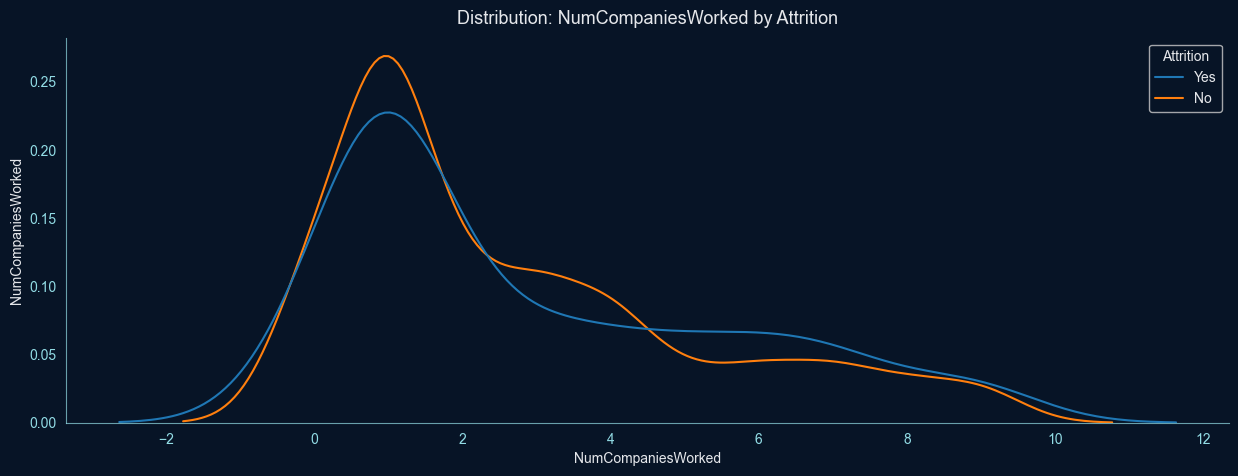

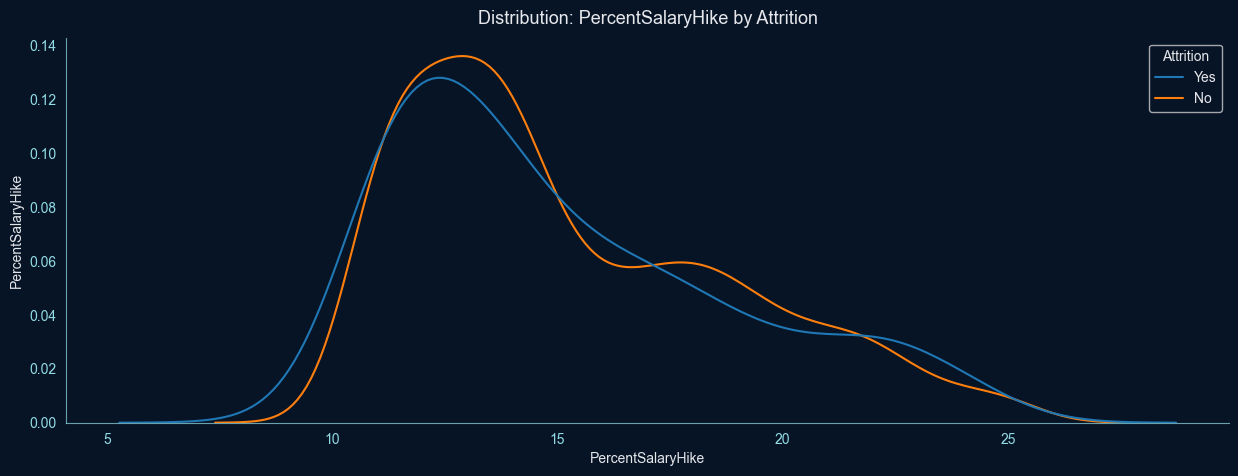

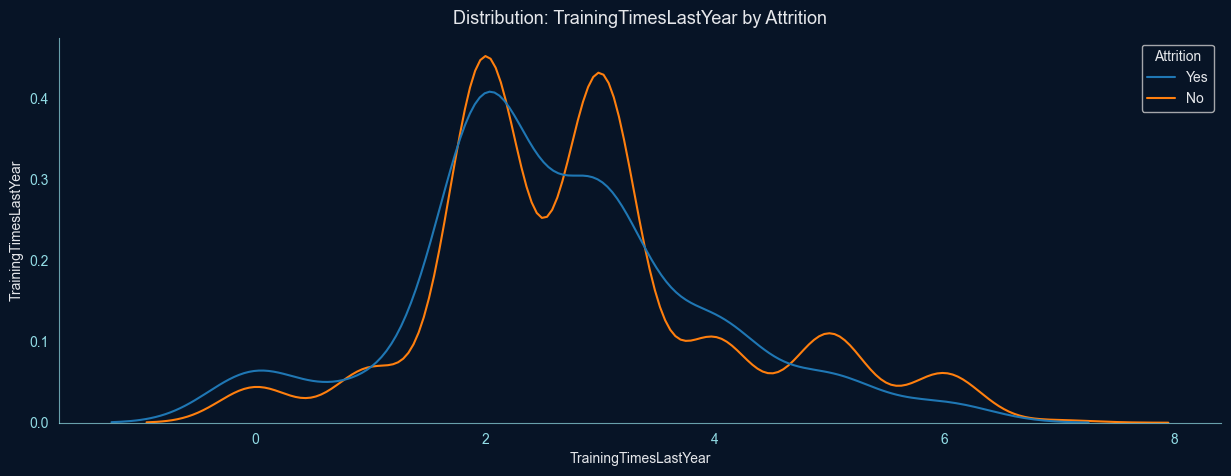

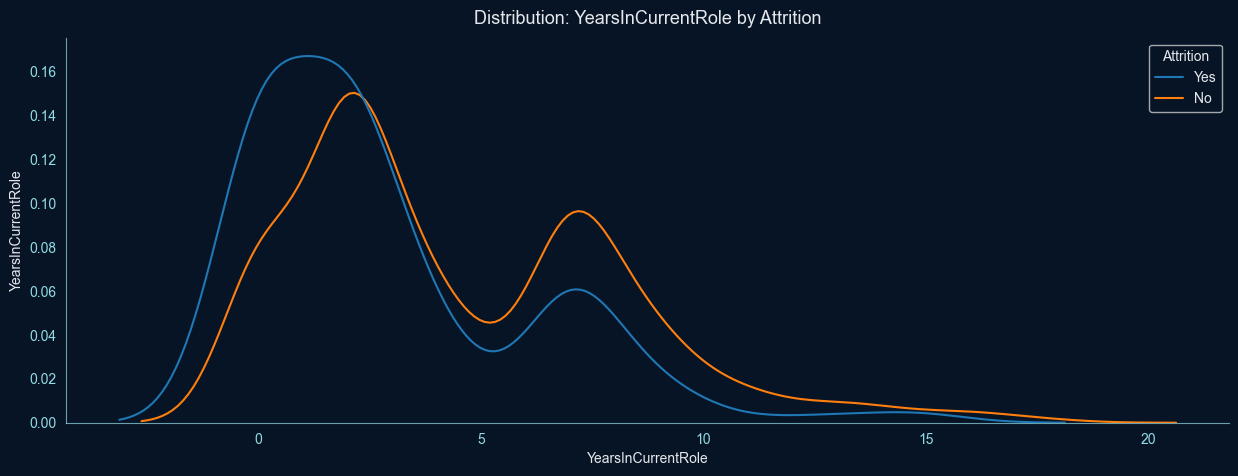

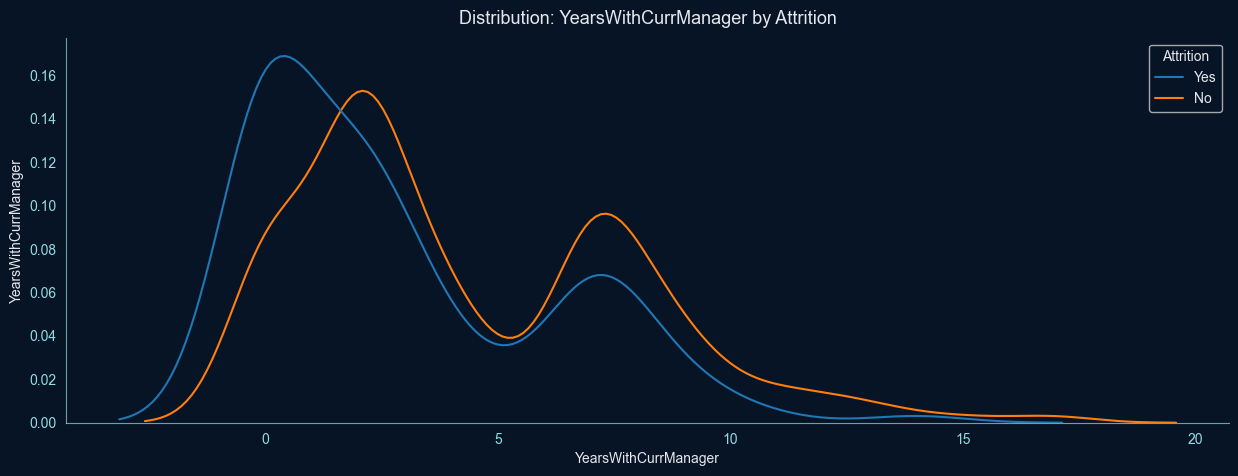

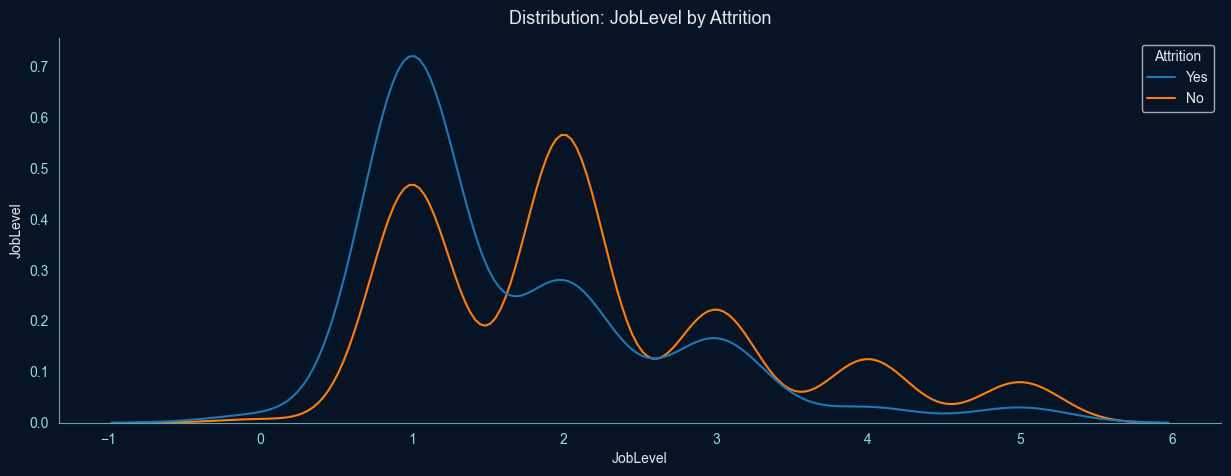

In [14]:
# NUMERICAL EDA — distributions by attrition (robust visuals)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Selección razonable (si existen)
cand_nums = [
    "Age","MonthlyIncome","DistanceFromHome","YearsAtCompany","TotalWorkingYears",
    "NumCompaniesWorked","PercentSalaryHike","TrainingTimesLastYear",
    "YearsInCurrentRole","YearsWithCurrManager","JobLevel", "Overtime"
]
num_cols = [c for c in cand_nums if c in df.columns]

for c in num_cols:
    fig, ax = plt.subplots(figsize=(15, 5))
    sns.boxplot(data=df, x="Attrition", y=c, ax=ax)
    _style_ax(ax, f"Boxplot: {c} by Attrition", c)
    plt.xticks(rotation=0)  # ✅ horizontal
    plt.show()
    plt.close(fig)

for c in num_cols:
    fig, ax = plt.subplots(figsize=(15, 5))
    sns.kdeplot(data=df, x=c, hue="Attrition", common_norm=False, ax=ax)
    _style_ax(ax, f"Distribution: {c} by Attrition", c)
    plt.xticks(rotation=0)
    plt.show()
    plt.close(fig)


Outliers were kept because they represent real employees, not errors. Attrition is concentrated among low-income and newly hired employees, meaning the problem occurs early in the employee lifecycle.

The distributions already show meaningful patterns. Employees who left the company tend to present lower Monthly Income and shorter tenure in the organization. The density curves indicate that attrition is concentrated among recently hired employees and those in lower salary ranges, suggesting dissatisfaction occurs early in the employee lifecycle and is strongly associated with compensation level.

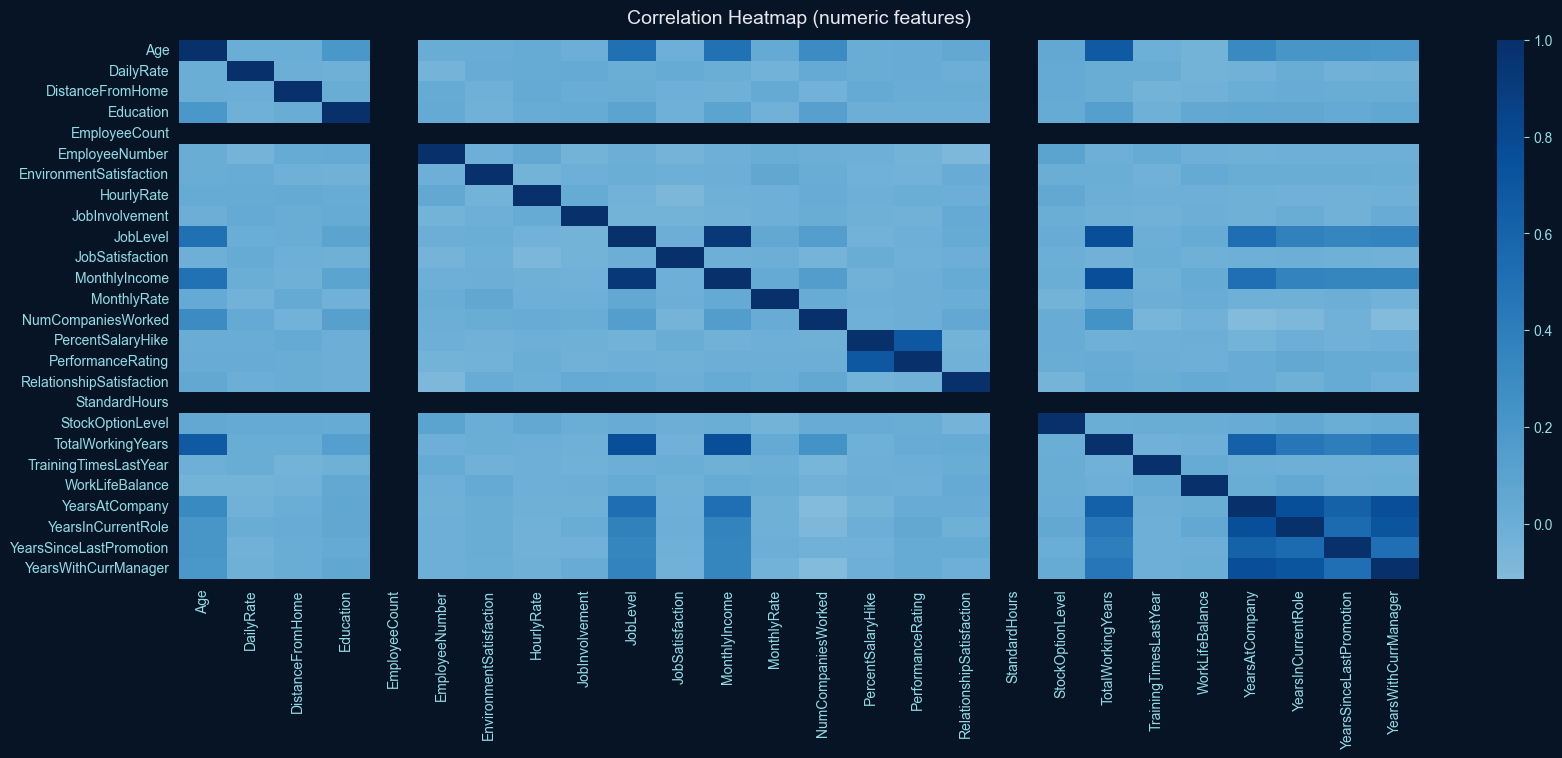

In [15]:
# CORRELATION (numeric)

num_cols = df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 1:
    corr = df[num_cols].corr()

    plt.figure(figsize=(20, 7))
    sns.heatmap(corr, cmap="Blues", center=0, linewidths=0.00)
    plt.title("Correlation Heatmap (numeric features)", fontsize=14, pad=12)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


The correlation heatmap reveals strong relationships among tenure-related variables (TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager). These variables capture similar information about employee seniority and may introduce redundancy in the predictive model. Therefore, dimensionality reduction techniques such as PCA are justified to reduce multicollinearity and improve model stability.


## PCA + CLUSTERING

In [16]:
# PREP FOR PCA + CLUSTERING

# Keep only numeric features for PCA (standard practice)
X_num = df.select_dtypes(include=[np.number]).copy()

num_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = num_preprocess.fit_transform(X_num)
print("Scaled numeric matrix:", X_scaled.shape)

Scaled numeric matrix: (1518, 26)


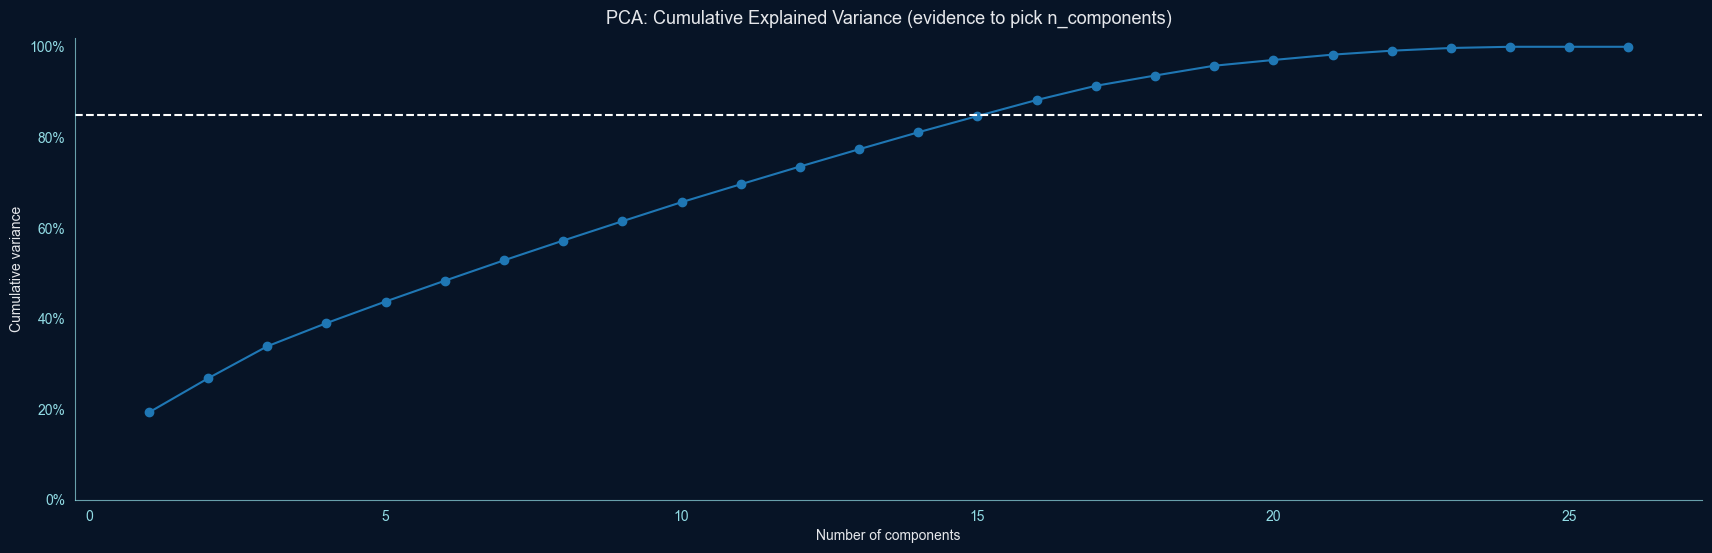

Chosen n_components for 90% variance: 17


In [17]:
# PCA

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, ax = plt.subplots(figsize=(21, 6))
ax.plot(range(1, len(cum)+1), cum, marker="o")
_style_ax(ax, "PCA: Cumulative Explained Variance (evidence to pick n_components)", "Cumulative variance")
ax.set_xlabel("Number of components")
ax.set_ylim(0, 1.02)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{v*100:.0f}%" for v in np.linspace(0,1,6)])
plt.axhline(0.85, linestyle='--', color='white')
plt.xticks(rotation=0)
plt.show()
plt.close(fig)

# Choose components by threshold (commonly 80% or 90%)
thr = 0.90
n_comp = int(np.argmax(cum >= thr) + 1)
print(f"Chosen n_components for {thr*100:.0f}% variance: {n_comp}")


17 principal components were selected because they retain ~90% of the dataset’s variance, allowing dimensionality reduction while preserving most employee information.

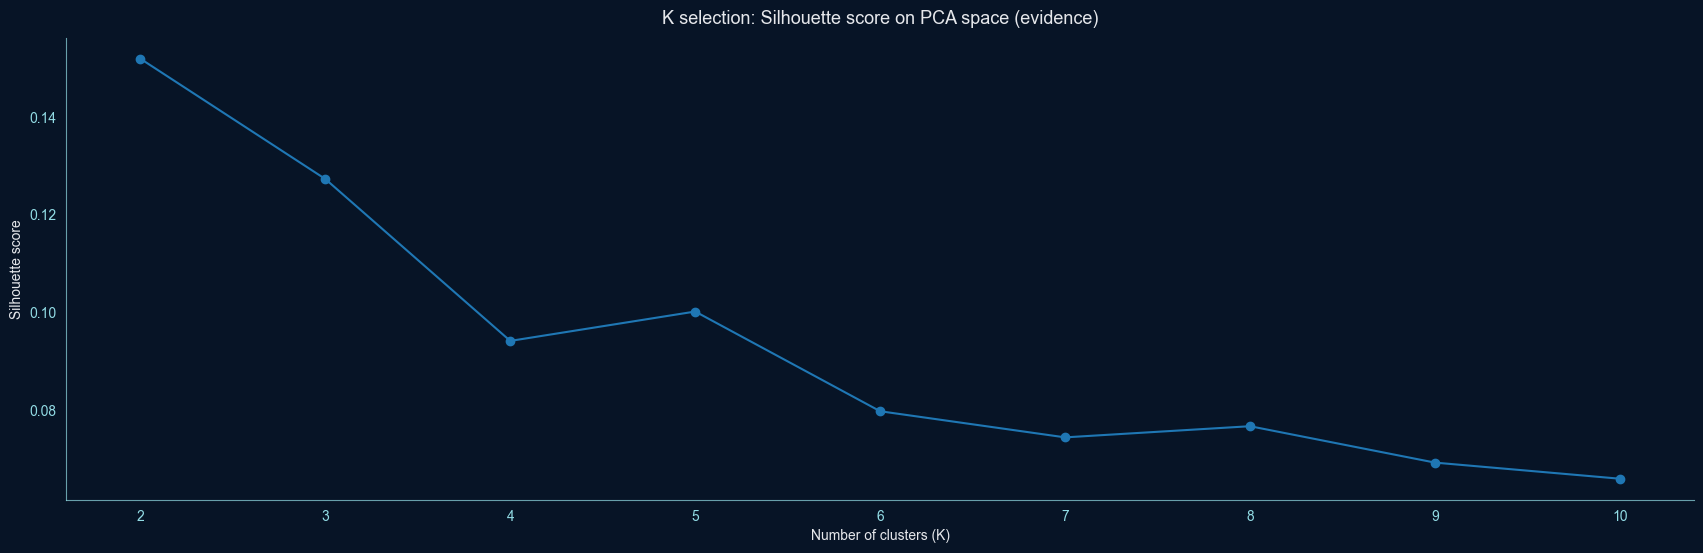

Best K by silhouette: 3


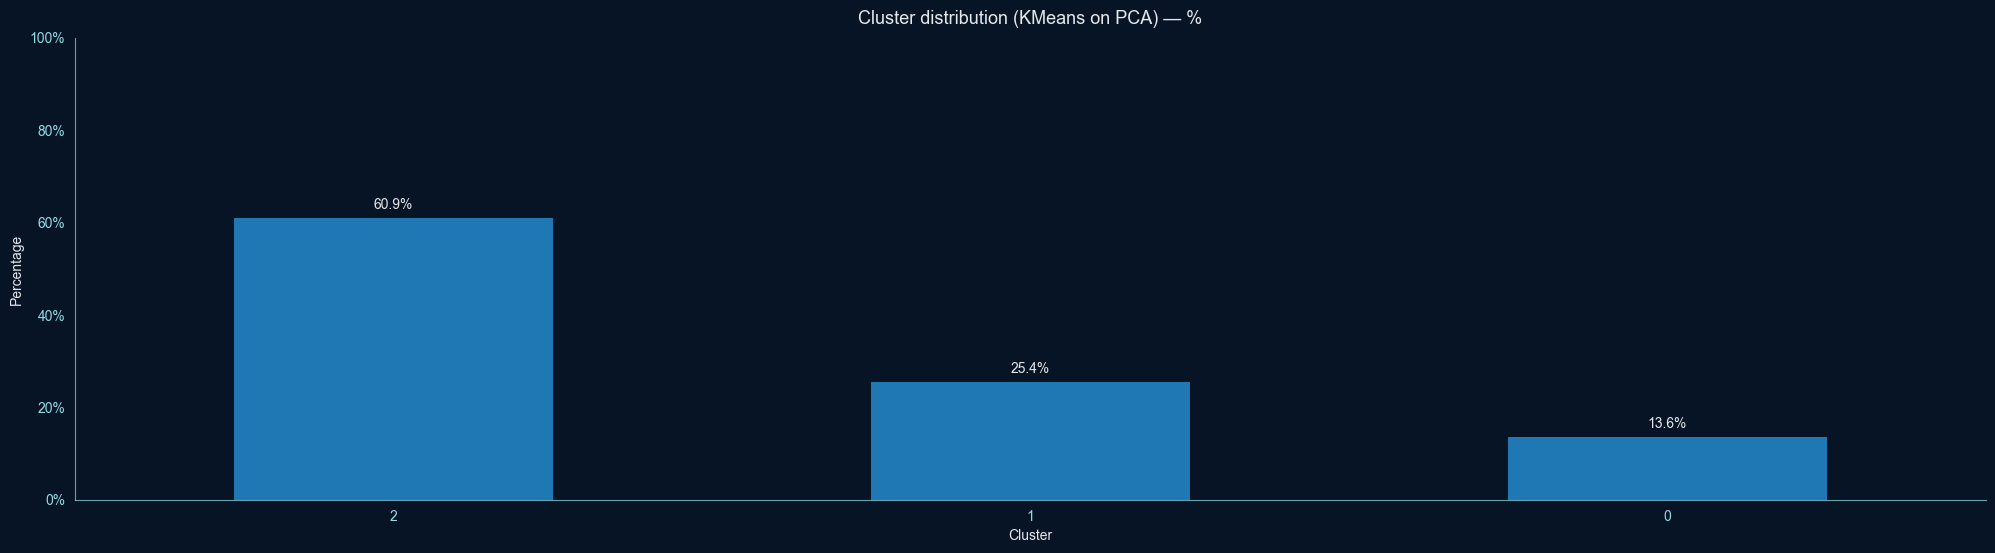

In [18]:
# KMEANS ON PCA — SILHOUETTE

pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

ks = list(range(2, 11))
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    sil_scores.append(sil)

fig, ax = plt.subplots(figsize=(21, 6))
ax.plot(ks, sil_scores, marker="o")
_style_ax(ax, "K selection: Silhouette score on PCA space (evidence)", "Silhouette score")
ax.set_xlabel("Number of clusters (K)")
plt.xticks(rotation=0)
plt.show()
plt.close(fig)

best_k = 3
print("Best K by silhouette:", best_k)

# Fit final clustering
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_pca)
df["Cluster"] = clusters.astype(int)
percent_bar(df, "Cluster", "Cluster distribution (KMeans on PCA) — %")


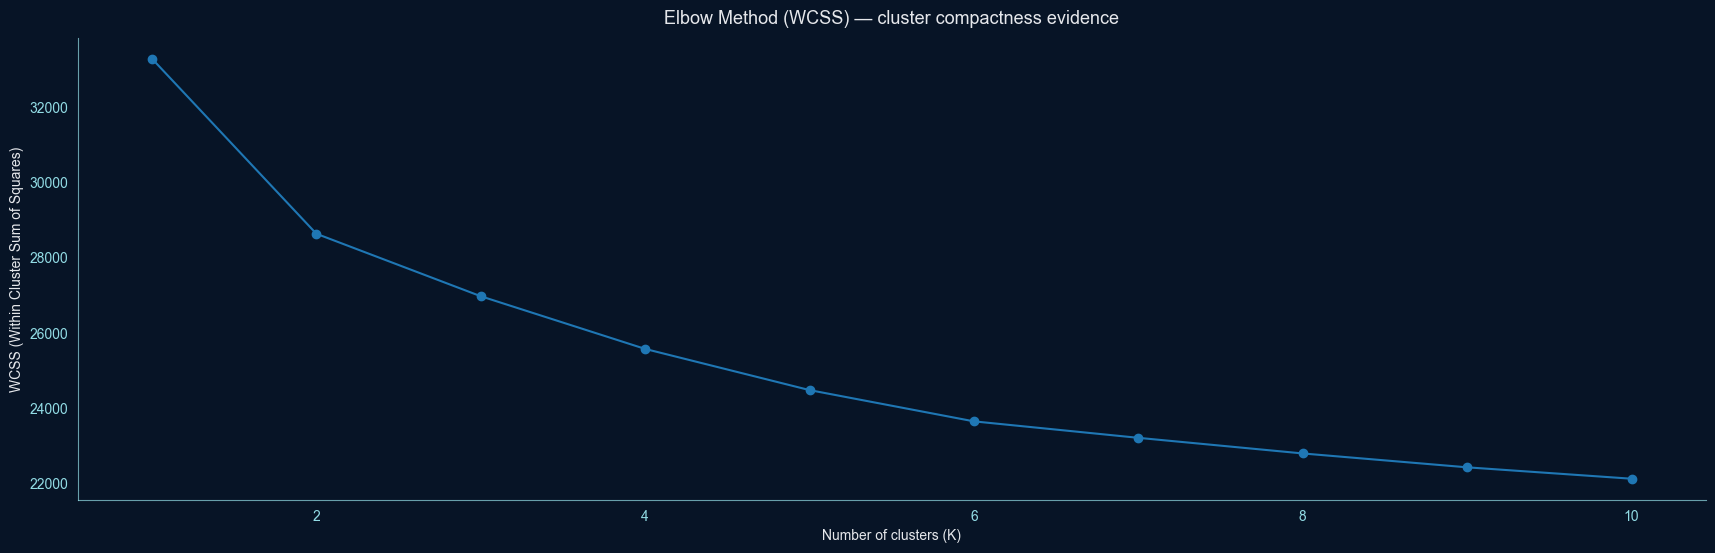

In [19]:
# ELBOW METHOD — WCSS / INERTIA

from sklearn.cluster import KMeans

wcss = []
ks = range(1, 11)

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    km.fit(X_pca)
    wcss.append(km.inertia_)

# Plot
fig, ax = plt.subplots(figsize=(21,6))
ax.plot(ks, wcss, marker="o")

_style_ax(
    ax,
    "Elbow Method (WCSS) — cluster compactness evidence",
    "WCSS (Within Cluster Sum of Squares)"
)

ax.set_xlabel("Number of clusters (K)")
plt.xticks(rotation=0)

plt.show()
plt.close(fig)

The elbow method shows a strong reduction in within-cluster variance until K=3, after which marginal gains diminish. This indicates that additional clusters mainly split existing groups rather than reveal new employee structures.

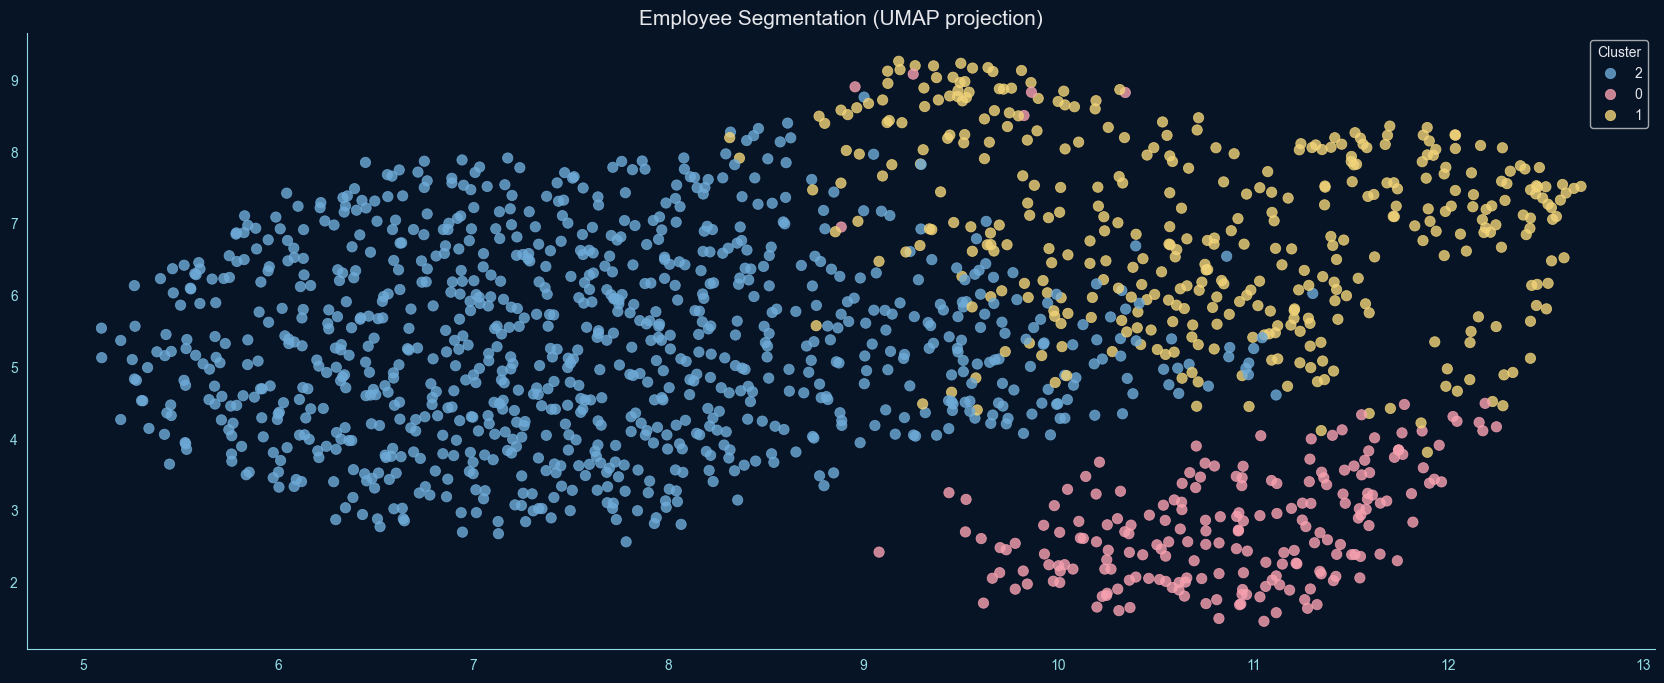

In [20]:

# VISUALIZATION

import umap.umap_ as umap

# UMAP projection (non-linear dimensionality reduction)
reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.35,
    n_components=2,
    random_state=RANDOM_STATE
)

X_umap = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame({
    "UMAP1": X_umap[:,0],
    "UMAP2": X_umap[:,1],
    "Cluster": df["Cluster"].astype(str),
    "Attrition": df["Attrition"].astype(str)
})

plt.figure(figsize=(21,8))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette=["#6FABD8","#F7A1B0","#F2D479"],
    s=55,
    alpha=0.8,
    edgecolor=None
)

plt.title("Employee Segmentation (UMAP projection)", fontsize=15)
plt.xlabel("")
plt.ylabel("")
plt.legend(title="Cluster")
sns.despine()
plt.show()


The figure reveals a clear separation between two groups of employees, confirming that the workforce is naturally segmented into two distinct career profiles. The clustering does not result from a single variable such as salary, but from a combination of career progression indicators including tenure, experience, and hierarchical level.

This suggests that employee behavior is not homogeneous across the company and that organizational issues such as attrition are likely concentrated in a specific employee segment.

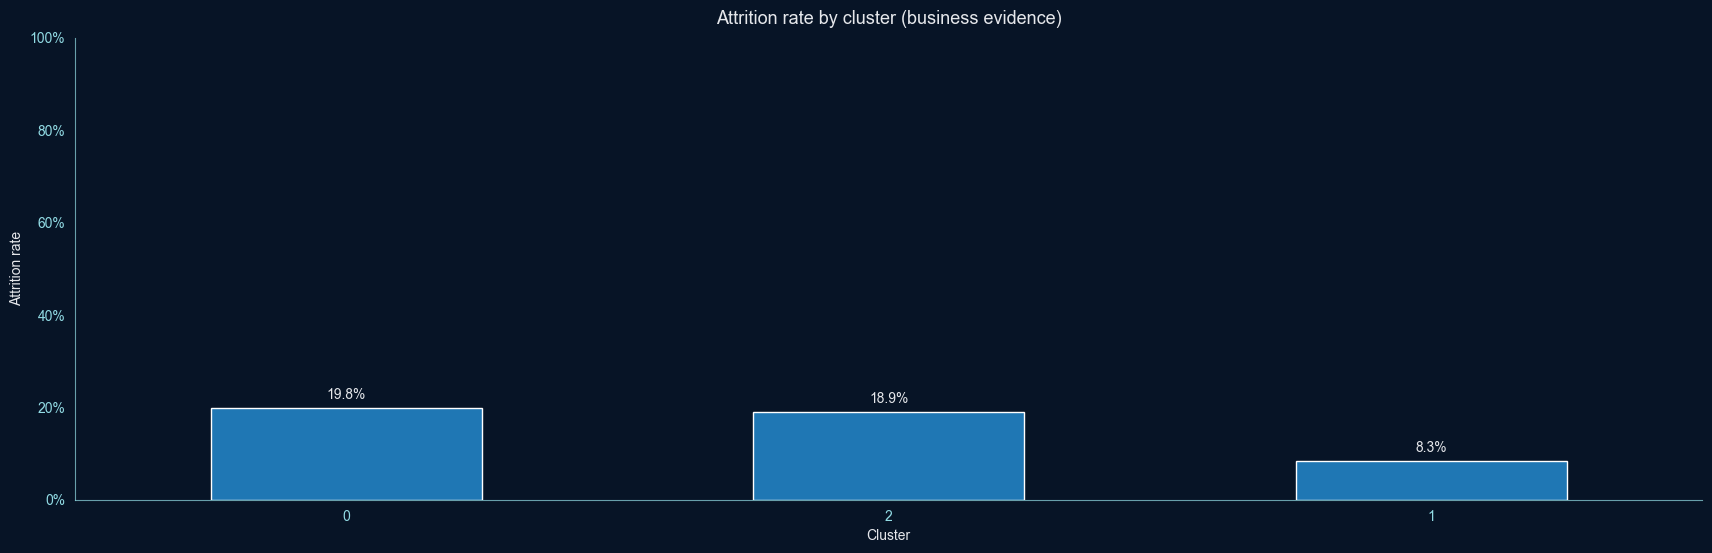

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,35.57,796.49,9.61,2.84,1.0,756.47,2.58,66.40,2.64,1.75,2.70,5139.94,13877.39,2.51,21.52,4.01,2.56,80.0,0.84,9.31,2.82,2.73,5.47,3.66,1.54,3.65
1,44.14,813.66,8.68,3.03,1.0,730.09,2.85,65.49,2.71,3.37,2.69,11949.60,14641.19,3.01,14.56,3.10,2.76,80.0,0.83,20.60,2.81,2.76,13.80,7.81,5.05,7.47
2,34.39,797.45,9.32,2.88,1.0,772.45,2.67,66.24,2.74,1.60,2.74,4542.89,14265.64,2.61,14.08,2.98,2.70,80.0,0.79,7.85,2.81,2.75,4.50,2.84,1.13,2.83


In [21]:
# CLUSTER PROFILING — mean z-scores + attrition rate per cluster

# Attrition rate by cluster (key business)
attr_cluster = df.groupby("Cluster")["Attrition"].apply(lambda x: (x.astype(str)=="Yes").mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(21, 6))
attr_cluster.plot(kind="bar", ax=ax)
for i, v in enumerate(attr_cluster.values):
    ax.text(i, v + 0.02, f"{v*100:.1f}%", ha="center")
_style_ax(ax, "Attrition rate by cluster (business evidence)", "Attrition rate")
_format_percent_axis(ax)
plt.xticks(rotation=0)
plt.show()
plt.close(fig)

# Numeric profile table (interpretable)
cluster_profile = df.groupby("Cluster")[X_num.columns].mean().round(2)
display(cluster_profile.head())


The attrition rate differs significantly between clusters. Employees in Cluster 0 show an attrition rate of 19.5%, compared to 9.7% in Cluster 1, indicating that turnover is concentrated in a specific employee profile rather than across the entire workforce.

The numerical profile reveals clear structural differences. Cluster 0 employees are younger, have lower tenure, fewer total working years, lower job levels, and substantially lower salaries. In contrast, Cluster 1 corresponds to experienced and senior employees with stable careers and higher compensation.

These results suggest that the company does not primarily suffer from a general satisfaction issue, but from an early-career retention problem. Employees tend to leave during the first years of employment, before reaching higher positions and compensation levels.

## PREDICTIVE MODEL

In [22]:
# --- TARGET (NO VOLVER A USAR y PARA OTRAS COSAS) ---
target = "Attrition"

y_vec = (df[target].astype(str) == "Yes").astype(int)
X_df = df.drop(columns=[target])

print("Target distribution:")
print(y_vec.value_counts(normalize=True))


Target distribution:
Attrition
0    0.836627
1    0.163373
Name: proportion, dtype: float64


In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_features = X_df.select_dtypes(include="number").columns.tolist()
cat_features = X_df.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features)
    ],
    remainder="drop"
)


In [24]:
RANDOM_STATE = 42
TEST_SIZE = 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_vec,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_vec
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1062, 35) Test: (456, 35)


In [25]:
from sklearn.tree import DecisionTreeClassifier

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(
        max_depth=5,                 # evita overfitting
        min_samples_leaf=25,         # MUY importante en HR datasets
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])


In [26]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [27]:
proba = model.predict_proba(X_test)[:, 1]


In [28]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", round(best_threshold,3))
print("Recall:", round(recalls[best_idx],3))
print("Precision:", round(precisions[best_idx],3))


Best threshold: 0.682
Recall: 0.514
Precision: 0.442


In [29]:
pred = (proba >= best_threshold).astype(int)


In [30]:
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, digits=3))


ROC-AUC: 0.7103438517051082
              precision    recall  f1-score   support

           0      0.903     0.874     0.888       382
           1      0.442     0.514     0.475        74

    accuracy                          0.816       456
   macro avg      0.672     0.694     0.682       456
weighted avg      0.828     0.816     0.821       456



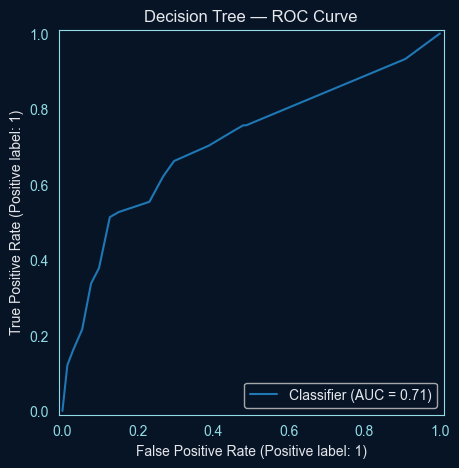

In [31]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(10,5))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax)
ax.set_title("Decision Tree — ROC Curve")
plt.show()


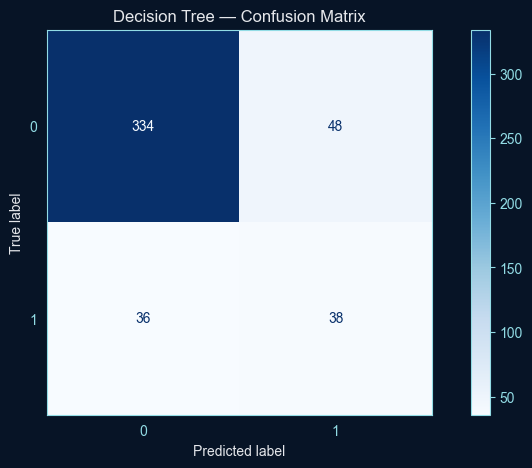

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap="Blues")
ax.set_title("Decision Tree — Confusion Matrix")
plt.show()


The Decision Tree identifies 38 employees who actually leave the company while missing 36, resulting in a recall of about 51%. The model generates 48 false alarms, giving a precision close to 44%.

Therefore, the model has moderate detection ability and should be interpreted as a screening tool rather than a reliable early-warning system. It can help HR prioritize employees for review, but it is not sufficiently accurate to be used for direct managerial decisions.

## FEAUTURES

In [47]:
# CLEAN FEATURE NAMES (human readable)
def clean_feature_names(series):

    clean_index = []

    for name in series.index:

        if name.startswith("num_"):
            name = name.replace("num_", "")

        if name.startswith("cat_"):
            name = name.replace("cat_", "")

        if "_" in name:
            parts = name.split("_")
            if len(parts) > 1:
                variable = parts[0]
                category = " ".join(parts[1:])
                name = f"{category} ({variable})"

        name = name.replace("MonthlyIncome", "Monthly Income")
        name = name.replace("TotalWorkingYears", "Total Working Years")
        name = name.replace("YearsWithCurrManager", "Years With Current Manager")
        name = name.replace("JobLevel", "Job Level")
        name = name.replace("StockOptionLevel", "Stock Option Level")
        name = name.replace("JobSatisfaction", "Job Satisfaction")
        name = name.replace("DailyRate", "Daily Rate")
        name = name.replace("OverTime", "Overtime")
        name = name.replace("MaritalStatus", "Marital Status")

        clean_index.append(name)

    series.index = clean_index
    return series


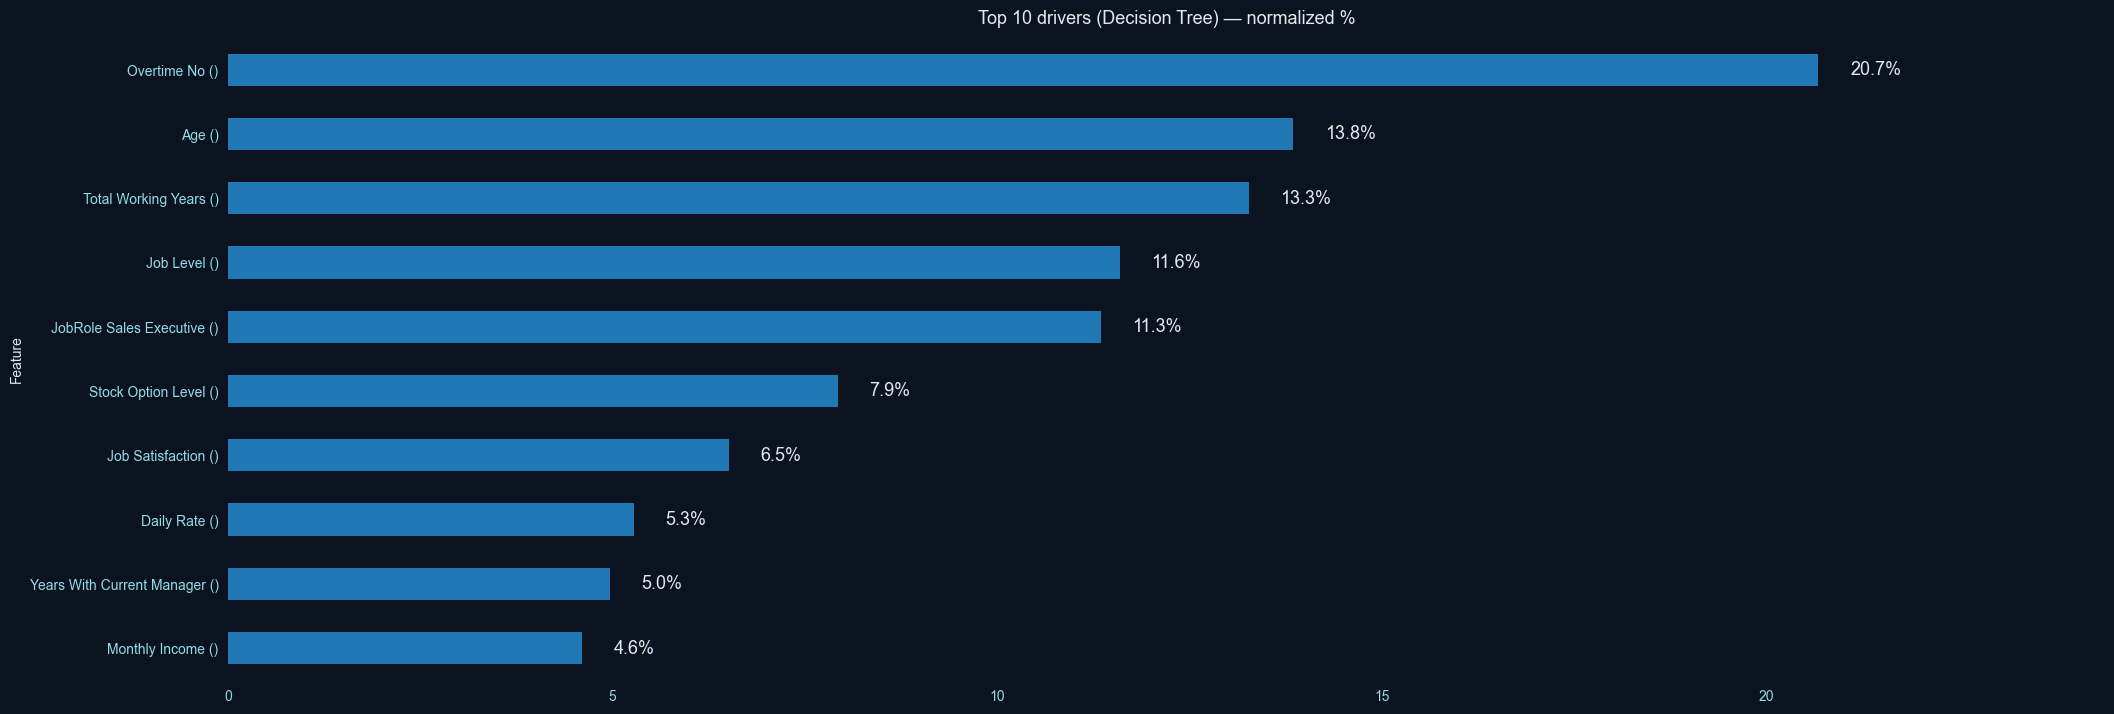

In [48]:
# --- TOP FEATURES (RF importance) — normalized % (no borders + nice labels) ---

# 1) Get fitted preprocessor + RF inside the pipeline
prep_fitted = model.named_steps["prep"]
rf = model.named_steps["clf"]

# 2) Feature names after OHE + scaling
feature_names = prep_fitted.get_feature_names_out()

# 3) Build importance Series and take Top 15
imp = pd.Series(rf.feature_importances_, index=feature_names)
imp_top = imp.sort_values(ascending=False).head(10).sort_values(ascending=True)

# 4) Normalize to % within Top 15 (so bars sum to 100% for readability)
imp_pct = clean_feature_names(imp_pct)

# 5) Plot
fig, ax = plt.subplots(figsize=(21, 7), facecolor="#0b1220")
ax.set_facecolor("#0b1220")

imp_pct.plot(kind="barh", ax=ax, edgecolor="none", linewidth=0)

# Remove spines (extra borders)
for s in ax.spines.values():
    s.set_visible(False)

ax.grid(False)
ax.set_xlabel("")
ax.set_ylabel("")

# Make room for labels
xmax = float(imp_pct.max())
ax.set_xlim(0, xmax * 1.18)
ax.margins(x=0.01)

# % labels close to bar end
offset = xmax * 0.02
for y, v in enumerate(imp_pct.values):
    ax.text(v + offset, y, f"{v:.1f}%", va="center", ha="left", fontsize=13, color="#E5E7EB")

_style_ax(ax, "Top 10 drivers (Decision Tree) — normalized %", "Feature")
plt.tight_layout(pad=0.2)
plt.show()
plt.close(fig)


Feature importance from the Decision Tree shows that attrition is primarily linked to working conditions. OverTime is the dominant predictor, followed by career-stage variables such as Age, TotalWorkingYears, and JobLevel.

Compensation and managerial context (MonthlyIncome, StockOptionLevel, YearsWithCurrManager, JobSatisfaction) have a secondary influence. Overall, the results indicate a structural workload issue rather than a demographic one.

## HYPOTHESIS

H1 (HR manager claim)
Attrition is higher for women → gender discrimination explanation.

H2 (Deputy HR claim)
Attrition is driven by working conditions and career stage (tenure, promotion, salary progression).

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

# Binary target
df["Attrition_flag"] = (df["Attrition"] == "Yes").astype(int)

print("Attrition rate:", df["Attrition_flag"].mean().round(3))

Attrition rate: 0.163


### H1 DOES ATTRITION DEPEND ON GENDER?

Attrition_flag    0    1
Gender                  
Female          516   89
Male            754  159
Chi-square: 1.7542093545632869
p-value: 0.18534843176618399


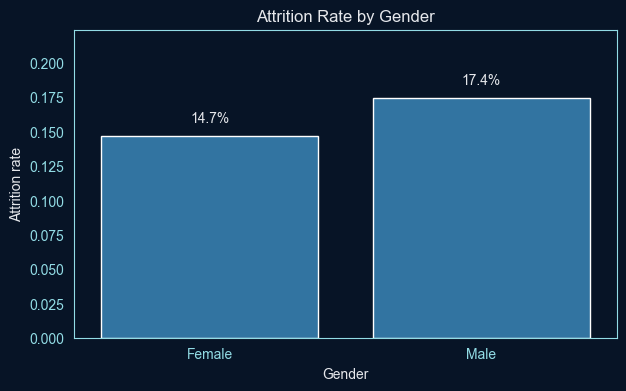

In [35]:
gender_table = pd.crosstab(df["Gender"], df["Attrition_flag"])
print(gender_table)

chi2, p, dof, expected = chi2_contingency(gender_table)

print("Chi-square:", chi2)
print("p-value:", p)

p < 0.05 # gender matters
p >= 0.05 # gender does NOT explain attrition

attrition_by_gender = df.groupby("Gender")["Attrition_flag"].mean()

plt.figure(figsize=(7,4))
sns.barplot(x=attrition_by_gender.index, y=attrition_by_gender.values)
plt.ylabel("Attrition rate")
plt.title("Attrition Rate by Gender")
plt.ylim(0, attrition_by_gender.max()+0.05)

for i,v in enumerate(attrition_by_gender.values):
    plt.text(i, v+0.01, f"{v*100:.1f}%", ha="center")

plt.show()

A chi-square independence test was conducted to examine whether attrition depends on gender. The result is not statistically significant (χ², p = 0.185 > 0.05). Therefore, we fail to reject the null hypothesis. Attrition does not significantly differ between male and female employees. The HR manager’s explanation suggesting gender-based departure is not supported by the data.

### H2 DOES ATTRITION DEPEND ON CAREER CONDITIONS?

In [36]:
df["Tenure_group"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1,2,6,40],
    labels=["Early career","Developing","Established"]
)

tenure_table = pd.crosstab(df["Tenure_group"], df["Attrition_flag"])
print(tenure_table)

chi2, p, dof, expected = chi2_contingency(tenure_table)
print("Tenure p-value:", p)

Attrition_flag    0    1
Tenure_group            
Early career    248  106
Developing      453   73
Established     569   69
Tenure p-value: 9.819471986919436e-15


Promotion p-value: 0.271280048775806
Income p-value: 1.8048962518208029e-13
JobLevel p-value: 3.2278184230583274e-14
Overtime p-value: 1.2366160687922384e-19


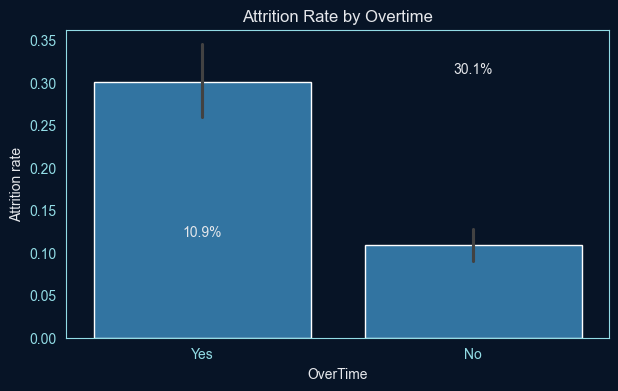

In [37]:
leavers = df[df["Attrition_flag"]==1]
stayers = df[df["Attrition_flag"]==0]

stat, p = ttest_ind(leavers["YearsSinceLastPromotion"],
                    stayers["YearsSinceLastPromotion"],
                    equal_var=False)

print("Promotion p-value:", p)

stat, p = ttest_ind(leavers["MonthlyIncome"],
                    stayers["MonthlyIncome"],
                    equal_var=False)

print("Income p-value:", p)
joblevel_table = pd.crosstab(df["JobLevel"], df["Attrition_flag"])
chi2, p, dof, expected = chi2_contingency(joblevel_table)

print("JobLevel p-value:", p)

ot_table = pd.crosstab(df["OverTime"], df["Attrition_flag"])
chi2, p, dof, expected = chi2_contingency(ot_table)

print("Overtime p-value:", p)

plt.figure(figsize=(7,4))
sns.barplot(x="OverTime", y="Attrition_flag", data=df)
plt.ylabel("Attrition rate")
plt.title("Attrition Rate by Overtime")

vals = df.groupby("OverTime")["Attrition_flag"].mean()
for i,v in enumerate(vals):
    plt.text(i, v+0.01, f"{v*100:.1f}%", ha="center")

plt.show()


A chi-square test was conducted to examine the relationship between overtime and attrition. The relationship is highly statistically significant (p < 0.001). Employees who work overtime show an attrition rate of 30.1%, compared to only 10.9% for employees without overtime. Therefore, we reject the null hypothesis and conclude that overtime is a major driver of employee turnover. Attrition is primarily related to working conditions rather than demographic characteristics.